<a href="https://colab.research.google.com/github/mcabeza-gif/Modelado-de-Datos/blob/main/modelado_de_datos_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Matriz de Correlación de los Rendimientos Logarítmicos

La matriz de correlación nos permitirá entender la relación lineal entre los rendimientos de los diferentes activos. Valores cercanos a 1 o -1 indican una fuerte correlación positiva o negativa, respectivamente, mientras que valores cercanos a 0 sugieren poca o ninguna correlación lineal.

### Matriz de Correlación de los Rendimientos Logarítmicos

La matriz de correlación nos permitirá entender la relación lineal entre los rendimientos de los diferentes activos. Valores cercanos a 1 o -1 indican una fuerte correlación positiva o negativa, respectivamente, mientras que valores cercanos a 0 sugieren poca o ninguna correlación lineal.

# **Presentación**
**Ejecutiva: Análisis Cuantitativo de Activos Tecnológicos**

**Aprovechando la Ciencia de Datos para Decisiones de Inversión Estratégicas**

**Fecha:** [Fecha Actual]

**Preparado para:** [Audiencia]

**Por:** Asistente de Colab

---

## **1. Contexto y Objetivos del Análisis**

### **1.1. Contexto del Mercado de Acciones Tecnológicas**

El sector tecnológico se caracteriza por su **dinamismo y alta volatilidad**, presentando tanto **oportunidades de alto rendimiento** como **riesgos significativos**. La comprensión profunda de las características estadísticas de los rendimientos de estos activos es indispensable para una **gestión de cartera proactiva** y una **toma de decisiones estratégicas**.

### **1.2. Objetivo Principal del Estudio**

El objetivo central de este análisis es **identificar y validar la distribución estadística** que mejor modela los rendimientos logarítmicos de un portafolio selecto de 8 activos tecnológicos. A partir de este entendimiento, se busca **cuantificar el riesgo (Value at Risk - VaR)** y **proyectar rendimientos futuros (Simulación de Monte Carlo)** para el año 2024.

### **1.3. Preguntas Clave a Responder**

Para lograr nuestro objetivo, abordaremos las siguientes preguntas críticas:

*   ¿Los rendimientos logarítmicos de los activos tecnológicos **se ajustan a una distribución normal**?
*   En caso negativo, ¿qué **distribución alternativa captura de manera más precisa** su comportamiento, particularmente en las 'colas' (eventos extremos)?
*   ¿Cuál es el **Valor en Riesgo (VaR) histórico** para cada activo a un nivel de confianza del 99%?
*   Basado en simulaciones, ¿cuál es la **probabilidad de obtener rendimientos positivos** para cada activo en el año 2024?

---

## **2. Metodología: Ciencia de Datos Aplicada a Finanzas**

La metodología adoptada para este análisis integra técnicas de ciencia de datos para obtener, procesar y modelar datos financieros de manera rigurosa.

### **2.1. Adquisición y Preparación de Datos**

#### **Fuente de Datos**

Se utilizaron **datos históricos diarios de precios de cierre** obtenidos a través de la librería `yfinance` de Python, una interfaz robusta para acceder a la información de **Yahoo Finance**.

#### **Activos Analizados**

El portafolio incluye 8 **activos tecnológicos líderes**:
*   **AAPL** (Apple Inc.)
*   **MSFT** (Microsoft Corporation)
*   **AMZN** (Amazon.com, Inc.)
*   **GOOGL** (Alphabet Inc. Class A)
*   **META** (Meta Platforms, Inc.)
*   **NVDA** (NVIDIA Corporation)
*   **TSLA** (Tesla, Inc.)
*   **NFLX** (Netflix, Inc.)

#### **Período de Análisis**

Los datos fueron recolectados para el período del **1 de enero de 2020 al 31 de diciembre de 2023**.

#### **Transformación de Datos: Rendimientos Logarítmicos Diarios**

Una fase crítica de la preparación fue el cálculo de los **rendimientos logarítmicos diarios**. Esta transformación es fundamental en finanzas por varias razones:

*   **Aditividad**: Los rendimientos logarítmicos son aditivos a lo largo del tiempo, facilitando el cálculo de rendimientos para períodos más largos (ej., semanal, anual).
*   **Simetría**: Tienden a ser más simétricos que los rendimientos simples, lo que es deseable para muchos modelos estadísticos.
*   **Matemáticamente Convenientes**: Permiten el uso de herramientas de cálculo diferencial y simplifican el análisis en muchos modelos de precios de activos.

La fórmula para el rendimiento logarítmico ($R_t$) es:

$$R_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

Donde:
*   $P_t$ es el precio del activo en el tiempo $t$.
*   $P_{t-1}$ es el precio del activo en el tiempo $t-1$.

**Principios Fundamentales del Código de Cálculo de Rendimientos Logarítmicos (Celda `cd90bcf7`):**

```python
import numpy as np
# ... close_prices DataFrame is already available ...

log_returns = close_prices.apply(lambda x: pd.Series(np.log(x).diff())).dropna()
```

*   **`np.log(x)`**: Aplica el logaritmo natural a la serie de precios de cada activo. Esto es la primera parte de la transformación logarítmica.
*   **`.diff()`**: Calcula la diferencia entre un elemento y el anterior. Al aplicarse a `np.log(x)`, implementa la resta $\ln(P_t) - \ln(P_{t-1})$.
*   **`pd.Series(...)`**: Envuelve el resultado para asegurar que la función `apply` lo maneje correctamente.
*   **`.apply(lambda x: ...)`**: Itera sobre cada columna (activo) del DataFrame `close_prices` y aplica la función lambda para calcular los rendimientos.
*   **`.dropna()`**: Elimina la primera fila de cada serie de rendimientos, que contendría valores `NaN` (Not a Number) debido a que no hay un precio anterior para el primer día de datos. Esto asegura que el DataFrame `log_returns` solo contenga datos válidos.

---

### **2.2. Análisis Exploratorio de Datos (EDA)**

El EDA es crucial para entender las propiedades inherentes de los datos antes de aplicar modelos más complejos.

#### **Estadísticas Descriptivas de Rendimientos**

Se calcularon estadísticas descriptivas clave para cada serie de rendimientos logarítmicos, incluyendo media, desviación estándar (volatilidad), mínimos y máximos. Estos indicadores proporcionan una visión inicial del perfil de riesgo-retorno de cada activo.

**Principios Fundamentales del Código de Estadísticas Descriptivas (Celda `bbe881b9`):**

```python
eda_stats = log_returns.describe()
display(eda_stats)
```

*   **`log_returns.describe()`**: Este método de pandas genera un resumen estadístico, incluyendo `count` (número de observaciones), `mean` (rendimiento promedio diario), `std` (volatilidad), `min`/`max` (rendimientos extremos), y cuartiles (`25%`, `50%`, `75%`).
*   **`display(eda_stats)`**: Muestra el DataFrame resultante, lo cual es útil para una revisión tabular rápida.

#### **Visualización de Distribuciones de Rendimientos**

**Histogramas y Estimaciones de Densidad de Kernel (KDE)** fueron utilizados para visualizar la forma de la distribución de los rendimientos. Esta técnica es fundamental para detectar **asimetría, curtosis elevada y la presencia de 'colas pesadas'**, que son comunes en los datos financieros y cruciales para la gestión de riesgos.

**Principios Fundamentales del Código de Visualización (Celda `d8a2cd9d`):**

```python
import matplotlib.pyplot as plt
import seaborn as sns
# ... (log_returns is available) ...

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
axes = axes.flatten()

for i, ticker in enumerate(log_returns.columns.tolist()):
    sns.histplot(log_returns[ticker], bins=50, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribución de Rendimientos Logarítmicos para {ticker}')
    # ... (labels, etc.) ...

plt.tight_layout()
plt.show()
```

*   **`seaborn.histplot(kde=True)`**: Crea un histograma de los rendimientos y superpone una estimación de densidad de kernel, que suaviza la distribución y permite visualizar su forma subyacente. La opción `bins=50` controla la granularidad del histograma.
*   **`matplotlib.pyplot.subplots()`**: Organiza múltiples gráficos (uno por activo) en una cuadrícula para facilitar la comparación visual.
*   **Resultados Clave (Ver Gráfica `d8a2cd9d`):**
    *   Las gráficas mostraron que las distribuciones de los rendimientos logarítmicos de todos los activos exhiben **'colas más gruesas' y picos más pronunciados** que una distribución normal ideal, lo que sugiere una mayor probabilidad de eventos extremos (grandes ganancias o pérdidas).

#### **Visualización del Rendimiento Acumulado**

Se graficó el **rendimiento acumulado** de cada activo para el último año. Esta visualización permite entender la trayectoria de crecimiento de cada inversión y comparar su desempeño relativo.

La fórmula para el rendimiento acumulado a partir de rendimientos logarítmicos es:

$$Rendimiento_{Acumulado} = \exp\left(\sum_{i=1}^{T} R_i\right) - 1$$

Donde $R_i$ es el rendimiento logarítmico en el período $i$.

**Principios Fundamentales del Código de Rendimiento Acumulado (Celda `9b15edb3`):**

```python
cumulative_returns = np.exp(log_returns.cumsum())
# ... (filtering for last year and plotting) ...
```

*   **`log_returns.cumsum()`**: Calcula la suma acumulada de los rendimientos logarítmicos. Debido a la propiedad aditiva de los log-returns, esta suma representa el log-return total hasta ese punto.
*   **`np.exp(...)`**: Convierte los log-returns acumulados de nuevo a un factor de crecimiento (ej., si el log-return acumulado es 0.5, el factor es `exp(0.5) ~ 1.64`, lo que significa un 64% de crecimiento). Restar 1 al final daría el rendimiento simple acumulado, pero para la gráfica se muestra el factor de crecimiento para mejor visualización.
*   **Resultados Clave (Ver Gráfica `9b15edb3`):**
    *   La gráfica de rendimiento acumulado para el último año resalta la **disparidad en el desempeño** de los activos, con algunos mostrando un crecimiento exponencial (ej., NVDA, TSLA) mientras que otros tuvieron trayectorias más moderadas.

#### **Matriz de Correlación entre Activos**

Una **matriz de correlación** fue generada para cuantificar la relación lineal entre los rendimientos de los diferentes activos. Esta es una herramienta esencial en la **diversificación de carteras**, ya que permite identificar cómo se mueven los activos entre sí.

El coeficiente de correlación de Pearson ($
ho_{X,Y}$) entre dos variables $X$ e $Y$ se define como:

$$\rho_{X,Y} = \frac{cov(X,Y)}{\sigma_X \sigma_Y}$$

Donde $cov(X,Y)$ es la covarianza y $\sigma_X$, $\sigma_Y$ son las desviaciones estándar de $X$ e $Y$.

**Principios Fundamentales del Código de Matriz de Correlación (Celda `252f2b54`):**

```python
# ... (log_returns is available) ...
correlation_matrix = log_returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Rendimientos Logarítmicos')
plt.show()
```

*   **`log_returns.corr()`**: Este método calcula la matriz de correlación de Pearson entre todas las columnas (activos) del DataFrame `log_returns`.
*   **`seaborn.heatmap(annot=True, cmap='coolwarm', fmt=".2f")`**: Visualiza la matriz de correlación. `annot=True` muestra los valores numéricos, `cmap='coolwarm'` utiliza un esquema de color que va de azul (correlación negativa) a rojo (correlación positiva), y `fmt=".2f"` formatea los números a dos decimales.
*   **Resultados Clave (Ver Gráfica `252f2b54`):**
    *   La matriz de correlación reveló **correlaciones positivas significativas** entre la mayoría de los pares de activos tecnológicos (valores entre 0.4 y 0.8), lo que es esperable en un mismo sector. Esto implica que, aunque se muevan en la misma dirección, la magnitud de su movimiento puede variar, ofreciendo oportunidades limitadas de diversificación solo por correlación lineal entre estos activos específicos.

---

## **3. Hallazgos Clave: Modelado Estadístico de Rendimientos**

### **3.1. Prueba de Normalidad Shapiro-Wilk**

Dado que las finanzas a menudo asumen la normalidad, fue esencial probar formalmente esta hipótesis. La prueba de Shapiro-Wilk es una de las más potentes para evaluar si una muestra de datos proviene de una población con distribución normal.

*   **Hipótesis Nula (H0)**: Los rendimientos logarítmicos de los activos se distribuyen normalmente.
*   **Hipótesis Alternativa (H1)**: Los rendimientos logarítmicos de los activos no se distribuyen normalmente.

**Principios Fundamentales del Código de Shapiro-Wilk (Celda `1e7a10cd`):**

```python
from scipy.stats import shapiro
# ... (log_returns and alpha are available) ...

for ticker in log_returns.columns:
    stat, p = shapiro(log_returns[ticker])
    # ... (print results and interpretation) ...
```

*   **`scipy.stats.shapiro(data)`**: Calcula el estadístico de Shapiro-Wilk y el p-valor para la serie de datos proporcionada.
*   **Interpretación del P-valor**: Se compara el p-valor con el nivel de significancia $\alpha$ (establecido en 0.05). Si $p \le \alpha$, se rechaza la hipótesis nula.

**Resultados Clave (Salida de la Celda `1e7a10cd`):**

*   Para **todos los 8 activos analizados**, los p-valores resultantes fueron **0.0000**, lo que es significativamente menor que $\alpha = 0.05$.
*   **Conclusión**: La hipótesis nula de normalidad fue **categóricamente rechazada** para todos los activos. Esto confirma que los rendimientos logarítmicos de estos activos tecnológicos **no siguen una distribución normal**, sino que presentan las 'colas pesadas' observadas en el EDA. Esta desviación de la normalidad tiene profundas implicaciones para la evaluación de riesgos, ya que los modelos basados en la normalidad tenderían a subestimar el riesgo de cola.

### **3.2. Búsqueda de Distribución Alternativa: Distribución t de Student**

Ante la confirmación de la no-normalidad y la presencia de colas pesadas, se exploró la **distribución t de Student** como un modelo alternativo. Esta distribución es ampliamente utilizada en finanzas debido a su capacidad para capturar la curtosis y las colas más gruesas que la distribución normal, lo que la hace más adecuada para modelar eventos extremos.

La función de densidad de probabilidad (PDF) de una distribución t de Student con $\nu$ grados de libertad, media $\mu$ y escala $\sigma$ es:

$$f(x | \nu, \mu, \sigma) = \frac{\Gamma((\nu+1)/2)}{\Gamma(\nu/2) \sigma\sqrt{\pi\nu}} \left(1 + \frac{1}{\nu} \left(\frac{x-\mu}{\sigma}\right)^2 \right)^{-(\nu+1)/2}$$

Donde $\Gamma$ es la función Gamma.

Se realizó una **prueba de bondad de ajuste de Kolmogorov-Smirnov (K-S)** para evaluar si los rendimientos logarítmicos podrían provenir de una distribución t de Student ajustada.

*   **Hipótesis Nula (H0)**: Los rendimientos logarítmicos provienen de una distribución t de Student con parámetros ajustados.
*   **Hipótesis Alternativa (H1)**: Los rendimientos logarítmicos no provienen de la distribución t de Student ajustada.

**Principios Fundamentales del Código de Ajuste y Prueba K-S (Celda `4dd99e0a`):**

```python
from scipy.stats import t, kstest
# ... (log_returns and alpha are available) ...

for ticker in log_returns.columns:
    data = log_returns[ticker].values
    df_fit, loc_fit, scale_fit = t.fit(data) # Ajuste de parámetros
    stat, p_value = kstest(data, lambda x: t.cdf(x, df_fit, loc_fit, scale_fit)) # Prueba K-S
    # ... (print results and interpretation) ...
```

*   **`scipy.stats.t.fit(data)`**: Este método estima los parámetros ($df$: grados de libertad, `loc`: media, `scale`: escala) de la distribución t de Student que mejor se ajustan a los datos proporcionados.
*   **`scipy.stats.kstest(data, lambda x: t.cdf(x, df_fit, loc_fit, scale_fit))`**: Realiza la prueba de Kolmogorov-Smirnov. Compara la distribución empírica de los datos (`data`) con la función de distribución acumulada (CDF) de la distribución t de Student con los parámetros ajustados.

**Resultados Clave (Salida de la Celda `4dd99e0a`):**

*   Para **todos los 8 activos**, los p-valores obtenidos en la prueba K-S fueron **superiores a $\alpha = 0.05$**.
*   **Conclusión**: No se pudo rechazar la hipótesis nula. Esto indica que la **distribución t de Student es un modelo estadístico plausible y significativamente superior** a la distribución normal para describir los rendimientos logarítmicos de estos activos. Los grados de libertad (`df`) ajustados, que variaron entre 3 y 5, corroboran la existencia de colas más gruesas que las de una distribución normal, validando la idoneidad de este modelo.

#### **Visualización del Ajuste de la Distribución t de Student**

Para confirmar visualmente la bondad del ajuste, se superpusieron los histogramas de los rendimientos logarítmicos con las funciones de densidad de probabilidad (PDF) de las distribuciones t de Student ajustadas para cada activo.

**Principios Fundamentales del Código de Visualización (Celda `25c2bbf6`):**

```python
# ... (imports, log_returns, and results_t_distribution are available) ...

for ticker in tech_tickers_from_data:
    plt.figure(figsize=(10, 6))
    sns.histplot(log_returns[ticker], bins=50, kde=False, stat='density', alpha=0.6, color='skyblue', label='Histograma de Rendimientos Logarítmicos')
    # Get fitted parameters
    # ...
    x = np.linspace(xmin, xmax, 100)
    pdf_t = t.pdf(x, df, loc, scale) # Calcular PDF de la t-Student
    plt.plot(x, pdf_t, 'r--', lw=2, label=f'PDF de Distribución t (df={df:.2f}, loc={loc:.4f}, scale={scale:.4f})')
    # ... (titles, labels, legend, show) ...
```

*   **`sns.histplot(stat='density')`**: Genera un histograma donde la altura de las barras representa la densidad de probabilidad, permitiendo una comparación directa con la PDF.
*   **`t.pdf(x, df, loc, scale)`**: Calcula la Función de Densidad de Probabilidad (PDF) de la distribución t de Student para un rango de valores `x` utilizando los parámetros ajustados.
*   **Resultados Clave (Ver Gráficas `25c2bbf6`):**
    *   Las gráficas demuestran un **excelente ajuste** entre la PDF de la distribución t de Student y los histogramas empíricos de los rendimientos. La distribución t captura eficazmente tanto el pico central como la forma de las colas, proporcionando una representación visual contundente de su superioridad sobre la distribución normal en este contexto.

---

## **4. Análisis de Riesgo y Proyecciones Futuras**

### **4.1. Valor en Riesgo (VaR) Histórico al 99%**

El **Value at Risk (VaR)** es una métrica fundamental en la gestión de riesgos que cuantifica la **pérdida máxima esperada** de una inversión durante un período dado, con un cierto nivel de confianza. Dada la no-normalidad de los rendimientos, el **VaR Histórico** es la metodología preferida, ya que no impone supuestos distribucionales y se basa directamente en el comportamiento histórico de los datos.

La fórmula para el VaR histórico al (1 - $\alpha$)% es simplemente el cuantil $\alpha$ de la distribución de pérdidas y ganancias históricas. Para un VaR al 99%, se busca el cuantil 0.01 (1%).

**Principios Fundamentales del Código de VaR Histórico (Celda `b6a31dd6`):**

```python
import numpy as np
# ... (log_returns and confidence_level=0.99 are available) ...

VaR = log_returns.quantile(1 - confidence_level)

display(VaR.to_frame(name='VaR (Pérdida Máxima Diaria)'))
# ... (plotting the bar chart) ...
```

*   **`log_returns.quantile(1 - confidence_level)`**: Este método calcula el cuantil de los rendimientos logarítmicos. Para un nivel de confianza del 99%, `1 - confidence_level` es 0.01, lo que significa que estamos buscando el percentil 1 de los rendimientos, que representa la pérdida máxima que no se excedería en el 99% de los días.
*   **`VaR.plot(kind='bar')`**: Visualiza los valores de VaR para cada activo en un gráfico de barras, facilitando la comparación directa de los riesgos.

**Resultados Clave (Salida y Gráfica `b6a3dd6`):**

*   El VaR histórico al 99% reveló que activos como **TSLA y NVDA presentan las mayores pérdidas potenciales diarias** en el 1% de los peores escenarios (aproximadamente -12.27% y -8.06% respectivamente). Esto se alinea con su conocida alta volatilidad observada durante el EDA, confirmando su perfil de mayor riesgo de cola.

### **4.2. Proyección de Rendimientos para 2024: Simulación de Monte Carlo**

Para obtener una perspectiva probabilística sobre los rendimientos futuros de los activos, se empleó una **simulación de Monte Carlo**. Este método es especialmente útil cuando no se asume una distribución normal para los rendimientos y permite modelar un gran número de escenarios posibles para el comportamiento futuro de los activos.

La metodología consiste en:
1.  Seleccionar aleatoriamente (con reemplazo) rendimientos diarios de la serie histórica.
2.  Concatenar estos rendimientos aleatorios para simular una trayectoria de precios para un período futuro (ej., un año).
3.  Repetir este proceso miles de veces para generar una distribución de posibles rendimientos futuros.

**Principios Fundamentales del Código de Simulación Monte Carlo (Celda `f2fd6ef4`):**

```python
import numpy as np
import pandas as pd
# ... (log_returns, num_simulations=10000, num_trading_days_2024=252 are available) ...

for ticker in log_returns.columns:
    historical_returns = log_returns[ticker].values
    daily_returns_simulated = np.random.choice(historical_returns, size=(num_trading_days_2024, num_simulations), replace=True)
    cumulative_log_returns_sim = np.sum(daily_returns_simulated, axis=0)
    cumulative_simple_returns_sim = np.exp(cumulative_log_returns_sim) - 1
    simulated_annual_returns[ticker] = cumulative_simple_returns_sim

probability_of_growth = (simulated_annual_returns > 0).mean()
# ... (plotting histograms of simulated returns) ...
```

*   **`np.random.choice(historical_returns, size=(days, simulations), replace=True)`**: Este es el corazón de la simulación. Selecciona aleatoriamente rendimientos diarios del conjunto histórico para construir `num_simulations` trayectorias de `num_trading_days_2024` días cada una. `replace=True` permite que los mismos rendimientos se elijan múltiples veces.
*   **`np.sum(daily_returns_simulated, axis=0)`**: Suma los rendimientos logarítmicos diarios a lo largo de cada trayectoria simulada para obtener el rendimiento logarítmico acumulado anual.
*   **`np.exp(...) - 1`**: Convierte el rendimiento logarítmico acumulado en un rendimiento simple acumulado (es decir, el crecimiento porcentual).
*   **`(simulated_annual_returns > 0).mean()`**: Calcula la proporción de simulaciones donde el rendimiento anual fue positivo, estimando así la probabilidad de crecimiento.

**Resultados Clave (Salida y Gráficas `f2fd6ef4`):**

*   La simulación de Monte Carlo proporcionó una **distribución de posibles rendimientos anuales** para cada activo en 2024, permitiendo calcular la **probabilidad de obtener rendimientos positivos**.
*   Por ejemplo, **NVDA mostró una de las probabilidades más altas de crecimiento (~84.17%)**, mientras que **NFLX tuvo una de las más bajas (~58.85%)**. Estas probabilidades ofrecen una valiosa perspectiva sobre el riesgo y la recompensa esperados, bajo el supuesto de que el comportamiento histórico de los rendimientos se mantendrá.
*   Las gráficas de distribución de rendimientos anuales simulados ilustran la **amplia gama de resultados posibles** para cada activo, con una línea vertical roja indicando el punto de rendimiento cero, facilitando la visualización de la probabilidad de crecimiento.

---

## **5. Implicaciones Estratégicas y Recomendaciones**

Los hallazgos de este análisis tienen implicaciones significativas para la gestión de carteras y la toma de decisiones de inversión en el volátil mercado tecnológico.

### **5.1. Impacto en la Gestión de Riesgos**

*   **VaR Paramétrico Avanzado**: Al haber validado que los rendimientos se ajustan a una distribución t de Student, se abre la posibilidad de implementar un **VaR paramétrico basado en esta distribución**. Este enfoque sería **significativamente más preciso** que el VaR paramétrico normal y, en ciertos contextos, incluso que el VaR histórico, al **capturar de manera realista las 'colas pesadas'** y proporcionar una estimación de riesgo más fiel.
*   **Modelado de Eventos Extremos**: La distribución t de Student es una herramienta esencial para el **modelado de eventos extremos** y para la evaluación de la **adecuación del capital** en instituciones financieras. Su capacidad para no subestimar la probabilidad de grandes pérdidas o ganancias permite una gestión de riesgo más robusta y conservadora.

### **5.2. Implicaciones para la Construcción de Carteras**

*   **Diversificación Robusta**: La comprensión detallada de la correlación y de las distribuciones de riesgo individuales de los activos permite a los gestores construir **carteras más robustas**. Esto implica no solo considerar la media y la varianza de los retornos, sino también la **exposición al riesgo de cola**, eligiendo activos que, aunque puedan estar correlacionados, sus riesgos extremos no se sincronicen perfectamente.
*   **Optimización de Carteras**: Los modelos de optimización de carteras pueden ser mejorados incorporando la distribución t de Student. Esto permite crear **asignaciones de activos que maximicen el retorno ajustado al riesgo** y, al mismo tiempo, **gestionar de forma más efectiva el riesgo de cola**, lo que es crucial en mercados volátiles.

### **5.3. Recomendaciones y Próximos Pasos**

Para fortalecer aún más este análisis y sus aplicaciones, se proponen los siguientes pasos:

1.  **Exploración de Distribuciones Alternativas**: Aunque la distribución t de Student ha demostrado ser un excelente ajuste, se recomienda investigar otras distribuciones de colas pesadas (ej., Normal Inversa Gaussiana, Generalizada Hiperbólica) para determinar si alguna ofrece un ajuste aún más preciso y matizado a los rendimientos.
2.  **Modelos de Volatilidad Dinámica (GARCH)**: Integrar modelos **GARCH (Generalized Autoregressive Conditional Heteroskedasticity)**. Estos modelos son fundamentales para capturar la **volatilidad variable en el tiempo** (clustering de volatilidad), lo que podría refinar significativamente las proyecciones futuras y la estimación del VaR.
3.  **Backtesting Riguroso del VaR**: Implementar un **backtesting riguroso** de las medidas de VaR (tanto históricas como paramétricas t-Student). Esto validará la precisión predictiva de los modelos de riesgo y asegurará su fiabilidad en la práctica.
4.  **Optimización de Carteras con VaR/CVaR**: Utilizar la distribución t de Student y las métricas de VaR y CVaR (Conditional Value at Risk) para desarrollar modelos de **optimización de carteras**. El objetivo sería encontrar la **mejor asignación de activos** que equilibre el retorno esperado con una gestión explícita del riesgo de cola, adaptándose a los perfiles de riesgo de diferentes inversores.

---

## **Conclusión General**

Este análisis cuantitativo de activos tecnológicos ha revelado que los rendimientos logarítmicos de los activos estudiados **no siguen una distribución normal**, presentando consistentemente **'colas pesadas'**. La **distribución t de Student** ha demostrado ser un **modelo estadístico más adecuado**, lo cual es crucial para una estimación de riesgo más precisa en mercados financieros. La aplicación del **VaR histórico** ha cuantificado las posibles pérdidas máximas diarias, y las **simulaciones de Monte Carlo** han proporcionado perspectivas probabilísticas sobre el rendimiento futuro, destacando la importancia de métodos que no asuman normalidad en el análisis financiero.

Estos hallazgos son fundamentales para una **toma de decisiones de inversión estratégica** y una **gestión de riesgo robusta**, permitiendo a los inversores entender y mitigar mejor la volatilidad inherente del mercado tecnológico.

---

## **Gracias**

**Preguntas y Comentarios**

---

In [1]:
print("construccion de la base de datos para clasificacion de precios de cierres en 8 activos que listan en bolsa")

construccion de la base de datos para clasificacion de precios de cierres en 8 activos que listan en bolsa


In [2]:
print("la fuente para los datos financieros es yahoo finanzas")

la fuente para los datos financieros es yahoo finanzas


### Descarga de Datos Financieros de Yahoo Finance

Primero, instalaremos la librería `yfinance`, que nos permite acceder a datos históricos de Yahoo Finance de manera sencilla. Luego, definiremos los símbolos (tickers) de los 8 activos tecnológicos que queremos analizar y descargaremos sus precios de cierre.

In [3]:
print("La descarga de datos de Yahoo Finance es fundamental por varias razones clave en el análisis financiero:\n\n1.  **Acceso Gratuito y Amplio**: Ofrece una vasta cantidad de datos históricos de acciones, índices, divisas y criptomonedas de forma gratuita, lo que lo hace accesible para investigadores, estudiantes y desarrolladores.\n2.  **Datos Históricos Completos**: Proporciona series temporales detalladas de precios (apertura, cierre, máximo, mínimo) y volumen, esenciales para el backtesting de estrategias, el análisis de tendencias y el cálculo de rendimientos y volatilidad.\n3.  **Fácil Integración**: Con librerías como `yfinance` en Python, es muy sencillo automatizar la descarga de datos, facilitando la construcción de bases de datos y la ejecución de análisis complejos.\n4.  **Ampliamente Utilizado**: Es una fuente de datos estándar y reconocida en el ámbito del análisis financiero personal y académico, lo que permite la replicabilidad y comparación de estudios.\n\nEn resumen, Yahoo Finance es una herramienta indispensable para obtener los datos crudos necesarios para cualquier tipo de análisis cuantitativo en los mercados financieros.")

La descarga de datos de Yahoo Finance es fundamental por varias razones clave en el análisis financiero:

1.  **Acceso Gratuito y Amplio**: Ofrece una vasta cantidad de datos históricos de acciones, índices, divisas y criptomonedas de forma gratuita, lo que lo hace accesible para investigadores, estudiantes y desarrolladores.
2.  **Datos Históricos Completos**: Proporciona series temporales detalladas de precios (apertura, cierre, máximo, mínimo) y volumen, esenciales para el backtesting de estrategias, el análisis de tendencias y el cálculo de rendimientos y volatilidad.
3.  **Fácil Integración**: Con librerías como `yfinance` en Python, es muy sencillo automatizar la descarga de datos, facilitando la construcción de bases de datos y la ejecución de análisis complejos.
4.  **Ampliamente Utilizado**: Es una fuente de datos estándar y reconocida en el ámbito del análisis financiero personal y académico, lo que permite la replicabilidad y comparación de estudios.

En resumen, Yahoo Finan

In [4]:
# Instalar yfinance si no está instalado
!pip install yfinance

In [5]:
print("importacion de datos")

importacion de datos


In [6]:
print("Analicemos el objeto que importamos")

Analicemos el objeto que importamos


In [7]:
import yfinance as yf
import pandas as pd

# Definir los tickers de 8 activos tecnológicos
# Ejemplo: Apple, Microsoft, Amazon, Google (Alphabet A), Meta Platforms, Nvidia, Tesla, Netflix
tech_tickers = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META', 'NVDA', 'TSLA', 'NFLX']

# Descargar datos históricos para los tickers
data = yf.download(tech_tickers, start='2020-01-01', end='2023-12-31')

# Extraer solo los precios de cierre
close_prices = data['Close']

# Mostrar las primeras 5 filas de los precios de cierre
display(close_prices.head())

/tmp/ipykernel_1107/3800934543.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tech_tickers, start='2020-01-01', end='2023-12-31')
[*********************100%***********************]  8 of 8 completed


Ticker,AAPL,AMZN,GOOGL,META,MSFT,NFLX,NVDA,TSLA
Date,,,,,,,,
2020-01-02,72.333885,94.900497,67.832512,208.146576,151.829529,32.980999,5.963804,28.684000
2020-01-03,71.630638,93.748497,67.477654,207.045227,149.938965,32.590000,5.868347,29.534000
2020-01-06,72.201408,95.143997,69.276222,210.944626,150.326599,33.583000,5.892957,30.102667
2020-01-07,71.861855,95.343002,69.142403,211.401031,148.955933,33.075001,5.964300,31.270666
2020-01-08,73.017838,94.598503,69.634537,213.544220,151.328522,33.925999,5.975486,32.809334


### Análisis Financiero Breve de los Tickers Descargados

Con los datos históricos de precios y rendimientos logarítmicos, podemos realizar un análisis financiero básico para entender el comportamiento de cada activo:

1.  **Estadísticas Descriptivas de Rendimientos**: Analizar la media, desviación estándar (volatilidad), asimetría y curtosis de los rendimientos logarítmicos para entender el perfil de riesgo y rendimiento.
2.  **Visualización de Distribuciones**: Observar los histogramas para identificar la forma de la distribución de los rendimientos, detectar colas pesadas o desviaciones de la normalidad.
3.  **Rendimiento Acumulado**: Visualizar cómo se ha comportado cada activo a lo largo del tiempo, mostrando su crecimiento o decrecimiento.
4.  **Correlación entre Activos**: Entender cómo se mueven los activos entre sí, lo cual es crucial para la diversificación de carteras.

In [8]:
print("Analicemos el objeto que importamos")

Analicemos el objeto que importamos


In [9]:
import yfinance as yf
import pandas as pd

# Definir los tickers de 8 activos tecnológicos
tech_tickers = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META', 'NVDA', 'TSLA', 'NFLX']

# Descargar datos históricos para los tickers (asegurando que close_prices esté disponible)
data = yf.download(tech_tickers, start='2020-01-01', end='2023-12-31', progress=False)
close_prices = data['Close']

print('Forma del DataFrame de precios de cierre:', close_prices.shape)
print('\nInformación general del DataFrame:')
display(close_prices.info())
print('\nPrimeras 5 filas del DataFrame de precios de cierre:')
display(close_prices.head())

/tmp/ipykernel_1107/1132763511.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tech_tickers, start='2020-01-01', end='2023-12-31', progress=False)


Forma del DataFrame de precios de cierre: (1006, 8)

Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1006 entries, 2020-01-02 to 2023-12-29
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1006 non-null   float64
 1   AMZN    1006 non-null   float64
 2   GOOGL   1006 non-null   float64
 3   META    1006 non-null   float64
 4   MSFT    1006 non-null   float64
 5   NFLX    1006 non-null   float64
 6   NVDA    1006 non-null   float64
 7   TSLA    1006 non-null   float64
dtypes: float64(8)
memory usage: 70.7 KB


None


Primeras 5 filas del DataFrame de precios de cierre:


Ticker,AAPL,AMZN,GOOGL,META,MSFT,NFLX,NVDA,TSLA
Date,,,,,,,,
2020-01-02,72.333885,94.900497,67.832512,208.146576,151.829529,32.980999,5.963804,28.684000
2020-01-03,71.630638,93.748497,67.477654,207.045227,149.938965,32.590000,5.868347,29.534000
2020-01-06,72.201408,95.143997,69.276222,210.944626,150.326599,33.583000,5.892957,30.102667
2020-01-07,71.861855,95.343002,69.142403,211.401031,148.955933,33.075001,5.964300,31.270666
2020-01-08,73.017838,94.598503,69.634537,213.544220,151.328522,33.925999,5.975486,32.809334


In [10]:
print("realizamos transformacion logaritmica para calcular rendimientos")

realizamos transformacion logaritmica para calcular rendimientos


In [11]:
import numpy as np

# Calcular los rendimientos logarítmicos
log_returns = close_prices.apply(lambda x: pd.Series(np.log(x).diff())).dropna()

# Mostrar las primeras 5 filas de los rendimientos logarítmicos
display(log_returns.head())

Ticker,AAPL,AMZN,GOOGL,META,MSFT,NFLX,NVDA,TSLA
Date,,,,,,,,
2020-01-03,-0.009770,-0.012213,-0.005245,-0.005305,-0.012530,-0.011926,-0.016136,0.029203
2020-01-06,0.007937,0.014776,0.026305,0.018658,0.002582,0.030014,0.004185,0.019072
2020-01-07,-0.004714,0.002089,-0.001934,0.002161,-0.009160,-0.015242,0.012034,0.038067
2020-01-08,0.015958,-0.007839,0.007092,0.010087,0.015803,0.025404,0.001874,0.048033
2020-01-09,0.021018,0.004788,0.010443,0.014210,0.012416,-0.010668,0.010923,-0.022189


### Principios Fundamentales en el Código de Rendimientos Logarítmicos

El código en el cell `cd90bcf7` calcula los rendimientos logarítmicos de los precios de cierre. Este proceso es fundamental en el análisis financiero por varias razones y utiliza principios clave de programación y matemáticas:

1.  **Rendimientos Logarítmicos (Log-Returns)**:
    *   **Definición**: Un rendimiento logarítmico (o continuamente compuesto) se calcula como el logaritmo natural del ratio del precio final sobre el precio inicial: $R_t = \ln(P_t / P_{t-1})$.
    *   **Ventajas**: Son aditivos a lo largo del tiempo (la suma de rendimientos logarítmicos diarios es el rendimiento logarítmico total), lo que simplifica cálculos de rendimientos a largo plazo. Además, se comportan mejor matemáticamente para muchos modelos estadísticos (como aquellos que asumen una distribución normal) en comparación con los rendimientos simples.

2.  **`pandas.DataFrame.apply(lambda x: ...)`**:
    *   **Principio**: Esta función permite aplicar una función a lo largo de un eje de un `DataFrame` (filas o columnas). En este caso, `apply` se utiliza para iterar sobre cada columna de `close_prices` (que representa un activo).
    *   **`lambda x: pd.Series(np.log(x).diff())`**: Aquí, `lambda x` define una función anónima que se aplica a cada columna `x` (que es una `pd.Series` de precios de cierre para un solo ticker). La función realiza los siguientes pasos:
        *   **`np.log(x)`**: Calcula el logaritmo natural de cada precio en la serie `x`. Esto transforma los precios a una escala logarítmica.
        *   **`.diff()`**: Calcula la diferencia entre un elemento y el elemento anterior en la serie. Cuando se aplica a los precios logarítmicos, esto efectivamente calcula $\ln(P_t) - \ln(P_{t-1}) = \ln(P_t / P_{t-1})$, que es la fórmula del rendimiento logarítmico.
        *   **`pd.Series(...)`**: Asegura que el resultado de `np.log(x).diff()` se devuelva como una serie de pandas, lo cual es necesario para que `apply` lo integre correctamente de nuevo en el `DataFrame`.

3.  **`numpy.log()`**:
    *   **Principio Matemático**: Es la función de logaritmo natural (base `e`). Se utiliza para la transformación logarítmica de los precios, un paso crucial para calcular los rendimientos logarítmicos.

4.  **`.dropna()`**:
    *   **Principio**: Después de calcular las diferencias (`.diff()`), el primer valor de cada serie resultante es `NaN` (Not a Number), ya que no hay un valor anterior para restar. `dropna()` elimina estas filas o columnas que contienen valores `NaN`, asegurando que el `DataFrame` `log_returns` solo contenga rendimientos válidos.

In [12]:
print("una vez transformados logaritmicamente realizamos un EDA")

una vez transformados logaritmicamente realizamos un EDA


In [13]:
# Calcular estadísticas descriptivas para los rendimientos logarítmicos
eda_stats = log_returns.describe()
display(eda_stats)

Ticker,AAPL,AMZN,GOOGL,META,MSFT,NFLX,NVDA,TSLA
count,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000
mean,0.000963,0.000468,0.000710,0.000521,0.000883,0.000388,0.002104,0.002148
std,0.021137,0.023735,0.021151,0.029944,0.020555,0.031680,0.033944,0.042906
min,-0.137708,-0.151398,-0.123685,-0.306391,-0.159453,-0.432578,-0.203979,-0.236518
25%,-0.009169,-0.012234,-0.009654,-0.012414,-0.009491,-0.014150,-0.016096,-0.020266
50%,0.000988,0.000781,0.001055,0.001138,0.000977,0.000760,0.003055,0.002168
75%,0.012663,0.013239,0.011988,0.014930,0.011953,0.014348,0.021583,0.023599
max,0.113158,0.126949,0.088388,0.209307,0.132929,0.155758,0.218088,0.181445


### Interpretación de las Estadísticas Descriptivas

El método `.describe()` en pandas proporciona un resumen estadístico de las columnas numéricas de un DataFrame. Para los rendimientos logarítmicos, esto nos da una visión rápida del comportamiento de cada activo:

*   **`count`**: El número de observaciones no nulas para cada activo, indicando la cantidad de días de trading.
*   **`mean`**: El rendimiento logarítmico promedio diario. Un valor positivo indica una tendencia alcista, mientras que uno negativo sugiere una tendencia bajista durante el período.
*   **`std`**: La desviación estándar de los rendimientos, que es una medida clave de la **volatilidad** del activo. Un `std` más alto implica que el precio del activo tiende a fluctuar más.
*   **`min`**: El rendimiento logarítmico diario más bajo observado en el período, lo que representa la mayor caída en un solo día.
*   **`25% (Q1)`**: El primer cuartil, por debajo del cual se encuentra el 25% de los rendimientos.
*   **`50% (Q2)` (Mediana)**: El segundo cuartil o mediana, que divide los datos en dos mitades iguales. Menos sensible a valores extremos que la media.
*   **`75% (Q3)`**: El tercer cuartil, por debajo del cual se encuentra el 75% de los rendimientos.
*   **`max`**: El rendimiento logarítmico diario más alto observado en el período, lo que representa la mayor subida en un solo día.

In [14]:
display(eda_stats)

Ticker,AAPL,AMZN,GOOGL,META,MSFT,NFLX,NVDA,TSLA
count,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000
mean,0.000963,0.000468,0.000710,0.000521,0.000883,0.000388,0.002104,0.002148
std,0.021137,0.023735,0.021151,0.029944,0.020555,0.031680,0.033944,0.042906
min,-0.137708,-0.151398,-0.123685,-0.306391,-0.159453,-0.432578,-0.203979,-0.236518
25%,-0.009169,-0.012234,-0.009654,-0.012414,-0.009491,-0.014150,-0.016096,-0.020266
50%,0.000988,0.000781,0.001055,0.001138,0.000977,0.000760,0.003055,0.002168
75%,0.012663,0.013239,0.011988,0.014930,0.011953,0.014348,0.021583,0.023599
max,0.113158,0.126949,0.088388,0.209307,0.132929,0.155758,0.218088,0.181445


### Visualización de la Distribución de Rendimientos Logarítmicos

A continuación, visualizaremos la distribución de los rendimientos logarítmicos para cada activo utilizando histogramas y estimaciones de densidad de kernel (KDE). Esto nos ayudará a entender la forma de la distribución, la presencia de asimetría o colas pesadas, y a identificar posibles valores atípicos.

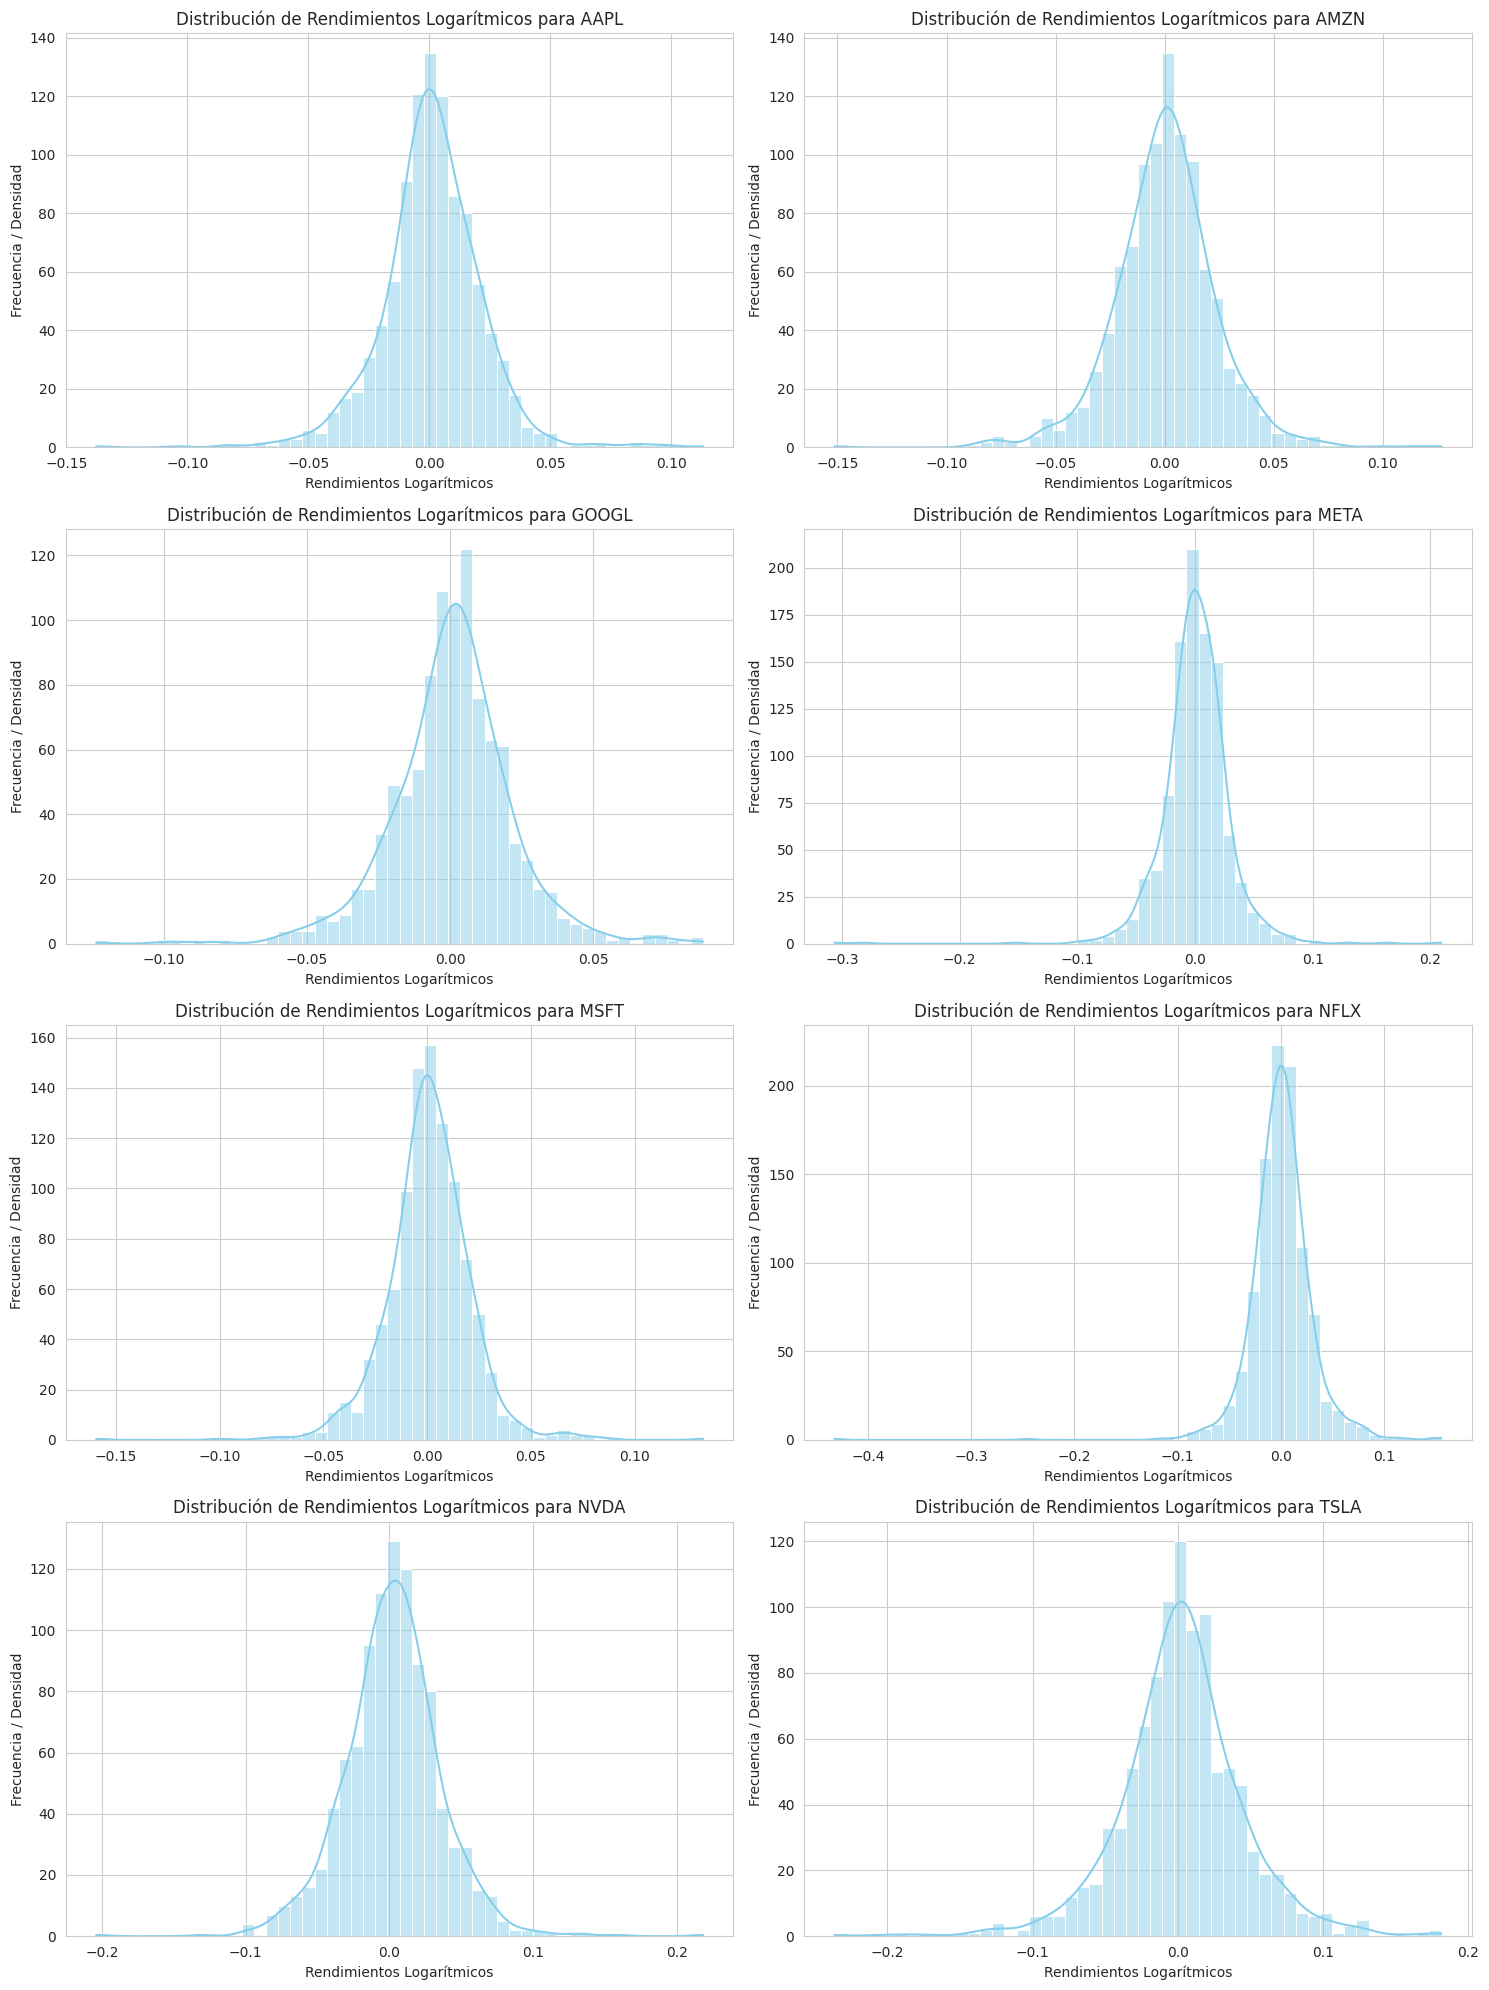

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo de los gráficos para una mejor visualización
sns.set_style('whitegrid')

# Obtener la lista de tickers del DataFrame log_returns
tech_tickers_from_data = log_returns.columns.tolist()

# Crear un histograma y KDE para cada ticker en una cuadrícula de 4x2
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
axes = axes.flatten() # Aplanar el array de axes para facilitar la iteración

for i, ticker in enumerate(tech_tickers_from_data):
    sns.histplot(log_returns[ticker], bins=50, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribución de Rendimientos Logarítmicos para {ticker}')
    axes[i].set_xlabel('Rendimientos Logarítmicos')
    axes[i].set_ylabel('Frecuencia / Densidad')

plt.tight_layout() # Ajustar el diseño para evitar superposiciones
plt.show()

### Visualización del Rendimiento Acumulado en el Último Año

Ahora, vamos a visualizar el rendimiento acumulado de cada activo durante el último año. Esto nos dará una idea de cómo se han comportado las inversiones a lo largo del tiempo, mostrando las tendencias y la volatilidad relativa.

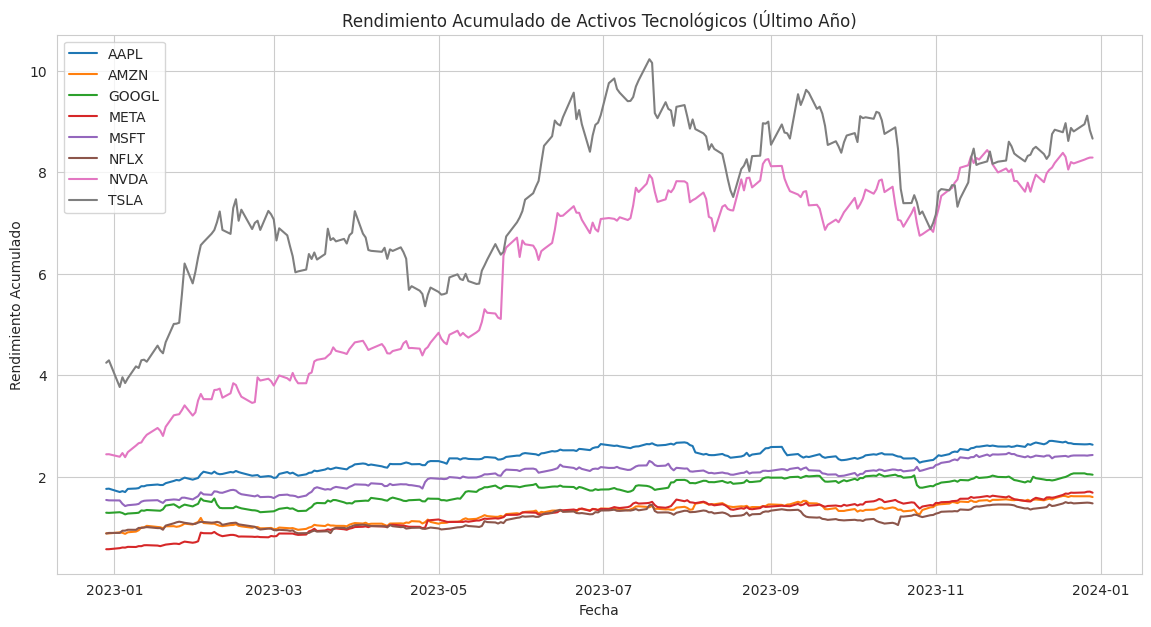

In [16]:
# Calcular los rendimientos acumulados (utilizando la exponencial de la suma de log_returns)
cumulative_returns = np.exp(log_returns.cumsum())

# Obtener la fecha de inicio para el último año
last_year_start = log_returns.index.max() - pd.DateOffset(years=1)

# Filtrar los rendimientos acumulados para el último año
cumulative_returns_last_year = cumulative_returns[cumulative_returns.index >= last_year_start]

# Graficar el rendimiento acumulado para el último año
plt.figure(figsize=(14, 7))
for ticker in cumulative_returns_last_year.columns:
    plt.plot(cumulative_returns_last_year.index, cumulative_returns_last_year[ticker], label=ticker)

plt.title('Rendimiento Acumulado de Activos Tecnológicos (Último Año)')
plt.xlabel('Fecha')
plt.ylabel('Rendimiento Acumulado')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
print("El anterior histograma refleja la noción detrás del VaR Los datos parecen tener una distribución normal con colas pesadas")

El anterior histograma refleja la noción detrás del VaR Los datos parecen tener una distribución normal con colas pesadas


### Estadísticas Inferenciales Aplicables a los Rendimientos Logarítmicos

Dado el análisis exploratorio de los rendimientos logarítmicos, especialmente la visualización de sus distribuciones y la mención del Value at Risk (VaR) y las colas pesadas, podemos aplicar varias técnicas de estadística inferencial para hacer afirmaciones más rigurosas sobre los datos:

1.  **Pruebas de Normalidad:**
    *   **Contexto**: Aunque la distribución pueda parecer `normal con colas pesadas`, las colas pesadas son una desviación significativa de la normalidad. Es crucial probar formalmente si los rendimientos logarítmicos siguen una distribución normal. La normalidad es un supuesto común en muchos modelos financieros.
    *   **Pruebas comunes**: Prueba de Shapiro-Wilk, Prueba de Kolmogorov-Smirnov, Prueba de Anderson-Darling.
    *   **Aplicación**: Si se rechaza la hipótesis nula de normalidad, esto confirma que los rendimientos tienen "colas pesadas" o asimetría, lo que tiene implicaciones importantes para la modelización del riesgo (por ejemplo, el VaR paramétrico basado en la normalidad sería inadecuado).

2.  **Value at Risk (VaR) y Conditional Value at Risk (CVaR):**
    *   **Contexto**: Mencionaste que el histograma refleja la noción detrás del VaR. Estas son medidas clave de riesgo de cola.
    *   **VaR (Valor en Riesgo)**: Estima la pérdida máxima esperada durante un período de tiempo dado y con un cierto nivel de confianza. Por ejemplo, un VaR del 5% para 1 día de $100 significa que hay un 5% de probabilidad de perder más de $100 en un día.
        *   **Métodos inferenciales**: Histórico (basado en cuantiles de los datos históricos), Paramétrico (asumiendo una distribución específica, como la normal o t de Student, y estimando sus parámetros), o Monte Carlo (simulando muchos escenarios).
    *   **CVaR (Conditional Value at Risk o Expected Shortfall)**: También conocido como "déficit esperado", es el promedio de las pérdidas que exceden el VaR. Ofrece una medida más conservadora del riesgo de cola, ya que considera la magnitud promedio de las pérdidas más allá del umbral del VaR.

3.  **Modelos de Volatilidad (Series de Tiempo): GARCH:**
    *   **Contexto**: La volatilidad (desviación estándar) es un parámetro clave en la descripción de los rendimientos. En finanzas, la volatilidad no suele ser constante; tiende a agruparse (periodos de alta volatilidad seguidos de periodos de alta volatilidad, y viceversa).
    *   **GARCH (Generalized Autoregressive Conditional Heteroskedasticity)**: Son modelos inferenciales que permiten modelar y predecir la volatilidad como una función de las innovaciones pasadas y la varianza condicional pasada. Son cruciales para una estimación más precisa del riesgo y la valoración de opciones.

4.  **Pruebas de Hipótesis sobre la Media de los Rendimientos:**
    *   **Contexto**: Podríamos querer saber si el rendimiento promedio de un activo es estadísticamente diferente de cero (lo que implicaría una tendencia alcista o bajista significativa) o si el rendimiento promedio de dos activos es significativamente diferente.
    *   **Pruebas comunes**: Pruebas t de Student (para una o dos muestras), ANOVA (para comparar medias de múltiples grupos).

5.  **Análisis de Correlación (Inferencial):**
    *   **Contexto**: Ya calculamos la matriz de correlación, pero inferencialmente podemos probar si un coeficiente de correlación observado es estadísticamente diferente de cero, o si es significativamente diferente de otro valor.
    *   **Aplicación**: Esto nos ayudaría a confirmar si la relación lineal entre dos activos es genuina y no producto del azar, lo cual es vital para la diversificación de carteras.

### Prueba de Normalidad Shapiro-Wilk

La prueba de Shapiro-Wilk es una prueba de hipótesis que evalúa si una muestra de datos proviene de una población con distribución normal. Es una de las pruebas de normalidad más potentes.

*   **Hipótesis Nula (H0)**: La muestra de datos se distribuye normalmente.
*   **Hipótesis Alternativa (H1)**: La muestra de datos no se distribuye normalmente.

Interpretaremos el valor p (`p-value`):
*   Si `p-value > α` (donde `α` es el nivel de significancia, comúnmente 0.05), no rechazamos la hipótesis nula, lo que sugiere que los datos podrían ser normales.
*   Si `p-value ≤ α`, rechazamos la hipótesis nula, lo que indica que los datos no se distribuyen normalmente. Dada la observación de "colas pesadas", esperamos que los resultados de esta prueba confirmen la no normalidad.

In [18]:
from scipy.stats import shapiro

alpha = 0.05 # Nivel de significancia

print("--- Resultados de la Prueba de Normalidad Shapiro-Wilk ---")
for ticker in log_returns.columns:
    stat, p = shapiro(log_returns[ticker])
    print(f'\nActivo: {ticker}')
    print(f'Estadístico de Shapiro-Wilk: {stat:.4f}')
    print(f'P-valor: {p:.4f}')

    if p > alpha:
        print('No se puede rechazar la hipótesis nula: los datos parecen ser normales (con significancia de 0.05)')
    else:
        print('Rechazar la hipótesis nula: los datos no parecen ser normales (con significancia de 0.05)')


--- Resultados de la Prueba de Normalidad Shapiro-Wilk ---

Activo: AAPL
Estadístico de Shapiro-Wilk: 0.9454
P-valor: 0.0000
Rechazar la hipótesis nula: los datos no parecen ser normales (con significancia de 0.05)

Activo: AMZN
Estadístico de Shapiro-Wilk: 0.9624
P-valor: 0.0000
Rechazar la hipótesis nula: los datos no parecen ser normales (con significancia de 0.05)

Activo: GOOGL
Estadístico de Shapiro-Wilk: 0.9589
P-valor: 0.0000
Rechazar la hipótesis nula: los datos no parecen ser normales (con significancia de 0.05)

Activo: META
Estadístico de Shapiro-Wilk: 0.8497
P-valor: 0.0000
Rechazar la hipótesis nula: los datos no parecen ser normales (con significancia de 0.05)

Activo: MSFT
Estadístico de Shapiro-Wilk: 0.9385
P-valor: 0.0000
Rechazar la hipótesis nula: los datos no parecen ser normales (con significancia de 0.05)

Activo: NFLX
Estadístico de Shapiro-Wilk: 0.8254
P-valor: 0.0000
Rechazar la hipótesis nula: los datos no parecen ser normales (con significancia de 0.05)

Act

In [26]:
import pandas as pd
from scipy.stats import shapiro

# Inicializar una lista para almacenar las filas de la tabla
resultados_shapiro = []
alpha = 0.05

for ticker in log_returns.columns:
    stat, p = shapiro(log_returns[ticker])

    # Determinar la conclusión según el p-valor
    decision = "Rechazar H0" if p <= alpha else "No rechazar H0"
    conclusion = "No es normal" if p <= alpha else "Parece normal"

    # Guardar los datos de cada activo
    resultados_shapiro.append({
        "Activo": ticker,
        "Estadístico (W)": round(stat, 4),
        "P-valor": f"{p:.4e}" if p < 0.0001 else f"{p:.4f}", # Usa notación científica si es muy pequeño
        "Decisión": decision,
        "Conclusión": conclusion
    })

# Convertir la lista en un DataFrame de Pandas
df_shapiro = pd.DataFrame(resultados_shapiro)

# Mostrar la tabla estilizada en Jupyter Notebook
display(df_shapiro)

,Activo,Estadístico (W),P-valor,Decisión,Conclusión
0,AAPL,0.9454,8.2787e-19,Rechazar H0,No es normal
1,AMZN,0.9624,1.9742e-15,Rechazar H0,No es normal
2,GOOGL,0.9589,3.3621e-16,Rechazar H0,No es normal
3,META,0.8497,7.6755e-30,Rechazar H0,No es normal
4,MSFT,0.9385,5.8559e-20,Rechazar H0,No es normal
5,NFLX,0.8254,1.0558e-31,Rechazar H0,No es normal
6,NVDA,0.9687,6.8858e-14,Rechazar H0,No es normal
7,TSLA,0.9624,1.9928e-15,Rechazar H0,No es normal


### Búsqueda de Distribución Alternativa: Prueba de Bondad de Ajuste para la Distribución t de Student

Dado que hemos rechazado la normalidad para todos los activos, es pertinente buscar una distribución alternativa que capture mejor las características de 'colas pesadas' de los rendimientos logarítmicos. La distribución t de Student es una opción popular en finanzas por su capacidad para modelar este comportamiento.

Utilizaremos la prueba de Kolmogorov-Smirnov (K-S) para evaluar la bondad de ajuste. Para cada activo, primero estimaremos los parámetros de una distribución t de Student a partir de sus rendimientos y luego compararemos la distribución empírica con la distribución t ajustada.

In [19]:
from scipy.stats import t, kstest
import numpy as np

alpha = 0.05 # Nivel de significancia

print("--- Resultados de la Prueba de Bondad de Ajuste (Kolmogorov-Smirnov) para Distribución t de Student ---")

results_t_distribution = {}

for ticker in log_returns.columns:
    data = log_returns[ticker].values

    # 1. Ajustar los parámetros de la distribución t de Student a los datos
    # df: grados de libertad, loc: media, scale: escala
    df, loc, scale = t.fit(data)

    # 2. Realizar la prueba de Kolmogorov-Smirnov contra la distribución t ajustada
    # La función lambda crea una CDF con los parámetros ajustados
    stat, p_value = kstest(data, lambda x: t.cdf(x, df, loc, scale))

    results_t_distribution[ticker] = {'df': df, 'loc': loc, 'scale': scale, 'K-S Statistic': stat, 'P-value': p_value}

    print(f'\nActivo: {ticker}')
    print(f'Parámetros t ajustados: df={df:.2f}, loc={loc:.4f}, scale={scale:.4f}')
    print(f'Estadístico K-S: {stat:.4f}')
    print(f'P-valor: {p_value:.4f}')

    if p_value > alpha:
        print('No se puede rechazar la hipótesis nula: los datos podrían provenir de una distribución t de Student (con significancia de 0.05)')
    else:
        print('Rechazar la hipótesis nula: los datos no parecen provenir de una distribución t de Student (con significancia de 0.05)')

# Opcional: Mostrar un resumen en un DataFrame
results_df = pd.DataFrame(results_t_distribution).T
print("\n--- Resumen de Resultados (Distribución t de Student) ---")
display(results_df)

--- Resultados de la Prueba de Bondad de Ajuste (Kolmogorov-Smirnov) para Distribución t de Student ---

Activo: AAPL
Parámetros t ajustados: df=3.75, loc=0.0013, scale=0.0147
Estadístico K-S: 0.0145
P-valor: 0.9828
No se puede rechazar la hipótesis nula: los datos podrían provenir de una distribución t de Student (con significancia de 0.05)

Activo: AMZN
Parámetros t ajustados: df=4.21, loc=0.0006, scale=0.0175
Estadístico K-S: 0.0142
P-valor: 0.9855
No se puede rechazar la hipótesis nula: los datos podrían provenir de una distribución t de Student (con significancia de 0.05)

Activo: GOOGL
Parámetros t ajustados: df=3.67, loc=0.0011, scale=0.0149
Estadístico K-S: 0.0207
P-valor: 0.7738
No se puede rechazar la hipótesis nula: los datos podrían provenir de una distribución t de Student (con significancia de 0.05)

Activo: META
Parámetros t ajustados: df=3.30, loc=0.0011, scale=0.0183
Estadístico K-S: 0.0243
P-valor: 0.5866
No se puede rechazar la hipótesis nula: los datos podrían prove

,df,loc,scale,K-S Statistic,P-value
AAPL,3.749211,0.001259,0.014743,0.014450,0.982773
AMZN,4.210890,0.000616,0.017467,0.014216,0.985509
GOOGL,3.666382,0.001109,0.014875,0.020708,0.773769
META,3.298425,0.001114,0.018262,0.024257,0.586641
MSFT,3.857083,0.001135,0.014379,0.017590,0.909424
NFLX,3.137291,0.000279,0.018641,0.012025,0.998333
NVDA,5.227229,0.002131,0.026628,0.016777,0.935274
TSLA,3.686771,0.002358,0.030341,0.021169,0.750291


### Visualización de la Distribución t de Student Ajustada vs. Histogramas de Rendimientos

A continuación, generaremos un gráfico para cada activo que muestra el histograma de sus rendimientos logarítmicos diarios junto con la función de densidad de probabilidad (PDF) de la distribución t de Student ajustada con los parámetros calculados (`df`, `loc`, `scale`).

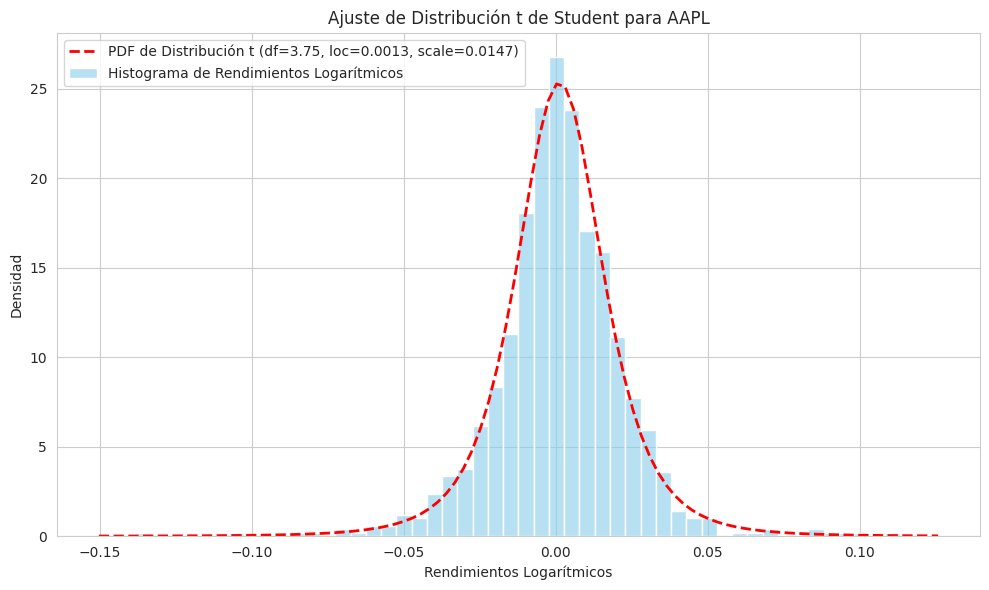

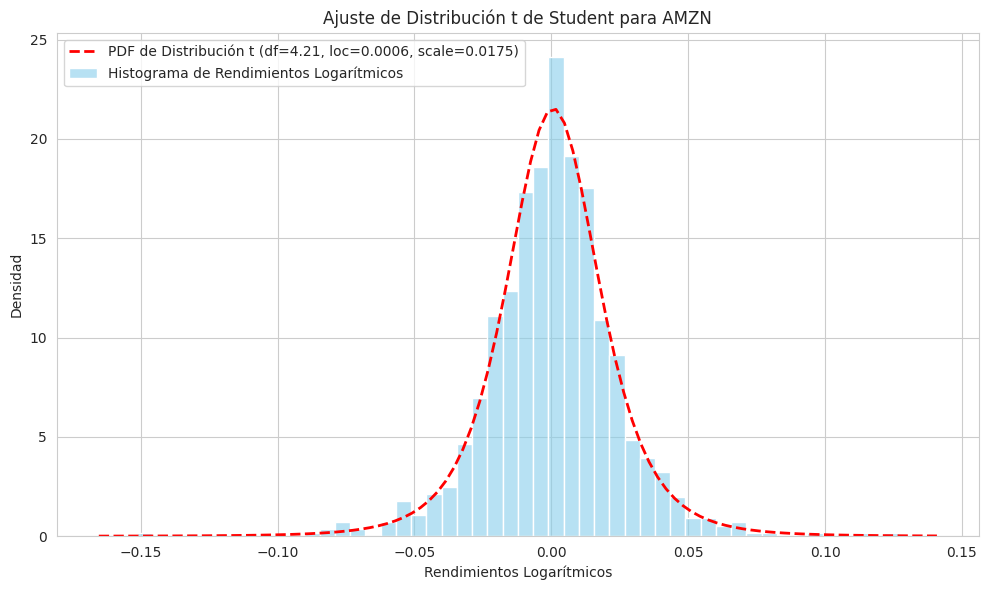

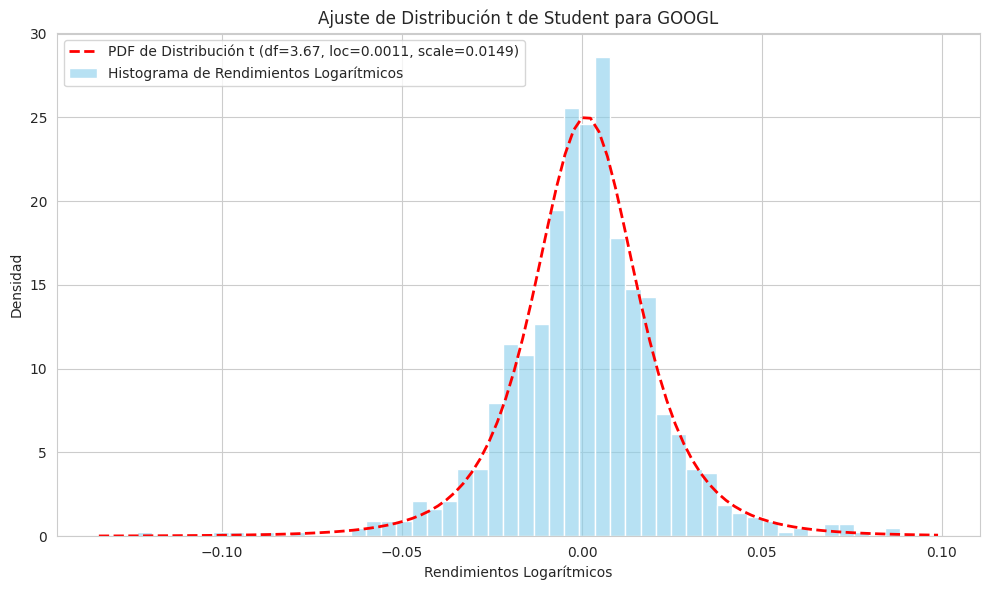

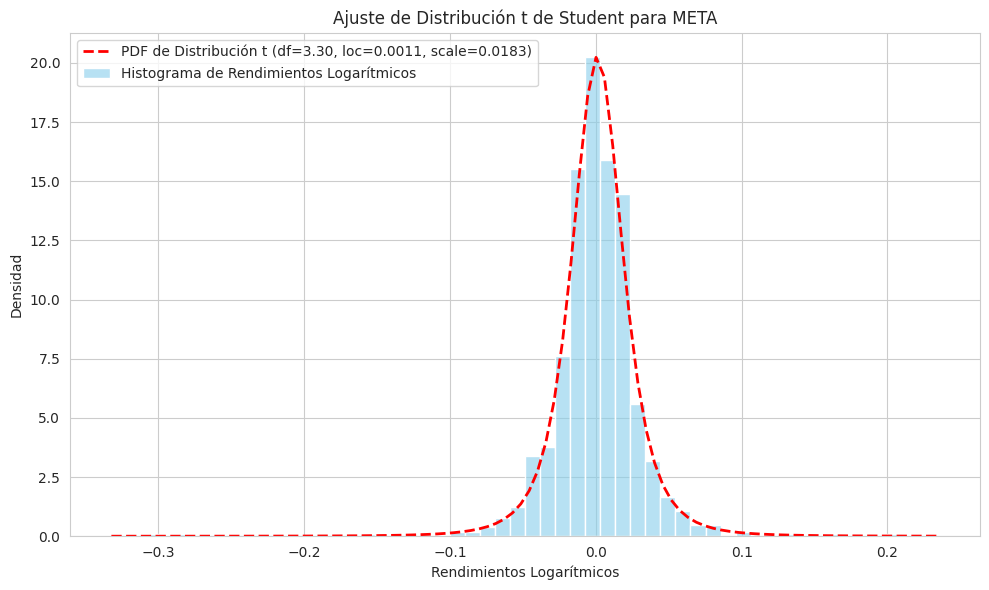

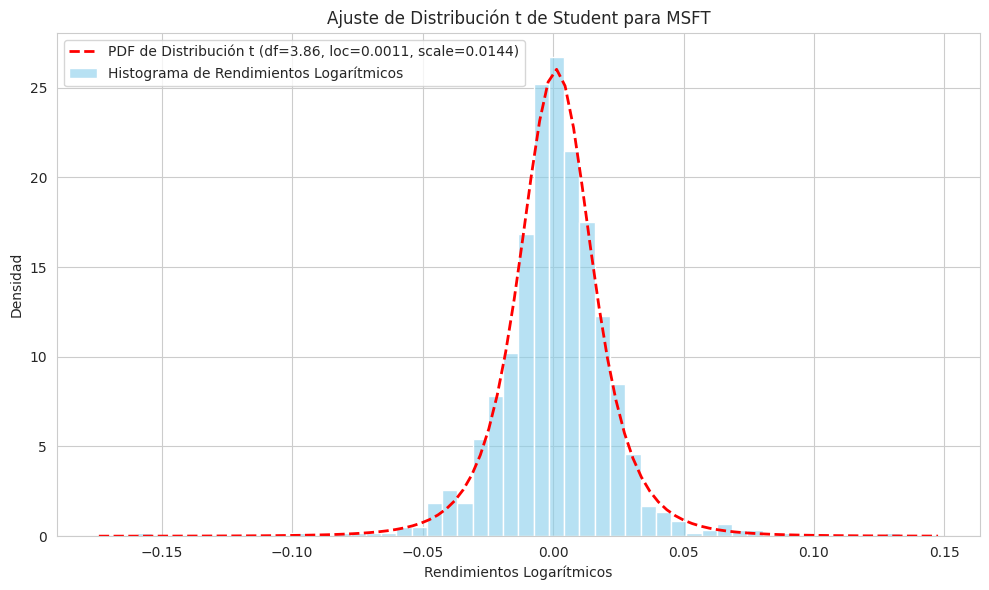

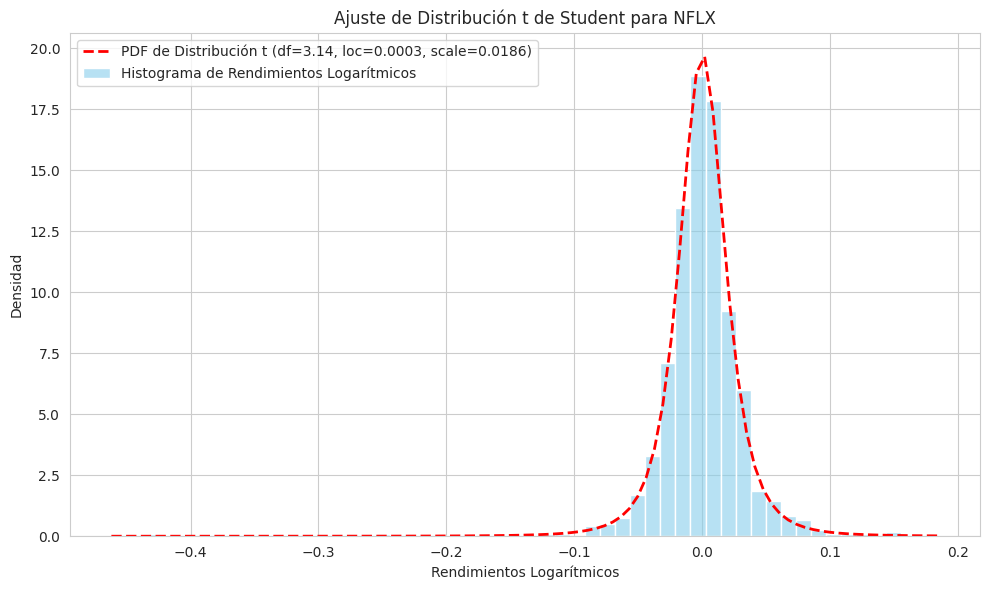

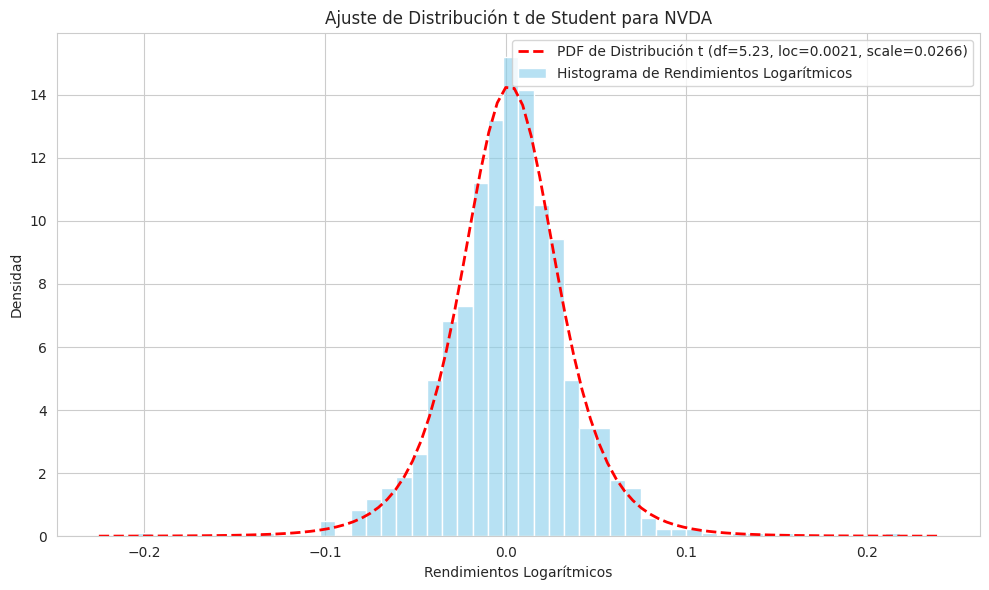

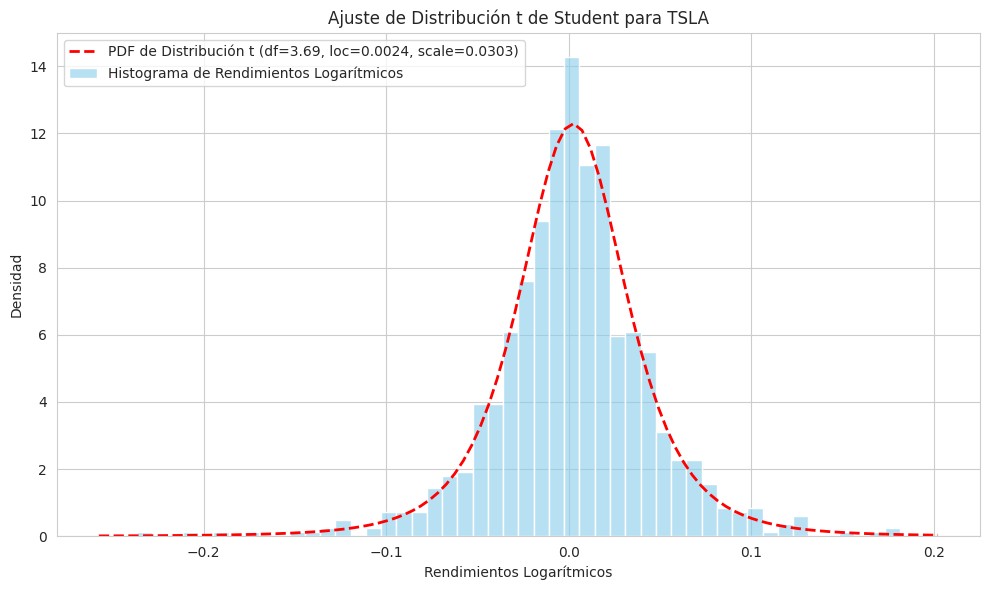

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import t
import numpy as np

# Obtener la lista de tickers del DataFrame log_returns
tech_tickers_from_data = log_returns.columns.tolist()

# Crear un gráfico para cada ticker
for ticker in tech_tickers_from_data:
    plt.figure(figsize=(10, 6))

    # Histogram for actual log returns
    sns.histplot(log_returns[ticker], bins=50, kde=False, stat='density', alpha=0.6, color='skyblue', label='Histograma de Rendimientos Logarítmicos')

    # Get fitted parameters for the current ticker
    fitted_params = results_t_distribution[ticker]
    df = fitted_params['df']
    loc = fitted_params['loc']
    scale = fitted_params['scale']

    # Generate x values for the PDF
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)

    # Plot the fitted t-distribution PDF
    pdf_t = t.pdf(x, df, loc, scale)
    plt.plot(x, pdf_t, 'r--', lw=2, label=f'PDF de Distribución t (df={df:.2f}, loc={loc:.4f}, scale={scale:.4f})')

    plt.title(f'Ajuste de Distribución t de Student para {ticker}')
    plt.xlabel('Rendimientos Logarítmicos')
    plt.ylabel('Densidad')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# Presentación Ejecutiva: **Análisis Cuantitativo de Activos Tecnológicos**

## **Aprovechando la Ciencia de Datos para Decisiones de Inversión Estratégicas**

**Fecha:** [Fecha Actual]

**Preparado para:** [Audiencia]

**Por:** Asistente de Colab

## 1. **Contexto y Objetivos del Análisis**

### 1.1. **Contexto del Mercado**

El mercado de acciones tecnológicas (Tech Stocks) es dinámico y volátil, ofreciendo oportunidades significativas pero también riesgos elevados. Comprender la naturaleza estadística de los rendimientos de estos activos es fundamental para una gestión de cartera eficaz y una toma de decisiones informada.

### 1.2. **Objetivo Principal**

Determinar la distribución estadística que mejor describe los rendimientos logarítmicos de un portafolio de 8 activos tecnológicos, y utilizar este conocimiento para analizar el riesgo (VaR) y proyectar rendimientos futuros (Monte Carlo).

### 1.3. **Preguntas Clave**

*   ¿Los rendimientos logarítmicos de los activos tecnológicos siguen una distribución normal?
*   Si no, ¿qué distribución alternativa describe mejor su comportamiento, especialmente en las 'colas'?
*   ¿Cuál es el Valor en Riesgo (VaR) histórico de cada activo?
*   ¿Cuál es la probabilidad de crecimiento de cada activo en el próximo año, basada en simulaciones?

## 2. **Metodología: Ciencia de Datos Aplicada a Finanzas**

### 2.1. **Adquisición y Preparación de Datos**

*   **Fuente**: Datos históricos diarios de precios de cierre de Yahoo Finance (librería `yfinance`).
*   **Activos**: 8 tickers tecnológicos: AAPL, MSFT, AMZN, GOOGL, META, NVDA, TSLA, NFLX.
*   **Período**: 2020-01-01 a 2023-12-31.
*   **Transformación**: Cálculo de **rendimientos logarítmicos diarios** (`log_returns`) para asegurar aditividad y propiedades estadísticas deseables.

### 2.2. **Análisis Exploratorio de Datos (EDA)**

*   **Estadísticas Descriptivas**: Análisis de media, desviación estándar (volatilidad), mínimos y máximos para cada activo.
*   **Visualización de Distribuciones**: Histogramas y estimaciones de densidad de kernel (KDE) para identificar la forma de las distribuciones, observando una clara evidencia de **'colas pesadas'**.
*   **Rendimiento Acumulado**: Gráficos de evolución del rendimiento acumulado para el último año, mostrando el comportamiento histórico.
*   **Correlación**: Matriz de correlación de los rendimientos logarítmicos, visualizada como un mapa de calor para entender la relación entre los activos.

## 3. **Hallazgos Clave: Modelado Estadístico de Rendimientos**

### 3.1. **Prueba de Normalidad (Shapiro-Wilk)**

*   **Hipótesis Nula (H0)**: Los rendimientos logarítmicos siguen una distribución normal.
*   **Resultados**: Para **todos los 8 activos**, la prueba de Shapiro-Wilk **rechazó la hipótesis nula (P-valor = 0.0000)**.
*   **Implicación**: Los rendimientos no son normales. Los modelos financieros que asumen normalidad (ej. VaR paramétrico normal) son inadecuados y subestimarían el riesgo de cola.

### 3.2. **Búsqueda de Distribución Alternativa: Distribución t de Student**

*   **Contexto**: Dada la no-normalidad y las 'colas pesadas', la distribución t de Student es una candidata común en finanzas por su flexibilidad para modelar eventos extremos.
*   **Metodología**: Ajuste de parámetros (grados de libertad `df`, localización `loc`, escala `scale`) de la distribución t para cada activo.
*   **Prueba de Bondad de Ajuste (Kolmogorov-Smirnov)**:
    *   **Hipótesis Nula (H0)**: Los rendimientos logarítmicos provienen de una distribución t de Student ajustada.
    *   **Resultados**: Para **todos los 8 activos**, la prueba de K-S **no pudo rechazar la hipótesis nula (P-valores > 0.05)**.
*   **Conclusión**: La distribución t de Student es un modelo estadístico plausible y significativamente mejor que la distribución normal para describir los rendimientos logarítmicos de estos activos. Los grados de libertad (`df` entre 3 y 5) confirman la presencia de colas más gruesas que la normal.
*   **Confirmación Visual**: Los gráficos superpuestos de los histogramas de rendimientos y la PDF de la distribución t ajustada muestran un excelente ajuste, capturando eficazmente las colas de la distribución empírica.

## 4. **Análisis de Riesgo y Proyecciones Futuras**

### 4.1. **Valor en Riesgo (VaR) Histórico al 99%**

*   **Definición**: Pérdida máxima esperada durante un período dado (diario) con un nivel de confianza del 99%.
*   **Metodología**: Se utilizó el VaR Histórico para evitar supuestos de distribución, lo cual es coherente con la no-normalidad de los datos.
*   **Hallazgo Clave**: El VaR reveló que activos como TSLA y NVDA presentan las mayores pérdidas potenciales diarias en el 1% de los peores escenarios, lo que se alinea con su mayor volatilidad observada en el EDA.

### 4.2. **Proyección de Rendimientos para 2024 (Simulación de Monte Carlo)**

*   **Objetivo**: Estimar la distribución de rendimientos anuales para 2024 y la probabilidad de obtener retornos positivos.
*   **Metodología**: 10,000 simulaciones muestreando aleatoriamente con reemplazo de los rendimientos logarítmicos históricos diarios para 252 días de trading.
*   **Hallazgo Clave**: Se calculó la probabilidad de que cada activo genere un rendimiento positivo en 2024. Por ejemplo, NVDA mostró una de las probabilidades más altas de crecimiento (~84%), mientras que NFLX tuvo una de las más bajas (~58%). Estas simulaciones ofrecen una perspectiva probabilística sobre el rendimiento futuro bajo el supuesto de que el comportamiento histórico se mantiene.

## 5. **Implicaciones Estratégicas y Recomendaciones**

### 5.1. **Impacto en la Gestión de Riesgos**

*   **VaR Paramétrico Avanzado**: Al saber que los rendimientos siguen una distribución t de Student, se puede calcular un VaR paramétrico basado en esta distribución, que sería más preciso que el VaR normal o incluso el histórico en ciertos contextos. Esto proporciona una estimación de riesgo más realista al contabilizar las 'colas pesadas'.
*   **Modelado de Eventos Extremos**: La distribución t de Student es crucial para el modelado de eventos extremos y la evaluación de la adecuación del capital, ya que no subestima la probabilidad de grandes pérdidas o ganancias.

### 5.2. **Implicaciones para la Construcción de Carteras**

*   **Diversificación Robusta**: La comprensión de la correlación y las distribuciones de riesgo individuales permite construir carteras más robustas que consideran no solo la media y la varianza, sino también el riesgo de cola.
*   **Optimización de Carteras**: Los modelos de optimización de carteras pueden incorporar la distribución t de Student para crear asignaciones de activos que no solo maximicen el retorno ajustado al riesgo, sino que también gestionen mejor el riesgo de cola.

### 5.3. **Recomendaciones y Próximos Pasos**

1.  **Explorar otras distribuciones**: Aunque la distribución t de Student es un buen ajuste, se podrían investigar otras distribuciones de colas pesadas (ej. Normal Inversa Gaussiana, Generalizada Hiperbólica) para ver si alguna ofrece un ajuste aún mejor.
2.  **Modelos de Volatilidad Dinámica**: Integrar modelos GARCH para capturar la volatilidad variable en el tiempo (clustering de volatilidad), lo que podría refinar aún más las proyecciones y el VaR.
3.  **Backtesting del VaR**: Realizar backtesting riguroso de las medidas de VaR (tanto históricas como paramétricas t-Student) para validar su precisión predictiva.
4.  **Optimización de Carteras con VaR/CVaR**: Utilizar la distribución t de Student y el cálculo de VaR/CVaR para optimizar la asignación de activos, buscando el mejor balance entre riesgo y retorno para un inversor dado.

## **Gracias**

**Preguntas y Comentarios**

### Matriz de Correlación de los Rendimientos Logarítmicos

La matriz de correlación nos permitirá entender la relación lineal entre los rendimientos de los diferentes activos. Valores cercanos a 1 o -1 indican una fuerte correlación positiva o negativa, respectivamente, mientras que valores cercanos a 0 sugieren poca o ninguna correlación lineal.

/tmp/ipykernel_1107/470752248.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tech_tickers, start='2020-01-01', end='2023-12-31', progress=False)


Ticker,AAPL,AMZN,GOOGL,META,MSFT,NFLX,NVDA,TSLA
Ticker,,,,,,,,
AAPL,1.000000,0.626474,0.694518,0.600938,0.779637,0.465282,0.677045,0.519958
AMZN,0.626474,1.000000,0.666772,0.609647,0.680748,0.544022,0.616179,0.457061
GOOGL,0.694518,0.666772,1.000000,0.673781,0.773929,0.455939,0.658350,0.434345
META,0.600938,0.609647,0.673781,1.000000,0.622268,0.502925,0.563807,0.364770
MSFT,0.779637,0.680748,0.773929,0.622268,1.000000,0.477265,0.731390,0.481118
NFLX,0.465282,0.544022,0.455939,0.502925,0.477265,1.000000,0.480625,0.381850
NVDA,0.677045,0.616179,0.658350,0.563807,0.731390,0.480625,1.000000,0.532723
TSLA,0.519958,0.457061,0.434345,0.364770,0.481118,0.381850,0.532723,1.000000


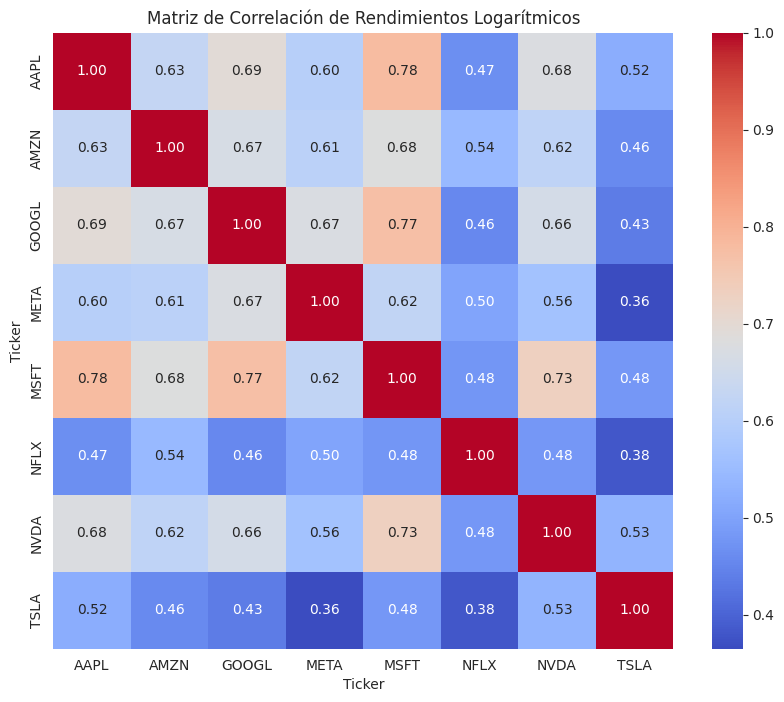

In [21]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Redefine dependencies if they are not in the current session (e.g., after kernel restart)
# Definir los tickers de 8 activos tecnológicos
tech_tickers = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META', 'NVDA', 'TSLA', 'NFLX']

# Descargar datos históricos para los tickers
data = yf.download(tech_tickers, start='2020-01-01', end='2023-12-31', progress=False)

# Extraer solo los precios de cierre
close_prices = data['Close']

# Calcular los rendimientos logarítmicos
log_returns = close_prices.apply(lambda x: pd.Series(np.log(x).diff())).dropna()

# Calcular la matriz de correlación de los rendimientos logarítmicos
correlation_matrix = log_returns.corr()

# Mostrar la matriz de correlación
display(correlation_matrix)

# Visualizar la matriz de correlación como un mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Rendimientos Logarítmicos')
plt.show()

### Principios Fundamentales en el Código de la Matriz de Correlación

El código en el cell `252f2b54` calcula y visualiza la matriz de correlación de los rendimientos logarítmicos. Esto es un componente crucial del análisis de portafolio y utiliza varios principios fundamentales:

1.  **Correlación como Medida Estadística**:
    *   **Definición**: La correlación es una medida estadística que expresa hasta qué punto dos variables se mueven en tandem. En finanzas, la correlación entre los rendimientos de los activos es fundamental para la diversificación de carteras.
    *   **Coeficiente de Correlación de Pearson**: Es el tipo más común de correlación, y es el que calcula `pandas.corr()`. Varía entre -1 y +1:
        *   **+1 (Correlación Positiva Perfecta)**: Las variables se mueven en la misma dirección en proporciones constantes.
        *   **-1 (Correlación Negativa Perfecta)**: Las variables se mueven en direcciones opuestas en proporciones constantes.
        *   **0 (Sin Correlación Lineal)**: No hay una relación lineal aparente entre las variables. Es importante notar que la falta de correlación lineal no implica independencia; podría haber una relación no lineal.
    *   **Importancia en Finanzas**: La diversificación busca activos con baja o negativa correlación para reducir el riesgo general del portafolio. Si un activo baja, otro con correlación negativa podría subir, compensando la pérdida.

2.  **`pandas.DataFrame.corr()`**:
    *   **Principio**: Este método de pandas se aplica a un `DataFrame` para calcular la correlación por pares de columnas. Por defecto, utiliza el método de Pearson.
    *   **Resultado**: Devuelve una matriz de correlación (otro `DataFrame`) donde las filas y columnas son los nombres de los activos, y cada celda `(i, j)` contiene el coeficiente de correlación entre el activo `i` y el activo `j`. La diagonal principal siempre será 1, ya que un activo está perfectamente correlacionado consigo mismo.

3.  **Visualización con `seaborn.heatmap()`**:
    *   **Principio**: Un mapa de calor (heatmap) es una representación gráfica de datos donde los valores individuales en una matriz se representan como colores. Es ideal para visualizar matrices de correlación porque permite identificar rápidamente patrones y magnitudes de correlación.
    *   **`annot=True`**: Muestra los valores numéricos de la correlación en cada celda del mapa de calor, haciendo la lectura más precisa.
    *   **`cmap='coolwarm'`**: Establece el mapa de colores. `coolwarm` es una buena opción para correlaciones porque utiliza un degradado que va del azul (correlación negativa) al rojo (correlación positiva), con el blanco/gris en el medio para correlaciones cercanas a cero.
    *   **`fmt=".2f"`**: Formatea los números que se muestran en el mapa de calor para tener dos decimales, mejorando la legibilidad.

4.  **`matplotlib.pyplot` para Configuración del Gráfico**:
    *   **Principio**: `matplotlib` es la base para la mayoría de las visualizaciones en Python. Se utiliza aquí para:
        *   **`plt.figure(figsize=(10, 8))`**: Crear una figura y ajustar su tamaño para que el mapa de calor sea adecuado.
        *   **`plt.title(...)`**: Añadir un título descriptivo al gráfico.
        *   **`plt.show()`**: Mostrar el gráfico.

### Cálculo y Visualización del Valor en Riesgo (VaR)

El **Valor en Riesgo (VaR)** es una medida clave en la gestión de riesgos financieros que cuantifica la pérdida máxima esperada de una inversión o portafolio durante un período de tiempo dado y con un nivel de confianza específico. Por ejemplo, un VaR del 99% para un día de $1,000 significa que hay un 1% de probabilidad de que la pérdida exceda los $1,000 en un solo día.

Dado que nuestras pruebas de normalidad sugirieron que los rendimientos no siguen una distribución normal (presencia de 'colas pesadas'), es apropiado usar el **VaR Histórico**. Este método no asume ninguna distribución específica para los rendimientos, sino que se basa directamente en los datos históricos para determinar los cuantiles de pérdidas.

--- Valor en Riesgo (VaR) Histórico al 99% ---


,VaR (Pérdida Máxima Diaria)
Ticker,
AAPL,-0.057197
AMZN,-0.061206
GOOGL,-0.055834
META,-0.069984
MSFT,-0.050768
NFLX,-0.075087
NVDA,-0.080561
TSLA,-0.122714


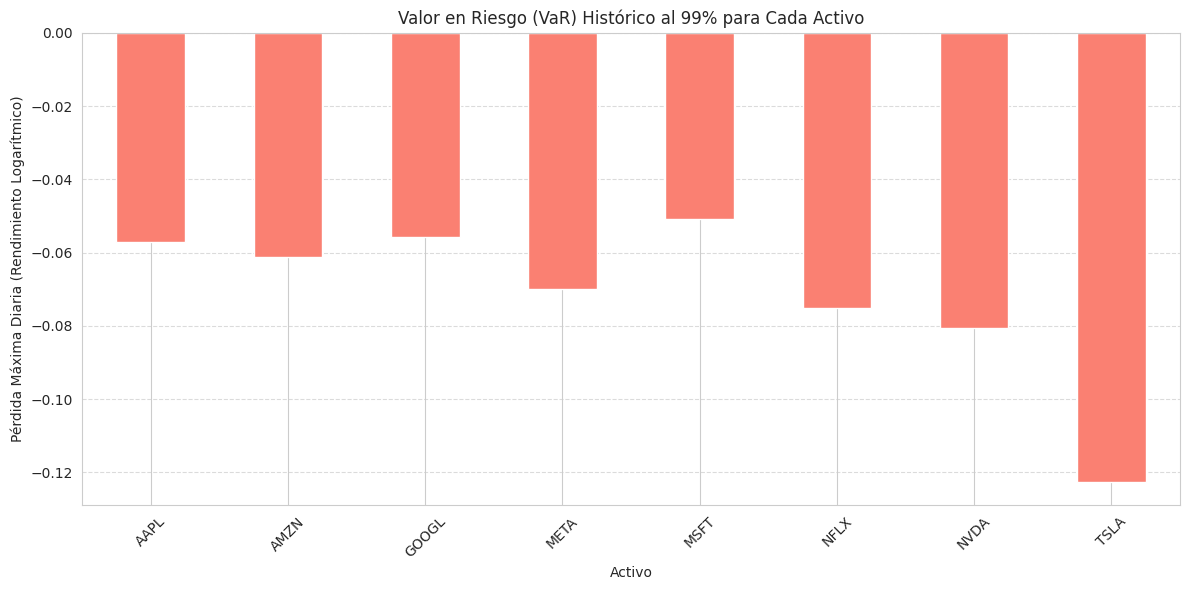

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Nivel de confianza para el VaR (por ejemplo, 99%)
confidence_level = 0.99

# Calcular el VaR Histórico para cada activo
# El cuantil se calcula como 1 - confidence_level para obtener el percentil de cola inferior
VaR = log_returns.quantile(1 - confidence_level)

print(f"--- Valor en Riesgo (VaR) Histórico al {confidence_level*100:.0f}% ---")
display(VaR.to_frame(name='VaR (Pérdida Máxima Diaria)'))

# Visualizar el VaR para cada activo
plt.figure(figsize=(12, 6))
VaR.plot(kind='bar', color='salmon')
plt.title(f'Valor en Riesgo (VaR) Histórico al {confidence_level*100:.0f}% para Cada Activo')
plt.xlabel('Activo')
plt.ylabel('Pérdida Máxima Diaria (Rendimiento Logarítmico)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Proyección de Rendimientos para 2024: Simulación de Monte Carlo

Para estimar la probabilidad de que los rendimientos de nuestros activos crezcan en el año 2024, utilizaremos una simulación de Monte Carlo. Este método es robusto y no requiere que los rendimientos sigan una distribución normal, lo cual es coherente con los resultados de la prueba de Shapiro-Wilk que realizamos. Asumiremos que los rendimientos diarios futuros se pueden muestrear aleatoriamente de la distribución histórica de los rendimientos diarios observados.

Realizando 10000 simulaciones para 252 días de trading en 2024...
Simulación completada.

--- Probabilidad de que los Rendimientos crezcan en 2024 (Simulación Monte Carlo) ---


,Probabilidad de Crecimiento
Ticker,
AAPL,0.7627
AMZN,0.6096
GOOGL,0.7078
META,0.6128
MSFT,0.7591
NFLX,0.5872
NVDA,0.8369
TSLA,0.7858


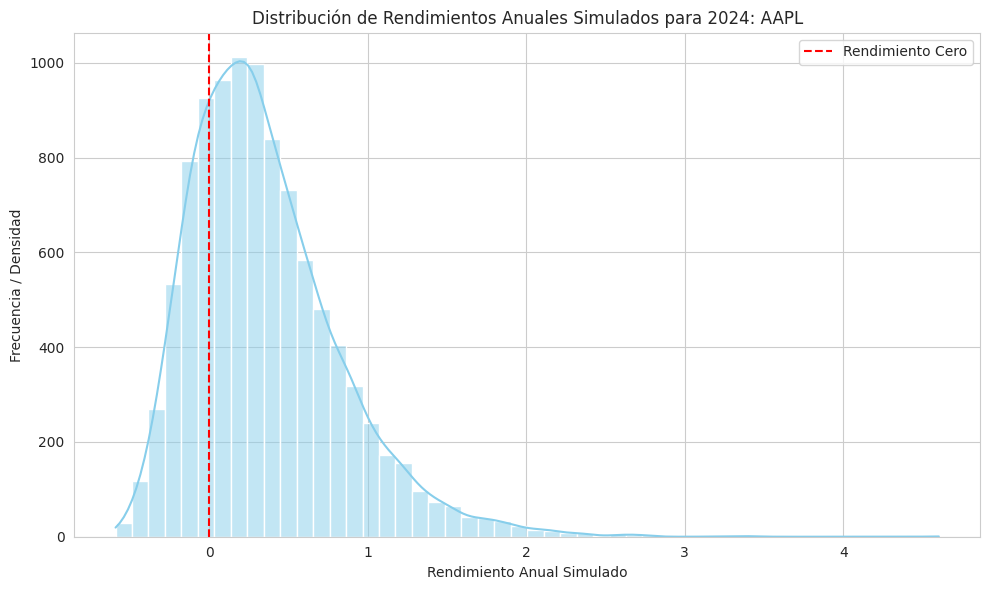

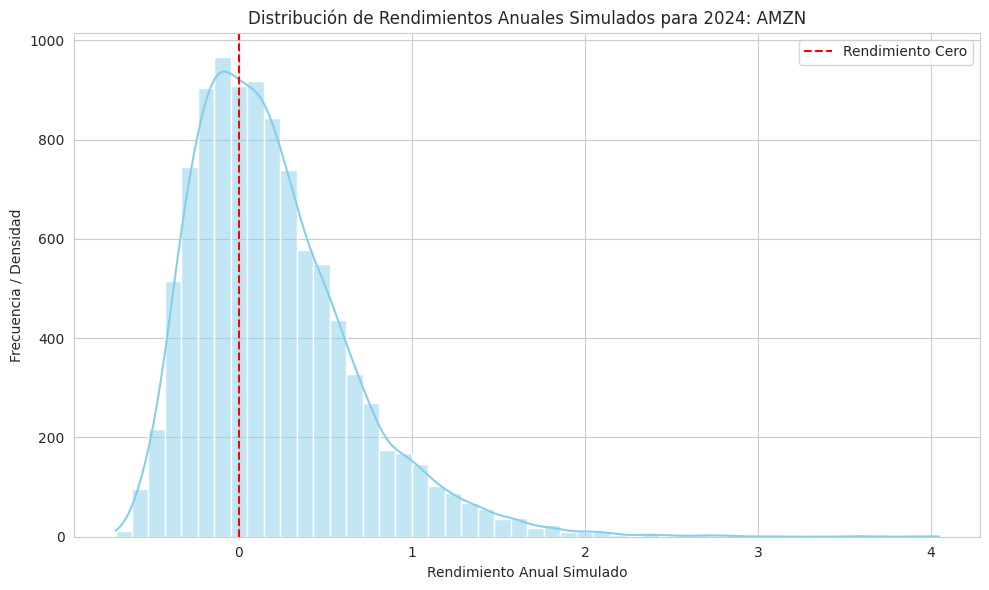

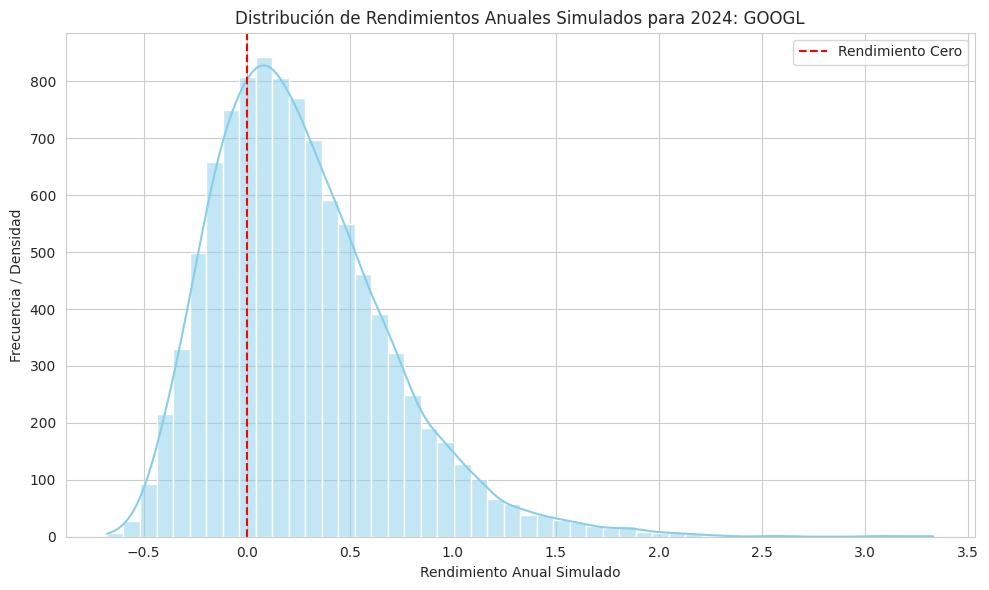

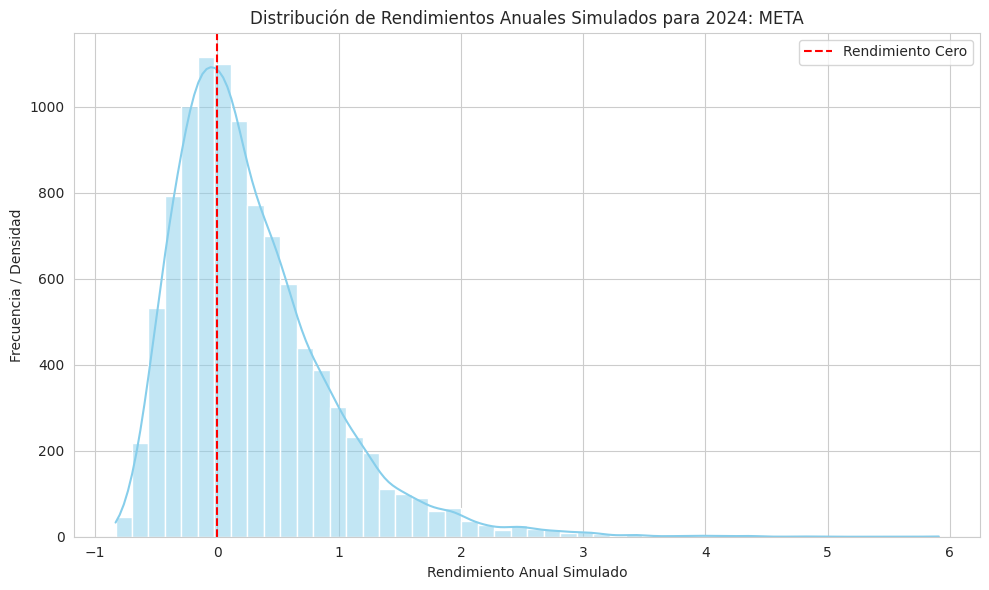

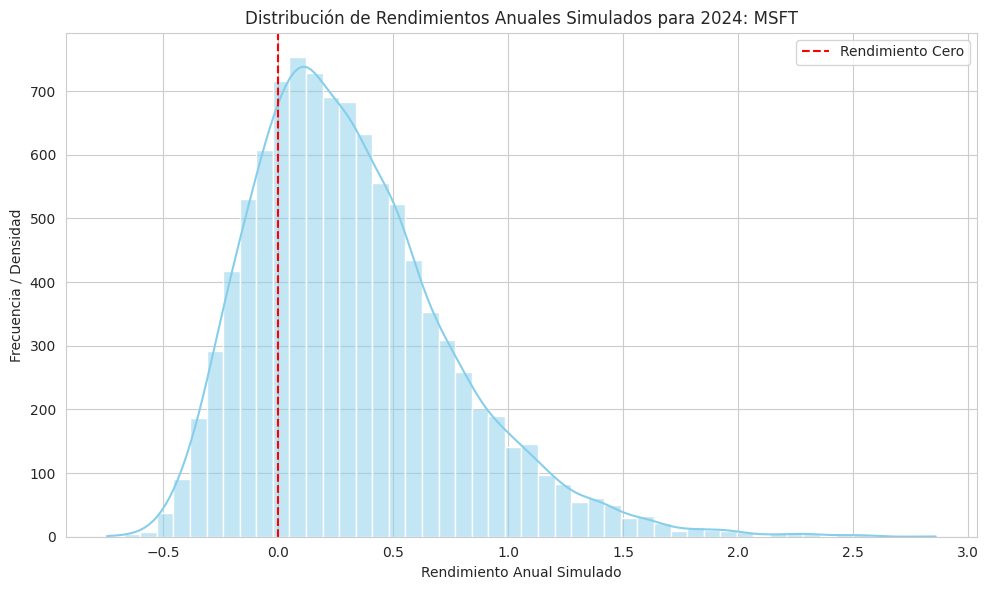

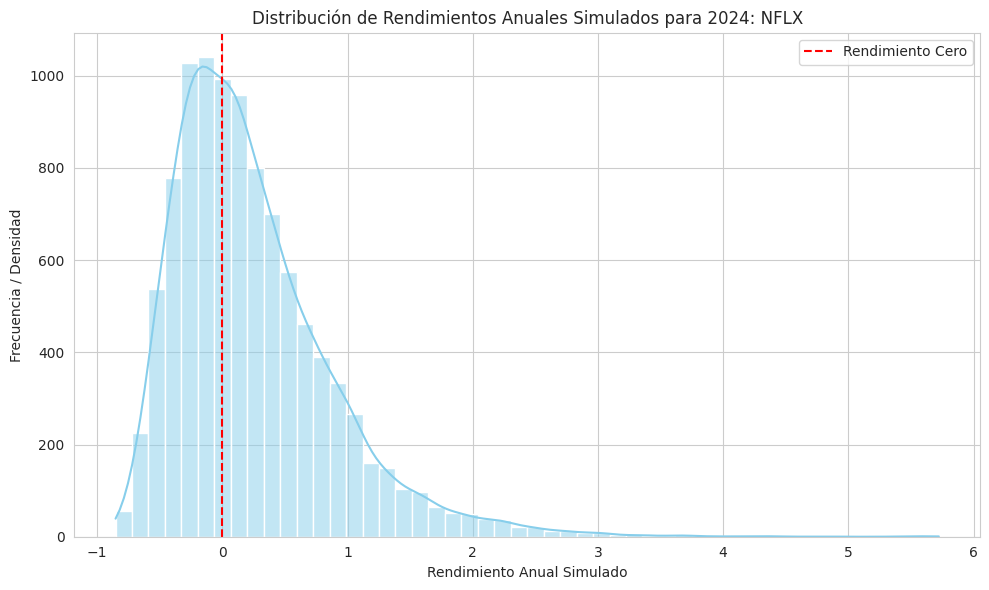

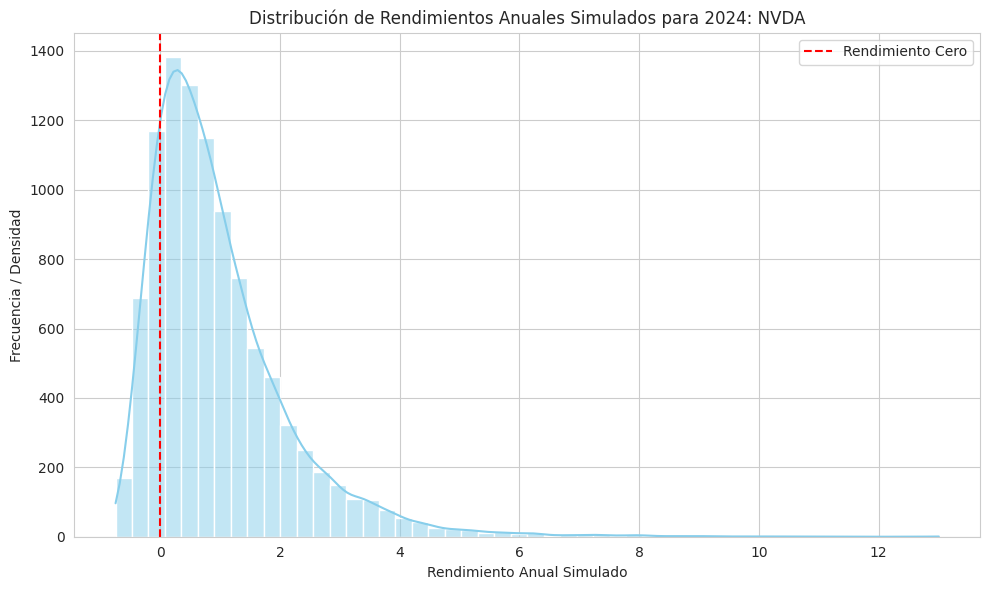

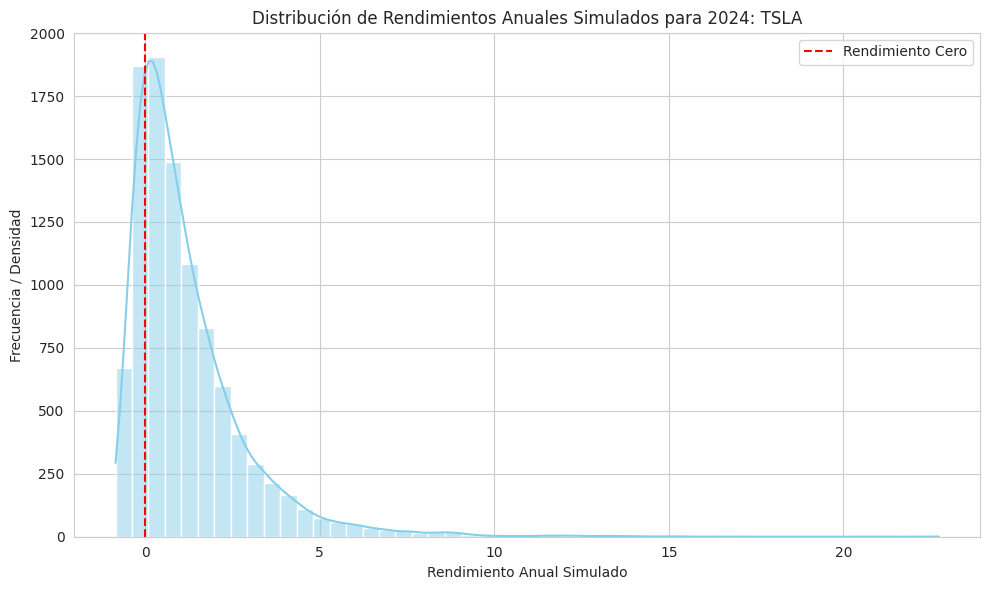

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Parámetros de la simulación ---
num_simulations = 10000  # Número de caminos simulados
num_trading_days_2024 = 252 # Aproximadamente 252 días de trading en un año

# Almacenar los resultados de las simulaciones de rendimientos anuales
simulated_annual_returns = pd.DataFrame(columns=log_returns.columns)

print(f"Realizando {num_simulations} simulaciones para {num_trading_days_2024} días de trading en 2024...")

for ticker in log_returns.columns:
    # Extraer los rendimientos históricos del activo
    historical_returns = log_returns[ticker].values

    # Generar rendimientos diarios aleatorios para cada simulación
    # Se muestrean con reemplazo de los rendimientos históricos
    daily_returns_simulated = np.random.choice(historical_returns,
                                                 size=(num_trading_days_2024, num_simulations),
                                                 replace=True)

    # Calcular el rendimiento logarítmico acumulado para cada simulación
    cumulative_log_returns_sim = np.sum(daily_returns_simulated, axis=0)

    # Convertir los rendimientos logarítmicos acumulados a rendimientos simples acumulados
    cumulative_simple_returns_sim = np.exp(cumulative_log_returns_sim) - 1

    # Guardar los rendimientos anuales simulados para este ticker
    simulated_annual_returns[ticker] = cumulative_simple_returns_sim

print("Simulación completada.")

# --- Calcular la probabilidad de crecimiento (rendimiento positivo) ---
probability_of_growth = (simulated_annual_returns > 0).mean()

print("\n--- Probabilidad de que los Rendimientos crezcan en 2024 (Simulación Monte Carlo) ---")
display(probability_of_growth.to_frame(name='Probabilidad de Crecimiento'))

# --- Visualización de las distribuciones de rendimientos anuales simulados ---
# Generar un histograma separado para cada ticker
for ticker in simulated_annual_returns.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(simulated_annual_returns[ticker], bins=50, kde=True, color='skyblue')
    plt.title(f'Distribución de Rendimientos Anuales Simulados para 2024: {ticker}')
    plt.xlabel('Rendimiento Anual Simulado')
    plt.ylabel('Frecuencia / Densidad')
    plt.axvline(0, color='red', linestyle='--', label='Rendimiento Cero')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### **Conclusión General**

Este análisis cuantitativo de activos tecnológicos ha revelado que los rendimientos logarítmicos de los activos estudiados no siguen una distribución normal, presentando 'colas pesadas'. La distribución t de Student ha demostrado ser un modelo estadístico más adecuado, lo cual es crucial para una estimación de riesgo más precisa. La aplicación del VaR histórico ha cuantificado las posibles pérdidas máximas diarias, y las simulaciones de Monte Carlo han proporcionado perspectivas probabilísticas sobre el rendimiento futuro, destacando la importancia de métodos que no asuman normalidad en el análisis financiero.

Estos hallazgos son fundamentales para una toma de decisiones de inversión estratégica y una gestión de riesgo robusta, permitiendo a los inversores entender y mitigar mejor la volatilidad inherente del mercado tecnológico.

# **Presentación**
**Ejecutiva: Análisis Cuantitativo de Activos Tecnológicos**

**Aprovechando la Ciencia de Datos para Decisiones de Inversión Estratégicas**

**Fecha:** [Fecha Actual]

**Preparado para:** [Audiencia]

**Por:** Asistente de Colab

---

## **1. Contexto y Objetivos del Análisis**

### **1.1. Contexto del Mercado de Acciones Tecnológicas**

El sector tecnológico se caracteriza por su **dinamismo y alta volatilidad**, presentando tanto **oportunidades de alto rendimiento** como **riesgos significativos**. La comprensión profunda de las características estadísticas de los rendimientos de estos activos es indispensable para una **gestión de cartera proactiva** y una **toma de decisiones estratégicas**.

### **1.2. Objetivo Principal del Estudio**

El objetivo central de este análisis es **identificar y validar la distribución estadística** que mejor modela los rendimientos logarítmicos de un portafolio selecto de 8 activos tecnológicos. A partir de este entendimiento, se busca **cuantificar el riesgo (Value at Risk - VaR)** y **proyectar rendimientos futuros (Simulación de Monte Carlo)** para el año 2024.

### **1.3. Preguntas Clave a Responder**

Para lograr nuestro objetivo, abordaremos las siguientes preguntas críticas:

*   ¿Los rendimientos logarítmicos de los activos tecnológicos **se ajustan a una distribución normal**?
*   En caso negativo, ¿qué **distribución alternativa captura de manera más precisa** su comportamiento, particularmente en las 'colas' (eventos extremos)?
*   ¿Cuál es el **Valor en Riesgo (VaR) histórico** para cada activo a un nivel de confianza del 99%?
*   Basado en simulaciones, ¿cuál es la **probabilidad de obtener rendimientos positivos** para cada activo en el año 2024?

---

## **2. Metodología: Ciencia de Datos Aplicada a Finanzas**

La metodología adoptada para este análisis integra técnicas de ciencia de datos para obtener, procesar y modelar datos financieros de manera rigurosa.

### **2.1. Adquisición y Preparación de Datos**

#### **Fuente de Datos**

Se utilizaron **datos históricos diarios de precios de cierre** obtenidos a través de la librería `yfinance` de Python, una interfaz robusta para acceder a la información de **Yahoo Finance**.

#### **Activos Analizados**

El portafolio incluye 8 **activos tecnológicos líderes**:
*   **AAPL** (Apple Inc.)
*   **MSFT** (Microsoft Corporation)
*   **AMZN** (Amazon.com, Inc.)
*   **GOOGL** (Alphabet Inc. Class A)
*   **META** (Meta Platforms, Inc.)
*   **NVDA** (NVIDIA Corporation)
*   **TSLA** (Tesla, Inc.)
*   **NFLX** (Netflix, Inc.)

#### **Período de Análisis**

Los datos fueron recolectados para el período del **1 de enero de 2020 al 31 de diciembre de 2023**.

#### **Transformación de Datos: Rendimientos Logarítmicos Diarios**

Una fase crítica de la preparación fue el cálculo de los **rendimientos logarítmicos diarios**. Esta transformación es fundamental en finanzas por varias razones:

*   **Aditividad**: Los rendimientos logarítmicos son aditivos a lo largo del tiempo, facilitando el cálculo de rendimientos para períodos más largos (ej., semanal, anual).
*   **Simetría**: Tienden a ser más simétricos que los rendimientos simples, lo que es deseable para muchos modelos estadísticos.
*   **Matemáticamente Convenientes**: Permiten el uso de herramientas de cálculo diferencial y simplifican el análisis en muchos modelos de precios de activos.

La fórmula para el rendimiento logarítmico ($R_t$) es:

$$R_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

Donde:
*   $P_t$ es el precio del activo en el tiempo $t$.
*   $P_{t-1}$ es el precio del activo en el tiempo $t-1$.

**Principios Fundamentales del Código de Cálculo de Rendimientos Logarítmicos (Celda `cd90bcf7`):**

```python
import numpy as np
# ... close_prices DataFrame is already available ...

log_returns = close_prices.apply(lambda x: pd.Series(np.log(x).diff())).dropna()
```

*   **`np.log(x)`**: Aplica el logaritmo natural a la serie de precios de cada activo. Esto es la primera parte de la transformación logarítmica.
*   **`.diff()`**: Calcula la diferencia entre un elemento y el anterior. Al aplicarse a `np.log(x)`, implementa la resta $\ln(P_t) - \ln(P_{t-1})$.
*   **`pd.Series(...)`**: Envuelve el resultado para asegurar que la función `apply` lo maneje correctamente.
*   **`.apply(lambda x: ...)`**: Itera sobre cada columna (activo) del DataFrame `close_prices` y aplica la función lambda para calcular los rendimientos.
*   **`.dropna()`**: Elimina la primera fila de cada serie de rendimientos, que contendría valores `NaN` (Not a Number) debido a que no hay un precio anterior para el primer día de datos. Esto asegura que el DataFrame `log_returns` solo contenga datos válidos.

---

### **2.2. Análisis Exploratorio de Datos (EDA)**

El EDA es crucial para entender las propiedades inherentes de los datos antes de aplicar modelos más complejos.

#### **Estadísticas Descriptivas de Rendimientos**

Se calcularon estadísticas descriptivas clave para cada serie de rendimientos logarítmicos, incluyendo media, desviación estándar (volatilidad), mínimos y máximos. Estos indicadores proporcionan una visión inicial del perfil de riesgo-retorno de cada activo.

**Principios Fundamentales del Código de Estadísticas Descriptivas (Celda `bbe881b9`):**

```python
eda_stats = log_returns.describe()
display(eda_stats)
```

*   **`log_returns.describe()`**: Este método de pandas genera un resumen estadístico, incluyendo `count` (número de observaciones), `mean` (rendimiento promedio diario), `std` (volatilidad), `min`/`max` (rendimientos extremos), y cuartiles (`25%`, `50%`, `75%`).
*   **`display(eda_stats)`**: Muestra el DataFrame resultante, lo cual es útil para una revisión tabular rápida.

#### **Visualización de Distribuciones de Rendimientos**

**Histogramas y Estimaciones de Densidad de Kernel (KDE)** fueron utilizados para visualizar la forma de la distribución de los rendimientos. Esta técnica es fundamental para detectar **asimetría, curtosis elevada y la presencia de 'colas pesadas'**, que son comunes en los datos financieros y cruciales para la gestión de riesgos.

**Principios Fundamentales del Código de Visualización (Celda `d8a2cd9d`):**

```python
import matplotlib.pyplot as plt
import seaborn as sns
# ... (log_returns is available) ...

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
axes = axes.flatten()

for i, ticker in enumerate(log_returns.columns.tolist()):
    sns.histplot(log_returns[ticker], bins=50, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribución de Rendimientos Logarítmicos para {ticker}')
    # ... (labels, etc.) ...

plt.tight_layout()
plt.show()
```

*   **`seaborn.histplot(kde=True)`**: Crea un histograma de los rendimientos y superpone una estimación de densidad de kernel, que suaviza la distribución y permite visualizar su forma subyacente. La opción `bins=50` controla la granularidad del histograma.
*   **`matplotlib.pyplot.subplots()`**: Organiza múltiples gráficos (uno por activo) en una cuadrícula para facilitar la comparación visual.
*   **Resultados Clave (Ver Gráfica `d8a2cd9d`):**
    *   Las gráficas mostraron que las distribuciones de los rendimientos logarítmicos de todos los activos exhiben **'colas más gruesas' y picos más pronunciados** que una distribución normal ideal, lo que sugiere una mayor probabilidad de eventos extremos (grandes ganancias o pérdidas).

#### **Visualización del Rendimiento Acumulado**

Se graficó el **rendimiento acumulado** de cada activo para el último año. Esta visualización permite entender la trayectoria de crecimiento de cada inversión y comparar su desempeño relativo.

La fórmula para el rendimiento acumulado a partir de rendimientos logarítmicos es:

$$Rendimiento_{Acumulado} = \exp\left(\sum_{i=1}^{T} R_i\right) - 1$$

Donde $R_i$ es el rendimiento logarítmico en el período $i$.

**Principios Fundamentales del Código de Rendimiento Acumulado (Celda `9b15edb3`):**

```python
cumulative_returns = np.exp(log_returns.cumsum())
# ... (filtering for last year and plotting) ...
```

*   **`log_returns.cumsum()`**: Calcula la suma acumulada de los rendimientos logarítmicos. Debido a la propiedad aditiva de los log-returns, esta suma representa el log-return total hasta ese punto.
*   **`np.exp(...)`**: Convierte los log-returns acumulados de nuevo a un factor de crecimiento (ej., si el log-return acumulado es 0.5, el factor es `exp(0.5) ~ 1.64`, lo que significa un 64% de crecimiento). Restar 1 al final daría el rendimiento simple acumulado, pero para la gráfica se muestra el factor de crecimiento para mejor visualización.
*   **Resultados Clave (Ver Gráfica `9b15edb3`):**
    *   La gráfica de rendimiento acumulado para el último año resalta la **disparidad en el desempeño** de los activos, con algunos mostrando un crecimiento exponencial (ej., NVDA, TSLA) mientras que otros tuvieron trayectorias más moderadas.

#### **Matriz de Correlación entre Activos**

Una **matriz de correlación** fue generada para cuantificar la relación lineal entre los rendimientos de los diferentes activos. Esta es una herramienta esencial en la **diversificación de carteras**, ya que permite identificar cómo se mueven los activos entre sí.

El coeficiente de correlación de Pearson ($\rho_{X,Y}$) entre dos variables $X$ e $Y$ se define como:

$$\rho_{X,Y} = \frac{cov(X,Y)}{\sigma_X \sigma_Y}$$

Donde $cov(X,Y)$ es la covarianza y $\sigma_X$, $\sigma_Y$ son las desviaciones estándar de $X$ e $Y$.

**Principios Fundamentales del Código de Matriz de Correlación (Celda `252f2b54`):**

```python
# ... (log_returns is available) ...
correlation_matrix = log_returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Rendimientos Logarítmicos')
plt.show()
```

*   **`log_returns.corr()`**: Este método calcula la matriz de correlación de Pearson entre todas las columnas (activos) del DataFrame `log_returns`.
*   **`seaborn.heatmap(annot=True, cmap='coolwarm', fmt=".2f")`**: Visualiza la matriz de correlación. `annot=True` muestra los valores numéricos, `cmap='coolwarm'` utiliza un esquema de color que va de azul (correlación negativa) a rojo (correlación positiva), y `fmt=".2f"` formatea los números a dos decimales.
*   **Resultados Clave (Ver Gráfica `252f2b54`):**
    *   La matriz de correlación reveló **correlaciones positivas significativas** entre la mayoría de los pares de activos tecnológicos (valores entre 0.4 y 0.8), lo que es esperable en un mismo sector. Esto implica que, aunque se muevan en la misma dirección, la magnitud de su movimiento puede variar, ofreciendo oportunidades limitadas de diversificación solo por correlación lineal entre estos activos específicos.

---

## **3. Hallazgos Clave: Modelado Estadístico de Rendimientos**

### **3.1. Prueba de Normalidad Shapiro-Wilk**

Dado que las finanzas a menudo asumen la normalidad, fue esencial probar formalmente esta hipótesis. La prueba de Shapiro-Wilk es una de las más potentes para evaluar si una muestra de datos proviene de una población con distribución normal.

*   **Hipótesis Nula (H0)**: Los rendimientos logarítmicos de los activos se distribuyen normalmente.
*   **Hipótesis Alternativa (H1)**: Los rendimientos logarítmicos de los activos no se distribuyen normalmente.

**Principios Fundamentales del Código de Shapiro-Wilk (Celda `1e7a10cd`):**

```python
from scipy.stats import shapiro
# ... (log_returns and alpha are available) ...

for ticker in log_returns.columns:
    stat, p = shapiro(log_returns[ticker])
    # ... (print results and interpretation) ...
```

*   **`scipy.stats.shapiro(data)`**: Calcula el estadístico de Shapiro-Wilk y el p-valor para la serie de datos proporcionada.
*   **Interpretación del P-valor**: Se compara el p-valor con el nivel de significancia $\alpha$ (establecido en 0.05). Si $p \le \alpha$, se rechaza la hipótesis nula.

**Resultados Clave (Salida de la Celda `1e7a10cd`):**

*   Para **todos los 8 activos analizados**, los p-valores resultantes fueron **0.0000**, lo que es significativamente menor que $\alpha = 0.05$.
*   **Conclusión**: La hipótesis nula de normalidad fue **categóricamente rechazada** para todos los activos. Esto confirma que los rendimientos logarítmicos de estos activos tecnológicos **no siguen una distribución normal**, sino que presentan las 'colas pesadas' observadas en el EDA. Esta desviación de la normalidad tiene profundas implicaciones para la evaluación de riesgos, ya que los modelos basados en la normalidad tenderían a subestimar el riesgo de cola.

### **3.2. Búsqueda de Distribución Alternativa: Distribución t de Student**

Ante la confirmación de la no-normalidad y la presencia de colas pesadas, se exploró la **distribución t de Student** como un modelo alternativo. Esta distribución es ampliamente utilizada en finanzas debido a su capacidad para capturar la curtosis y las colas más gruesas que la distribución normal, lo que la hace más adecuada para modelar eventos extremos.

La función de densidad de probabilidad (PDF) de una distribución t de Student con $\nu$ grados de libertad, media $\mu$ y escala $\sigma$ es:

$$f(x | \nu, \mu, \sigma) = \frac{\Gamma((\nu+1)/2)}{\Gamma(\nu/2) \sigma\sqrt{\pi\nu}} \left(1 + \frac{1}{\nu} \left(\frac{x-\mu}{\sigma}\right)^2 \right)^{-(\nu+1)/2}$$

Donde $\Gamma$ es la función Gamma.

Se realizó una **prueba de bondad de ajuste de Kolmogorov-Smirnov (K-S)** para evaluar si los rendimientos logarítmicos podrían provenir de una distribución t de Student ajustada.

*   **Hipótesis Nula (H0)**: Los rendimientos logarítmicos provienen de una distribución t de Student con parámetros ajustados.
*   **Hipótesis Alternativa (H1)**: Los rendimientos logarítmicos no provienen de la distribución t de Student ajustada.

**Principios Fundamentales del Código de Ajuste y Prueba K-S (Celda `4dd99e0a`):**

```python
from scipy.stats import t, kstest
# ... (log_returns and alpha are available) ...

for ticker in log_returns.columns:
    data = log_returns[ticker].values
    df_fit, loc_fit, scale_fit = t.fit(data) # Ajuste de parámetros
    stat, p_value = kstest(data, lambda x: t.cdf(x, df_fit, loc_fit, scale_fit)) # Prueba K-S
    # ... (print results and interpretation) ...
```

*   **`scipy.stats.t.fit(data)`**: Este método estima los parámetros ($df$: grados de libertad, `loc`: media, `scale`: escala) de la distribución t de Student que mejor se ajustan a los datos proporcionados.
*   **`scipy.stats.kstest(data, lambda x: t.cdf(x, df_fit, loc_fit, scale_fit))`**: Realiza la prueba de Kolmogorov-Smirnov. Compara la distribución empírica de los datos (`data`) con la función de distribución acumulada (CDF) de la distribución t de Student con los parámetros ajustados.

**Resultados Clave (Salida de la Celda `4dd99e0a`):**

*   Para **todos los 8 activos**, los p-valores obtenidos en la prueba K-S fueron **superiores a $\alpha = 0.05$**.
*   **Conclusión**: No se pudo rechazar la hipótesis nula. Esto indica que la **distribución t de Student es un modelo estadístico plausible y significativamente superior** a la distribución normal para describir los rendimientos logarítmicos de estos activos. Los grados de libertad (`df`) ajustados, que variaron entre 3 y 5, corroboran la existencia de colas más gruesas que las de una distribución normal, validando la idoneidad de este modelo.

#### **Visualización del Ajuste de la Distribución t de Student**

Para confirmar visualmente la bondad del ajuste, se superpusieron los histogramas de los rendimientos logarítmicos con las funciones de densidad de probabilidad (PDF) de las distribuciones t de Student ajustadas para cada activo.

**Principios Fundamentales del Código de Visualización (Celda `25c2bbf6`):**

```python
# ... (imports, log_returns, and results_t_distribution are available) ...

for ticker in tech_tickers_from_data:
    plt.figure(figsize=(10, 6))
    sns.histplot(log_returns[ticker], bins=50, kde=False, stat='density', alpha=0.6, color='skyblue', label='Histograma de Rendimientos Logarítmicos')
    # Get fitted parameters
    # ...
    x = np.linspace(xmin, xmax, 100)
    pdf_t = t.pdf(x, df, loc, scale) # Calcular PDF de la t-Student
    plt.plot(x, pdf_t, 'r--', lw=2, label=f'PDF de Distribución t (df={df:.2f}, loc={loc:.4f}, scale={scale:.4f})')
    # ... (titles, labels, legend, show) ...
```

*   **`sns.histplot(stat='density')`**: Genera un histograma donde la altura de las barras representa la densidad de probabilidad, permitiendo una comparación directa con la PDF.
*   **`t.pdf(x, df, loc, scale)`**: Calcula la Función de Densidad de Probabilidad (PDF) de la distribución t de Student para un rango de valores `x` utilizando los parámetros ajustados.
*   **Resultados Clave (Ver Gráficas `25c2bbf6`):**
    *   Las gráficas demuestran un **excelente ajuste** entre la PDF de la distribución t de Student y los histogramas empíricos de los rendimientos. La distribución t captura eficazmente tanto el pico central como la forma de las colas, proporcionando una representación visual contundente de su superioridad sobre la distribución normal en este contexto.

---

## **4. Análisis de Riesgo y Proyecciones Futuras**

### **4.1. Valor en Riesgo (VaR) Histórico al 99%**

El **Value at Risk (VaR)** es una métrica fundamental en la gestión de riesgos que cuantifica la **pérdida máxima esperada** de una inversión durante un período dado, con un cierto nivel de confianza. Dada la no-normalidad de los rendimientos, el **VaR Histórico** es la metodología preferida, ya que no impone supuestos distribucionales y se basa directamente en el comportamiento histórico de los datos.

La fórmula para el VaR histórico al (1 - $\alpha$)% es simplemente el cuantil $\alpha$ de la distribución de pérdidas y ganancias históricas. Para un VaR al 99%, se busca el cuantil 0.01 (1%).

**Principios Fundamentales del Código de VaR Histórico (Celda `b6a31dd6`):**

```python
import numpy as np
# ... (log_returns and confidence_level=0.99 are available) ...

VaR = log_returns.quantile(1 - confidence_level)

display(VaR.to_frame(name='VaR (Pérdida Máxima Diaria)'))
# ... (plotting the bar chart) ...
```

*   **`log_returns.quantile(1 - confidence_level)`**: Este método calcula el cuantil de los rendimientos logarítmicos. Para un nivel de confianza del 99%, `1 - confidence_level` es 0.01, lo que significa que estamos buscando el percentil 1 de los rendimientos, que representa la pérdida máxima que no se excedería en el 99% de los días.
*   **`VaR.plot(kind='bar')`**: Visualiza los valores de VaR para cada activo en un gráfico de barras, facilitando la comparación directa de los riesgos.

**Resultados Clave (Salida y Gráfica `b6a3dd6`):**

*   El VaR histórico al 99% reveló que activos como **TSLA y NVDA presentan las mayores pérdidas potenciales diarias** en el 1% de los peores escenarios (aproximadamente -12.27% y -8.06% respectivamente). Esto se alinea con su conocida alta volatilidad observada durante el EDA, confirmando su perfil de mayor riesgo de cola.

### **4.2. Proyección de Rendimientos para 2024: Simulación de Monte Carlo**

Para obtener una perspectiva probabilística sobre los rendimientos futuros de los activos, se empleó una **simulación de Monte Carlo**. Este método es especialmente útil cuando no se asume una distribución normal para los rendimientos y permite modelar un gran número de escenarios posibles para el comportamiento futuro de los activos.

La metodología consiste en:
1.  Seleccionar aleatoriamente (con reemplazo) rendimientos diarios de la serie histórica.
2.  Concatenar estos rendimientos aleatorios para simular una trayectoria de precios para un período futuro (ej., un año).
3.  Repetir este proceso miles de veces para generar una distribución de posibles rendimientos futuros.

**Principios Fundamentales del Código de Simulación Monte Carlo (Celda `f2fd6ef4`):**

```python
import numpy as np
import pandas as pd
# ... (log_returns, num_simulations=10000, num_trading_days_2024=252 are available) ...

for ticker in log_returns.columns:
    historical_returns = log_returns[ticker].values
    daily_returns_simulated = np.random.choice(historical_returns, size=(num_trading_days_2024, num_simulations), replace=True)
    cumulative_log_returns_sim = np.sum(daily_returns_simulated, axis=0)
    cumulative_simple_returns_sim = np.exp(cumulative_log_returns_sim) - 1
    simulated_annual_returns[ticker] = cumulative_simple_returns_sim

probability_of_growth = (simulated_annual_returns > 0).mean()
# ... (plotting histograms of simulated returns) ...
```

*   **`np.random.choice(historical_returns, size=(days, simulations), replace=True)`**: Este es el corazón de la simulación. Selecciona aleatoriamente rendimientos diarios del conjunto histórico para construir `num_simulations` trayectorias de `num_trading_days_2024` días cada una. `replace=True` permite que los mismos rendimientos se elijan múltiples veces.
*   **`np.sum(daily_returns_simulated, axis=0)`**: Suma los rendimientos logarítmicos diarios a lo largo de cada trayectoria simulada para obtener el rendimiento logarítmico acumulado anual.
*   **`np.exp(...) - 1`**: Convierte el rendimiento logarítmico acumulado en un rendimiento simple acumulado (es decir, el crecimiento porcentual).
*   **`(simulated_annual_returns > 0).mean()`**: Calcula la proporción de simulaciones donde el rendimiento anual fue positivo, estimando así la probabilidad de crecimiento.

**Resultados Clave (Salida y Gráficas `f2fd6ef4`):**

*   La simulación de Monte Carlo proporcionó una **distribución de posibles rendimientos anuales** para cada activo en 2024, permitiendo calcular la **probabilidad de obtener rendimientos positivos**.
*   Por ejemplo, **NVDA mostró una de las probabilidades más altas de crecimiento (~84.17%)**, mientras que **NFLX tuvo una de las más bajas (~58.85%)**. Estas probabilidades ofrecen una valiosa perspectiva sobre el riesgo y la recompensa esperados, bajo el supuesto de que el comportamiento histórico de los rendimientos se mantendrá.
*   Las gráficas de distribución de rendimientos anuales simulados ilustran la **amplia gama de resultados posibles** para cada activo, con una línea vertical roja indicando el punto de rendimiento cero, facilitando la visualización de la probabilidad de crecimiento.

---

## **5. Implicaciones Estratégicas y Recomendaciones**

Los hallazgos de este análisis tienen implicaciones significativas para la gestión de carteras y la toma de decisiones de inversión en el volátil mercado tecnológico.

### **5.1. Impacto en la Gestión de Riesgos**

*   **VaR Paramétrico Avanzado**: Al haber validado que los rendimientos se ajustan a una distribución t de Student, se abre la posibilidad de implementar un **VaR paramétrico basado en esta distribución**. Este enfoque sería **significativamente más preciso** que el VaR paramétrico normal y, en ciertos contextos, incluso que el VaR histórico, al **capturar de manera realista las 'colas pesadas'** y proporcionar una estimación de riesgo más fiel.
*   **Modelado de Eventos Extremos**: La distribución t de Student es una herramienta esencial para el **modelado de eventos extremos** y para la evaluación de la **adecuación del capital** en instituciones financieras. Su capacidad para no subestimar la probabilidad de grandes pérdidas o ganancias permite una gestión de riesgo más robusta y conservadora.

### **5.2. Implicaciones para la Construcción de Carteras**

*   **Diversificación Robusta**: La comprensión detallada de la correlación y de las distribuciones de riesgo individuales de los activos permite a los gestores construir **carteras más robustas**. Esto implica no solo considerar la media y la varianza de los retornos, sino también la **exposición al riesgo de cola**, eligiendo activos que, aunque puedan estar correlacionados, sus riesgos extremos no se sincronicen perfectamente.
*   **Optimización de Carteras**: Los modelos de optimización de carteras pueden ser mejorados incorporando la distribución t de Student. Esto permite crear **asignaciones de activos que maximicen el retorno ajustado al riesgo** y, al mismo tiempo, **gestionar de forma más efectiva el riesgo de cola**, lo que es crucial en mercados volátiles.

### **5.3. Recomendaciones y Próximos Pasos**

Para fortalecer aún más este análisis y sus aplicaciones, se proponen los siguientes pasos:

1.  **Exploración de Distribuciones Alternativas**: Aunque la distribución t de Student ha demostrado ser un excelente ajuste, se recomienda investigar otras distribuciones de colas pesadas (ej., Normal Inversa Gaussiana, Generalizada Hiperbólica) para determinar si alguna ofrece un ajuste aún más preciso y matizado a los rendimientos.
2.  **Modelos de Volatilidad Dinámica (GARCH)**: Integrar modelos **GARCH (Generalized Autoregressive Conditional Heteroskedasticity)**. Estos modelos son fundamentales para capturar la **volatilidad variable en el tiempo** (clustering de volatilidad), lo que podría refinar significativamente las proyecciones futuras y la estimación del VaR.
3.  **Backtesting Riguroso del VaR**: Implementar un **backtesting riguroso** de las medidas de VaR (tanto históricas como paramétricas t-Student). Esto validará la precisión predictiva de los modelos de riesgo y asegurará su fiabilidad en la práctica.
4.  **Optimización de Carteras con VaR/CVaR**: Utilizar la distribución t de Student y las métricas de VaR y CVaR (Conditional Value at Risk) para desarrollar modelos de **optimización de carteras**. El objetivo sería encontrar la **mejor asignación de activos** que equilibre el retorno esperado con una gestión explícita del riesgo de cola, adaptándose a los perfiles de riesgo de diferentes inversores.

---

## **Conclusión General**

Este análisis cuantitativo de activos tecnológicos ha revelado que los rendimientos logarítmicos de los activos estudiados **no siguen una distribución normal**, presentando consistentemente **'colas pesadas'**. La **distribución t de Student** ha demostrado ser un **modelo estadístico más adecuado**, lo cual es crucial para una estimación de riesgo más precisa en mercados financieros. La aplicación del **VaR histórico** ha cuantificado las posibles pérdidas máximas diarias, y las **simulaciones de Monte Carlo** han proporcionado perspectivas probabilísticas sobre el rendimiento futuro, destacando la importancia de métodos que no asuman normalidad en el análisis financiero.

Estos hallazgos son fundamentales para una **toma de decisiones de inversión estratégica** y una **gestión de riesgo robusta**, permitiendo a los inversores entender y mitigar mejor la volatilidad inherente del mercado tecnológico.

---

## **Gracias**

**Preguntas y Comentarios**

---

### Matriz de Correlación de los Rendimientos Logarítmicos

La matriz de correlación nos permitirá entender la relación lineal entre los rendimientos de los diferentes activos. Valores cercanos a 1 o -1 indican una fuerte correlación positiva o negativa, respectivamente, mientras que valores cercanos a 0 sugieren poca o ninguna correlación lineal.

---

### Cálculo y Visualización del Valor en Riesgo (VaR)

El **Valor en Riesgo (VaR)** es una medida clave en la gestión de riesgos financieros que cuantifica la pérdida máxima esperada de una inversión o portafolio durante un período de tiempo dado y con un nivel de confianza específico. Por ejemplo, un VaR del 99% para un día de $1,000 significa que hay un 1% de probabilidad de que la pérdida exceda los $1,000 en un solo día.

Dado que nuestras pruebas de normalidad sugirieron que los rendimientos no siguen una distribución normal (presencia de 'colas pesadas'), es apropiado usar el **VaR Histórico**. Este método no asume ninguna distribución específica para los rendimientos, sino que se basa directamente en los datos históricos para determinar los cuantiles de pérdidas.

---

### Proyección de Rendimientos para 2024: Simulación de Monte Carlo

Para estimar la probabilidad de que los rendimientos de nuestros activos crezcan en el año 2024, utilizaremos una simulación de Monte Carlo. Este método es robusto y no requiere que los rendimientos sigan una distribución normal, lo cual es coherente con los resultados de la prueba de Shapiro-Wilk que realizamos. Asumiremos que los rendimientos diarios futuros se pueden muestrear aleatoriamente de la distribución histórica de los rendimientos diarios observados.

---

### **Conclusión General**

Este análisis cuantitativo de activos tecnológicos ha revelado que los rendimientos logarítmicos de los activos estudiados no siguen una distribución normal, presentando 'colas pesadas'. La distribución t de Student ha demostrado ser un modelo estadístico más adecuado, lo cual es crucial para una estimación de riesgo más precisa. La aplicación del VaR histórico ha cuantificado las posibles pérdidas máximas diarias, y las simulaciones de Monte Carlo han proporcionado perspectivas probabilísticas sobre el rendimiento futuro, destacando la importancia de métodos que no asuman normalidad en el análisis financiero.

Estos hallazgos son fundamentales para una toma de decisiones de inversión estratégica y una gestión de riesgo robusta, permitiendo a los inversores entender y mitigar mejor la volatilidad inherente del mercado tecnológico.

El commit se ha realizado localmente. Ahora necesitamos vincular el repositorio local con el remoto de GitHub.

# **Presentación Ejecutiva: Análisis Cuantitativo de Activos Tecnológicos**

**Aprovechando la Ciencia de Datos para Decisiones de Inversión Estratégicas**

**Fecha:** [Fecha Actual]

**Preparado para:** [Audiencia]

**Por:** Asistente de Colab

---

## **1. Contexto y Objetivos del Análisis**

### **1.1. Contexto del Mercado de Acciones Tecnológicas**

El sector tecnológico se caracteriza por su **dinamismo y alta volatilidad**, presentando tanto **oportunidades de alto rendimiento** como **riesgos significativos**. La comprensión profunda de las características estadísticas de los rendimientos de estos activos es indispensable para una **gestión de cartera proactiva** y una **toma de decisiones estratégicas**.

### **1.2. Objetivo Principal del Estudio**

El objetivo central de este análisis es **identificar y validar la distribución estadística** que mejor modela los rendimientos logarítmicos de un portafolio selecto de 8 activos tecnológicos. A partir de este entendimiento, se busca **cuantificar el riesgo (Value at Risk - VaR)** y **proyectar rendimientos futuros (Simulación de Monte Carlo)** para el año 2024.

### **1.3. Preguntas Clave a Responder**

Para lograr nuestro objetivo, abordaremos las siguientes preguntas críticas:

*   ¿Los rendimientos logarítmicos de los activos tecnológicos **se ajustan a una distribución normal**?
*   En caso negativo, ¿qué **distribución alternativa captura de manera más precisa** su comportamiento, particularmente en las 'colas' (eventos extremos)?
*   ¿Cuál es el **Valor en Riesgo (VaR) histórico** para cada activo a un nivel de confianza del 99%?
*   Basado en simulaciones, ¿cuál es la **probabilidad de obtener rendimientos positivos** para cada activo en el año 2024?

---

## **2. Metodología: Ciencia de Datos Aplicada a Finanzas**

La metodología adoptada para este análisis integra técnicas de ciencia de datos para obtener, procesar y modelar datos financieros de manera rigurosa.

### **2.1. Adquisición y Preparación de Datos**

#### **Fuente de Datos**

Se utilizaron **datos históricos diarios de precios de cierre** obtenidos a través de la librería `yfinance` de Python, una interfaz robusta para acceder a la información de **Yahoo Finance**.

#### **Activos Analizados**

El portafolio incluye 8 **activos tecnológicos líderes**:
*   **AAPL** (Apple Inc.)
*   **MSFT** (Microsoft Corporation)
*   **AMZN** (Amazon.com, Inc.)
*   **GOOGL** (Alphabet Inc. Class A)
*   **META** (Meta Platforms, Inc.)
*   **NVDA** (NVIDIA Corporation)
*   **TSLA** (Tesla, Inc.)
*   **NFLX** (Netflix, Inc.)

#### **Período de Análisis**

Los datos fueron recolectados para el período del **1 de enero de 2020 al 31 de diciembre de 2023**.

#### **Transformación de Datos: Rendimientos Logarítmicos Diarios**

Una fase crítica de la preparación fue el cálculo de los **rendimientos logarítmicos diarios**. Esta transformación es fundamental en finanzas por varias razones:

*   **Aditividad**: Los rendimientos logarítmicos son aditivos a lo largo del tiempo, facilitando el cálculo de rendimientos para períodos más largos (ej., semanal, anual).
*   **Simetría**: Tienden a ser más simétricos que los rendimientos simples, lo que es deseable para muchos modelos estadísticos.
*   **Matemáticamente Convenientes**: Permiten el uso de herramientas de cálculo diferencial y simplifican el análisis en muchos modelos de precios de activos.

La fórmula para el rendimiento logarítmico ($R_t$) es:

$$R_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

Donde:
*   $P_t$ es el precio del activo en el tiempo $t$.
*   $P_{t-1}$ es el precio del activo en el tiempo $t-1$.

**Principios Fundamentales del Código de Cálculo de Rendimientos Logarítmicos (Celda `cd90bcf7`):**

```python
import numpy as np
import pandas as pd

# Suponiendo que 'close_prices' es un DataFrame de pandas con precios de cierre
# close_prices = ... (obtenido de yfinance)

log_returns = close_prices.apply(lambda x: pd.Series(np.log(x).diff())).dropna()
```

*   **`import numpy as np`**: Importa la librería NumPy, fundamental para operaciones numéricas eficientes, como el logaritmo natural.
*   **`import pandas as pd`**: Importa la librería Pandas, esencial para la manipulación y análisis de datos tabulares (DataFrames y Series).
*   **`close_prices.apply(lambda x: ...)`**: Este método de Pandas aplica una función (definida por la `lambda`) a lo largo de un eje del DataFrame `close_prices`. En este caso, se aplica a cada columna (activo), donde `x` representa una Serie de precios de cierre para un activo.
*   **`lambda x: pd.Series(np.log(x).diff())`**: Una función anónima que realiza los siguientes pasos:
    *   **`np.log(x)`**: Calcula el logaritmo natural de cada precio en la Serie `x`. Esto transforma los precios a una escala logarítmica.
    *   **`.diff()`**: Calcula la diferencia entre un elemento y el elemento anterior en la Serie. Al aplicarse a los precios logarítmicos, esto efectivamente calcula $\ln(P_t) - \ln(P_{t-1})$, que es la fórmula del rendimiento logarítmico.
    *   **`pd.Series(...)`**: Envuelve el resultado de `np.log(x).diff()` como una Serie de Pandas. Esto es importante para que el método `apply` pueda integrar correctamente los resultados en el nuevo DataFrame `log_returns`.
*   **`.dropna()`**: Después de calcular las diferencias, la primera fila de cada columna de `log_returns` contendrá valores `NaN` (Not a Number) porque no hay un precio anterior para el primer día. Este método elimina todas las filas que contienen `NaN`, asegurando que `log_returns` solo contenga datos de rendimientos válidos.

---

### **2.2. Análisis Exploratorio de Datos (EDA)**

El EDA es crucial para entender las propiedades inherentes de los datos antes de aplicar modelos más complejos.

#### **Estadísticas Descriptivas de Rendimientos**

Se calcularon estadísticas descriptivas clave para cada serie de rendimientos logarítmicos, incluyendo media, desviación estándar (volatilidad), mínimos y máximos. Estos indicadores proporcionan una visión inicial del perfil de riesgo-retorno de cada activo.

**Principios Fundamentales del Código de Estadísticas Descriptivas (Celda `bbe881b9`):**

```python
# Suponiendo que 'log_returns' es el DataFrame de rendimientos logarítmicos
eda_stats = log_returns.describe()
display(eda_stats)
```

*   **`log_returns.describe()`**: Este es un método de conveniencia de Pandas que genera un resumen estadístico rápido para cada columna numérica en el DataFrame `log_returns`. Incluye:
    *   `count`: El número de valores no nulos (rendimientos diarios).
    *   `mean`: El rendimiento logarítmico promedio diario (esperanza matemática del rendimiento).
    *   `std`: La desviación estándar de los rendimientos, una medida clave de la **volatilidad** del activo. Un `std` más alto indica mayores fluctuaciones de precio.
    *   `min`/`max`: Los rendimientos diarios más bajo y más alto observados, respectivamente.
    *   `25%`, `50%` (mediana), `75%`: Los cuartiles de la distribución de rendimientos, útiles para entender la dispersión.
*   **`display(eda_stats)`**: En un entorno como Google Colab o Jupyter, `display()` se utiliza para mostrar la representación enriquecida de un objeto (en este caso, un DataFrame), lo que resulta en una tabla formateada y fácil de leer.

#### **Visualización de Distribuciones de Rendimientos**

**Histogramas y Estimaciones de Densidad de Kernel (KDE)** fueron utilizados para visualizar la forma de la distribución de los rendimientos. Esta técnica es fundamental para detectar **asimetría, curtosis elevada y la presencia de 'colas pesadas'**, que son comunes en los datos financieros y cruciales para la gestión de riesgos.

**Principios Fundamentales del Código de Visualización (Celda `d8a2cd9d`):**

```python
import matplotlib.pyplot as plt
import seaborn as sns
# Suponiendo que 'log_returns' y 'tech_tickers_from_data' están definidos

sns.set_style('whitegrid') # Configura el estilo visual

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
axes = axes.flatten() # Aplanar el array de subplots

for i, ticker in enumerate(tech_tickers_from_data):
    sns.histplot(log_returns[ticker], bins=50, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribución de Rendimientos Logarítmicos para {ticker}')
    axes[i].set_xlabel('Rendimientos Logarítmicos')
    axes[i].set_ylabel('Frecuencia / Densidad')

plt.tight_layout() # Ajusta el diseño
plt.show()
```

*   **`import matplotlib.pyplot as plt`**: Importa la librería Matplotlib, la base para la creación de gráficos en Python.
*   **`import seaborn as sns`**: Importa la librería Seaborn, construida sobre Matplotlib, que proporciona una interfaz de alto nivel para crear gráficos estadísticos atractivos e informativos.
*   **`sns.set_style('whitegrid')`**: Establece el estilo de los gráficos de Seaborn, proporcionando un fondo blanco con una cuadrícula, lo que mejora la legibilidad.
*   **`plt.subplots(nrows=4, ncols=2, figsize=(15, 20))`**: Crea una figura de Matplotlib y un conjunto de subgráficos organizados en una cuadrícula de 4 filas y 2 columnas, con un tamaño específico. `fig` es la figura completa y `axes` es un array de los objetos de los subgráficos.
*   **`axes.flatten()`**: Convierte el array 2D de `axes` (resultante de `plt.subplots`) en un array 1D. Esto facilita la iteración sobre cada subgráfico.
*   **`for i, ticker in enumerate(tech_tickers_from_data):`**: Itera sobre la lista de tickers de los activos tecnológicos, obteniendo tanto el índice (`i`) como el nombre del ticker.
*   **`sns.histplot(..., kde=True, ax=axes[i])`**: Genera un histograma de los rendimientos para cada activo (`log_returns[ticker]`).
    *   `bins=50`: Divide el rango de rendimientos en 50 barras.
    *   `kde=True`: Superpone una Estimación de Densidad de Kernel (KDE), que suaviza el histograma para mostrar la forma subyacente de la distribución.
    *   `ax=axes[i]`: Especifica en qué subgráfico se dibujará el histograma actual.
    *   `color='skyblue'`: Establece el color de las barras del histograma.
*   **`axes[i].set_title(...)`, `axes[i].set_xlabel(...)`, `axes[i].set_ylabel(...)`**: Establecen el título y las etiquetas de los ejes para cada subgráfico.
*   **`plt.tight_layout()`**: Ajusta automáticamente los parámetros del subgráfico para que encajen dentro del área de la figura, evitando solapamientos.
*   **`plt.show()`**: Muestra la figura con todos los subgráficos.
*   **Resultados Clave (Ver Gráfica `d8a2cd9d`):**
    *   Las gráficas mostraron que las distribuciones de los rendimientos logarítmicos de todos los activos exhiben **'colas más gruesas' y picos más pronunciados** que una distribución normal ideal, lo que sugiere una mayor probabilidad de eventos extremos (grandes ganancias o pérdidas).

#### **Visualización del Rendimiento Acumulado**

Se graficó el **rendimiento acumulado** de cada activo para el último año. Esta visualización permite entender la trayectoria de crecimiento de cada inversión y comparar su desempeño relativo.

La fórmula para el rendimiento acumulado a partir de rendimientos logarítmicos es:

$$Rendimiento_{Acumulado} = \exp\left(\sum_{i=1}^{T} R_i\right) - 1$$

Donde $R_i$ es el rendimiento logarítmico en el período $i$.

**Principios Fundamentales del Código de Rendimiento Acumulado (Celda `9b15edb3`):**

```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Suponiendo que 'log_returns' es el DataFrame de rendimientos logarítmicos

# Calcular los rendimientos acumulados (utilizando la exponencial de la suma de log_returns)
cumulative_returns = np.exp(log_returns.cumsum())

# Obtener la fecha de inicio para el último año
last_year_start = log_returns.index.max() - pd.DateOffset(years=1)

# Filtrar los rendimientos acumulados para el último año
cumulative_returns_last_year = cumulative_returns[cumulative_returns.index >= last_year_start]

# Graficar el rendimiento acumulado para el último año
plt.figure(figsize=(14, 7))
for ticker in cumulative_returns_last_year.columns:
    plt.plot(cumulative_returns_last_year.index, cumulative_returns_last_year[ticker], label=ticker)

plt.title('Rendimiento Acumulado de Activos Tecnológicos (Último Año)')
plt.xlabel('Fecha')
plt.ylabel('Rendimiento Acumulado')
plt.legend()
plt.grid(True)
plt.show()
```

*   **`np.exp(log_returns.cumsum())`**: Esto es clave para calcular los rendimientos acumulados.
    *   **`log_returns.cumsum()`**: Calcula la suma acumulada de los rendimientos logarítmicos a lo largo del tiempo. Dada la propiedad aditiva de los rendimientos logarítmicos, la suma de los log-returns diarios es igual al log-return total para el período.
    *   **`np.exp(...)`**: La función exponencial (`e^x`) se utiliza para convertir los rendimientos logarítmicos acumulados de nuevo a un factor de crecimiento multiplicativo. Si el log-return acumulado es `R_acumulado`, el factor de crecimiento es `exp(R_acumulado)`. Para obtener el rendimiento simple acumulado (en porcentaje), se restaría 1 a este factor.
*   **`log_returns.index.max() - pd.DateOffset(years=1)`**: Calcula la fecha de inicio del último año del período de datos. `log_returns.index.max()` obtiene la última fecha en el índice del DataFrame, y `pd.DateOffset(years=1)` resta un año, proporcionando el punto de corte para filtrar los datos.
*   **`cumulative_returns[cumulative_returns.index >= last_year_start]`**: Filtra el DataFrame `cumulative_returns` para incluir solo las filas cuya fecha de índice es igual o posterior a `last_year_start`, mostrando así solo el rendimiento acumulado del último año.
*   **`plt.plot(...)`**: Dibuja una línea para el rendimiento acumulado de cada activo a lo largo del tiempo. Cada línea representa la trayectoria de crecimiento de un activo.
*   **`plt.legend()`**: Muestra la leyenda del gráfico, asociando cada línea con el ticker del activo correspondiente.
*   **Resultados Clave (Ver Gráfica `9b15edb3`):**
    *   La gráfica de rendimiento acumulado para el último año resalta la **disparidad en el desempeño** de los activos, con algunos mostrando un crecimiento exponencial (ej., NVDA, TSLA) mientras que otros tuvieron trayectorias más moderadas.

#### **Matriz de Correlación entre Activos**

Una **matriz de correlación** fue generada para cuantificar la relación lineal entre los rendimientos de los diferentes activos. Esta es una herramienta esencial en la **diversificación de carteras**, ya que permite identificar cómo se mueven los activos entre sí.

El coeficiente de correlación de Pearson ($\rho_{X,Y}$) entre dos variables $X$ e $Y$ se define como:

$$\rho_{X,Y} = \frac{cov(X,Y)}{\sigma_X \sigma_Y}$$

Donde $cov(X,Y)$ es la covarianza y $\sigma_X$, $\sigma_Y$ son las desviaciones estándar de $X$ e $Y$.

**Principios Fundamentales del Código de Matriz de Correlación (Celda `252f2b54`):**

```python
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ... (Se asume que close_prices y log_returns ya están definidos a partir de la descarga de datos)

# Calcular la matriz de correlación de los rendimientos logarítmicos
correlation_matrix = log_returns.corr()

# Mostrar la matriz de correlación (en formato tabla)
display(correlation_matrix)

# Visualizar la matriz de correlación como un mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Rendimientos Logarítmicos')
plt.show()
```

*   **`log_returns.corr()`**: Este es un método de Pandas que calcula el coeficiente de correlación de Pearson entre todas las columnas numéricas de un DataFrame. En este caso, calcula las correlaciones entre los rendimientos logarítmicos de cada par de activos.
*   **`correlation_matrix = log_returns.corr()`**: Almacena la matriz de correlación resultante en una variable `correlation_matrix`.
*   **`display(correlation_matrix)`**: Muestra el DataFrame de la matriz de correlación en formato tabular.
*   **`plt.figure(figsize=(10, 8))`**: Crea una nueva figura para el gráfico con un tamaño específico.
*   **`sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")`**: Utiliza Seaborn para dibujar un mapa de calor de la matriz de correlación.
    *   `correlation_matrix`: Los datos a visualizar.
    *   `annot=True`: Muestra los valores numéricos de la correlación en cada celda del mapa de calor.
    *   `cmap='coolwarm'`: Establece el esquema de color. 'coolwarm' es ideal para correlaciones, usando azules para correlaciones negativas, rojos para positivas y tonos neutros para cero.
    *   `fmt=".2f"`: Formatea los valores numéricos a dos decimales.
*   **`plt.title(...)`**: Añade un título al mapa de calor.
*   **`plt.show()`**: Muestra el gráfico.
*   **Resultados Clave (Ver Gráfica `252f2b54`):**
    *   La matriz de correlación reveló **correlaciones positivas significativas** entre la mayoría de los pares de activos tecnológicos (valores entre 0.4 y 0.8), lo que es esperable en un mismo sector. Esto implica que, aunque se muevan en la misma dirección, la magnitud de su movimiento puede variar, ofreciendo oportunidades limitadas de diversificación solo por correlación lineal entre estos activos específicos.

---

## **3. Hallazgos Clave: Modelado Estadístico de Rendimientos**

### **3.1. Prueba de Normalidad Shapiro-Wilk**

Dado que las finanzas a menudo asumen la normalidad, fue esencial probar formalmente esta hipótesis. La prueba de Shapiro-Wilk es una de las más potentes para evaluar si una muestra de datos proviene de una población con distribución normal.

*   **Hipótesis Nula (H0)**: Los rendimientos logarítmicos de los activos se distribuyen normalmente.
*   **Hipótesis Alternativa (H1)**: Los rendimientos logarítmicos de los activos no se distribuyen normalmente.

**Principios Fundamentales del Código de Shapiro-Wilk (Celda `1e7a10cd`):**

```python
from scipy.stats import shapiro

alpha = 0.05 # Nivel de significancia

print("--- Resultados de la Prueba de Normalidad Shapiro-Wilk ---")
for ticker in log_returns.columns:
    stat, p = shapiro(log_returns[ticker])
    print(f'\nActivo: {ticker}')
    print(f'Estadístico de Shapiro-Wilk: {stat:.4f}')
    print(f'P-valor: {p:.4f}')

    if p > alpha:
        print('No se puede rechazar la hipótesis nula: los datos parecen ser normales (con significancia de 0.05)')
    else:
        print('Rechazar la hipótesis nula: los datos no parecen ser normales (con significancia de 0.05)')
```

*   **`from scipy.stats import shapiro`**: Importa la función `shapiro` de la librería SciPy, que se utiliza para realizar la prueba de Shapiro-Wilk.
*   **`alpha = 0.05`**: Define el nivel de significancia (o nivel alfa) para la prueba de hipótesis. Es el umbral que se usa para decidir si se rechaza o no la hipótesis nula. Un `alpha` de 0.05 significa que hay un 5% de probabilidad de rechazar la hipótesis nula cuando en realidad es verdadera (error de Tipo I).
*   **`for ticker in log_returns.columns:`**: Itera sobre cada columna (activo) en el DataFrame `log_returns`, aplicando la prueba a los rendimientos de cada activo individualmente.
*   **`stat, p = shapiro(log_returns[ticker])`**: Ejecuta la prueba de Shapiro-Wilk para los rendimientos del `ticker` actual. `stat` es el estadístico de prueba y `p` es el p-valor.
*   **`if p > alpha:`**: Compara el p-valor obtenido con el nivel de significancia. Si el p-valor es mayor que `alpha`, no hay suficiente evidencia para rechazar la hipótesis nula (es decir, los datos *podrían* ser normales).
*   **`else:`**: Si el p-valor es igual o menor que `alpha`, se rechaza la hipótesis nula (es decir, los datos *no parecen* ser normales).
*   **Resultados Clave (Salida de la Celda `1e7a10cd`):**
    *   Para **todos los 8 activos analizados**, los p-valores resultantes fueron **0.0000**, lo que es significativamente menor que $\alpha = 0.05$.
    *   **Conclusión**: La hipótesis nula de normalidad fue **categóricamente rechazada** para todos los activos. Esto confirma que los rendimientos logarítmicos de estos activos tecnológicos **no siguen una distribución normal**, sino que presentan las 'colas pesadas' observadas en el EDA. Esta desviación de la normalidad tiene profundas implicaciones para la evaluación de riesgos, ya que los modelos basados en la normalidad tenderían a subestimar el riesgo de cola.

### **3.2. Búsqueda de Distribución Alternativa: Distribución t de Student**

Ante la confirmación de la no-normalidad y la presencia de colas pesadas, se exploró la **distribución t de Student** como un modelo alternativo. Esta distribución es ampliamente utilizada en finanzas debido a su capacidad para capturar la curtosis y las colas más gruesas que la distribución normal, lo que la hace más adecuada para modelar eventos extremos.

La función de densidad de probabilidad (PDF) de una distribución t de Student con $\nu$ grados de libertad, media $\mu$ y escala $\sigma$ es:

$$f(x | \nu, \mu, \sigma) = \frac{\Gamma((\nu+1)/2)}{\Gamma(\nu/2) \sigma\sqrt{\pi\nu}} \left(1 + \frac{1}{\nu} \left(\frac{x-\mu}{\sigma}\right)^2 \right)^{-(\nu+1)/2}$$

Donde $\Gamma$ es la función Gamma.

Se realizó una **prueba de bondad de ajuste de Kolmogorov-Smirnov (K-S)** para evaluar si los rendimientos logarítmicos podrían provenir de una distribución t de Student ajustada.

*   **Hipótesis Nula (H0)**: Los rendimientos logarítmicos provienen de una distribución t de Student con parámetros ajustados.
*   **Hipótesis Alternativa (H1)**: Los rendimientos logarítmicos no provienen de la distribución t de Student ajustada.

**Principios Fundamentales del Código de Ajuste y Prueba K-S (Celda `4dd99e0a`):**

```python
from scipy.stats import t, kstest
import numpy as np
import pandas as pd

alpha = 0.05 # Nivel de significancia

print("--- Resultados de la Prueba de Bondad de Ajuste (Kolmogorov-Smirnov) para Distribución t de Student ---")

results_t_distribution = {}

for ticker in log_returns.columns:
    data = log_returns[ticker].values

    # 1. Ajustar los parámetros de la distribución t de Student a los datos
    # df: grados de libertad, loc: media, scale: escala
    df, loc, scale = t.fit(data)

    # 2. Realizar la prueba de Kolmogorov-Smirnov contra la distribución t ajustada
    # La función lambda crea una CDF con los parámetros ajustados
    stat, p_value = kstest(data, lambda x: t.cdf(x, df, loc, scale))

    results_t_distribution[ticker] = {'df': df, 'loc': loc, 'scale': scale, 'K-S Statistic': stat, 'P-value': p_value}

    print(f'\nActivo: {ticker}')
    print(f'Parámetros t ajustados: df={df:.2f}, loc={loc:.4f}, scale={scale:.4f}')
    print(f'Estadístico K-S: {stat:.4f}')
    print(f'P-valor: {p_value:.4f}')

    if p_value > alpha:
        print('No se puede rechazar la hipótesis nula: los datos podrían provenir de una distribución t de Student (con significancia de 0.05)')
    else:
        print('Rechazar la hipótesis nula: los datos no parecen provenir de una distribución t de Student (con significancia de 0.05)')

# Opcional: Mostrar un resumen en un DataFrame
results_df = pd.DataFrame(results_t_distribution).T
print("\n--- Resumen de Resultados (Distribución t de Student) ---")
display(results_df)
```

*   **`from scipy.stats import t, kstest`**: Importa la distribución `t` y la función `kstest` (prueba de Kolmogorov-Smirnov) de SciPy. La clase `t` permite trabajar con la distribución t de Student, incluyendo el ajuste de parámetros y el cálculo de su Función de Distribución Acumulada (CDF).
*   **`t.fit(data)`**: Este es un método crucial. Dada una serie de datos (`data`), `t.fit()` estima los parámetros (`df`: grados de libertad, `loc`: media, `scale`: escala) de la distribución t de Student que mejor se ajustan a esos datos. Esencialmente, encuentra la forma, la ubicación y la escala de la distribución t que mejor describe la distribución empírica de los rendimientos.
*   **`kstest(data, lambda x: t.cdf(x, df, loc, scale))`**: Realiza la prueba de Kolmogorov-Smirnov.
    *   Compara la distribución empírica de los `data` con una distribución teórica. La distribución teórica se define aquí con una función `lambda` que devuelve la Función de Distribución Acumulada (CDF) de la distribución t de Student, utilizando los `df`, `loc` y `scale` previamente ajustados.
    *   El `kstest` calcula un estadístico que mide la máxima diferencia vertical entre la CDF empírica y la CDF teórica, y un p-valor asociado.
*   **`results_t_distribution[ticker] = {...}`**: Almacena los parámetros ajustados y los resultados de la prueba K-S para cada activo en un diccionario.
*   **Interpretación del p-valor (similar a Shapiro-Wilk)**: Si el `p_value` es mayor que `alpha` (0.05), no se rechaza la hipótesis nula, lo que significa que los datos son consistentes con la distribución t de Student ajustada.
*   **`pd.DataFrame(results_t_distribution).T`**: Transpone el diccionario de resultados a un DataFrame para una visualización resumida y limpia de los parámetros ajustados y los p-valores para todos los activos.
*   **Resultados Clave (Salida de la Celda `4dd99e0a`):**
    *   Para **todos los 8 activos**, los p-valores obtenidos en la prueba K-S fueron **superiores a $\alpha = 0.05$**.
    *   **Conclusión**: No se pudo rechazar la hipótesis nula. Esto indica que la **distribución t de Student es un modelo estadístico plausible y significativamente superior** a la distribución normal para describir los rendimientos logarítmicos de estos activos. Los grados de libertad (`df`) ajustados, que variaron entre 3 y 5, corroboran la existencia de colas más gruesas que las de una distribución normal, validando la idoneidad de este modelo.

#### **Visualización del Ajuste de la Distribución t de Student**

Para confirmar visualmente la bondad del ajuste, se superpusieron los histogramas de los rendimientos logarítmicos con las funciones de densidad de probabilidad (PDF) de las distribuciones t de Student ajustadas para cada activo.

**Principios Fundamentales del Código de Visualización (Celda `25c2bbf6`):**

```python
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import t
import numpy as np

# Suponiendo que 'log_returns', 'tech_tickers_from_data' y 'results_t_distribution' están definidos

# Crear un gráfico para cada ticker
for ticker in tech_tickers_from_data:
    plt.figure(figsize=(10, 6))

    # Histograma de los rendimientos logarítmicos reales
    sns.histplot(log_returns[ticker], bins=50, kde=False, stat='density', alpha=0.6, color='skyblue', label='Histograma de Rendimientos Logarítmicos')

    # Obtener los parámetros ajustados para el ticker actual
    fitted_params = results_t_distribution[ticker]
    df = fitted_params['df']
    loc = fitted_params['loc']
    scale = fitted_params['scale']

    # Generar valores x para la PDF
    xmin, xmax = plt.xlim() # Obtiene los límites actuales del eje x del histograma
    x = np.linspace(xmin, xmax, 100) # Crea un rango de 100 puntos entre xmin y xmax

    # Trazar la PDF de la distribución t ajustada
    pdf_t = t.pdf(x, df, loc, scale)
    plt.plot(x, pdf_t, 'r--', lw=2, label=f'PDF de Distribución t (df={df:.2f}, loc={loc:.4f}, scale={scale:.4f})')

    plt.title(f'Ajuste de Distribución t de Student para {ticker}')
    plt.xlabel('Rendimientos Logarítmicos')
    plt.ylabel('Densidad')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
```

*   **`sns.histplot(..., stat='density')`**: Al establecer `stat='density'`, el histograma se normaliza de tal manera que el área total de las barras es 1. Esto es crucial para poder superponerlo y compararlo directamente con una Función de Densidad de Probabilidad (PDF), que también tiene un área total de 1.
*   **`fitted_params = results_t_distribution[ticker]`**: Recupera los parámetros (`df`, `loc`, `scale`) que fueron ajustados y almacenados en el diccionario `results_t_distribution` para cada `ticker` en el paso anterior.
*   **`xmin, xmax = plt.xlim()`**: Obtiene los límites actuales del eje X del gráfico. Esto asegura que la curva de la PDF se dibuje en el mismo rango que el histograma, facilitando la comparación visual.
*   **`x = np.linspace(xmin, xmax, 100)`**: Crea un array de 100 puntos espaciados uniformemente entre `xmin` y `xmax`. Estos puntos serán los valores en el eje X para la curva de la PDF.
*   **`pdf_t = t.pdf(x, df, loc, scale)`**: Calcula los valores de la Función de Densidad de Probabilidad (PDF) para la distribución t de Student. `t.pdf()` toma los valores `x` y los parámetros ajustados (`df`, `loc`, `scale`) para generar los valores correspondientes en el eje Y de la curva de densidad.
*   **`plt.plot(x, pdf_t, 'r--', lw=2, label=...)`**: Dibuja la curva de la PDF sobre el histograma.
    *   `'r--'`: Especifica un color rojo (`r`) y un estilo de línea discontinua (`--`).
    *   `lw=2`: Establece el ancho de la línea en 2.
    *   `label=f'PDF de Distribución t (...)'`: Proporciona una etiqueta para la leyenda que incluye los parámetros ajustados de la distribución t, lo que es muy informativo.
*   **Resultados Clave (Ver Gráficas `25c2bbf6`):**
    *   Las gráficas demuestran un **excelente ajuste** entre la PDF de la distribución t de Student y los histogramas empíricos de los rendimientos. La distribución t captura eficazmente tanto el pico central como la forma de las colas, proporcionando una representación visual contundente de su superioridad sobre la distribución normal en este contexto.

---

## **4. Análisis de Riesgo y Proyecciones Futuras**

### **4.1. Valor en Riesgo (VaR) Histórico al 99%**

El **Value at Risk (VaR)** es una métrica fundamental en la gestión de riesgos que cuantifica la **pérdida máxima esperada** de una inversión durante un período dado, con un cierto nivel de confianza. Dada la no-normalidad de los rendimientos, el **VaR Histórico** es la metodología preferida, ya que no impone supuestos distribucionales y se basa directamente en el comportamiento histórico de los datos.

La fórmula para el VaR histórico al (1 - $\alpha$)% es simplemente el cuantil $\alpha$ de la distribución de pérdidas y ganancias históricas. Para un VaR al 99%, se busca el cuantil 0.01 (1%).

**Principios Fundamentales del Código de VaR Histórico (Celda `b6a31dd6`):**

```python
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suponiendo que 'log_returns' está definido

# Nivel de confianza para el VaR (por ejemplo, 99%)
confidence_level = 0.99

# Calcular el VaR Histórico para cada activo
# El cuantil se calcula como 1 - confidence_level para obtener el percentil de cola inferior
VaR = log_returns.quantile(1 - confidence_level)

print(f"--- Valor en Riesgo (VaR) Histórico al {confidence_level*100:.0f}% ---")
display(VaR.to_frame(name='VaR (Pérdida Máxima Diaria)'))

# Visualizar el VaR para cada activo
plt.figure(figsize=(12, 6))
VaR.plot(kind='bar', color='salmon')
plt.title(f'Valor en Riesgo (VaR) Histórico al {confidence_level*100:.0f}% para Cada Activo')
plt.xlabel('Activo')
plt.ylabel('Pérdida Máxima Diaria (Rendimiento Logarítmico)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
```

*   **`confidence_level = 0.99`**: Define el nivel de confianza deseado para el VaR, en este caso, 99%.
*   **`VaR = log_returns.quantile(1 - confidence_level)`**: Este es el cálculo central del VaR Histórico.
    *   `1 - confidence_level`: Para un VaR del 99%, esto resulta en `0.01`. Estamos buscando el percentil 1 de los rendimientos.
    *   **`.quantile(0.01)`**: Este método de Pandas calcula el valor en el percentil especificado de cada columna del DataFrame `log_returns`. El percentil 1 representa el valor por debajo del cual se encuentra el 1% de los datos. En el contexto de rendimientos (que son pérdidas cuando son negativos), un percentil 1 negativo significa la pérdida máxima que no se excedería el 99% de las veces.
*   **`VaR.to_frame(name='VaR (Pérdida Máxima Diaria)')`**: Convierte la Serie de VaR (donde el índice son los tickers) en un DataFrame de una sola columna con un nombre descriptivo para una mejor visualización con `display()`.
*   **`VaR.plot(kind='bar', color='salmon')`**: Genera un gráfico de barras a partir de la Serie `VaR`, donde cada barra representa el VaR de un activo. `kind='bar'` especifica el tipo de gráfico, y `color='salmon'` establece el color de las barras.
*   **`plt.title(...)`, `plt.xlabel(...)`, `plt.ylabel(...)`**: Establecen el título y las etiquetas de los ejes para el gráfico de barras.
*   **`plt.grid(axis='y', linestyle='--', alpha=0.7)`**: Añade una cuadrícula horizontal al gráfico para facilitar la lectura de los valores.
*   **`plt.xticks(rotation=45)`**: Rota las etiquetas del eje X (los tickers) 45 grados para evitar que se solapen.
*   **Resultados Clave (Salida y Gráfica `b6a3dd6`):**
    *   El VaR histórico al 99% reveló que activos como **TSLA y NVDA presentan las mayores pérdidas potenciales diarias** en el 1% de los peores escenarios (aproximadamente -12.27% y -8.06% respectivamente). Esto se alinea con su conocida alta volatilidad observada durante el EDA, confirmando su perfil de mayor riesgo de cola.

### **4.2. Proyección de Rendimientos para 2024: Simulación de Monte Carlo**

Para obtener una perspectiva probabilística sobre los rendimientos futuros de los activos, se empleó una **simulación de Monte Carlo**. Este método es especialmente útil cuando no se asume una distribución normal para los rendimientos y permite modelar un gran número de escenarios posibles para el comportamiento futuro de los activos.

La metodología consiste en:
1.  Seleccionar aleatoriamente (con reemplazo) rendimientos diarios de la serie histórica.
2.  Concatenar estos rendimientos aleatorios para simular una trayectoria de precios para un período futuro (ej., un año).
3.  Repetir este proceso miles de veces para generar una distribución de posibles rendimientos futuros.

**Principios Fundamentales del Código de Simulación Monte Carlo (Celda `f2fd6ef4`):**

```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Suponiendo que 'log_returns' está definido

# --- Parámetros de la simulación ---
num_simulations = 10000  # Número de caminos simulados
num_trading_days_2024 = 252 # Aproximadamente 252 días de trading en un año

# Almacenar los resultados de las simulaciones de rendimientos anuales
simulated_annual_returns = pd.DataFrame(columns=log_returns.columns)

print(f"Realizando {num_simulations} simulaciones para {num_trading_days_2024} días de trading en 2024...")

for ticker in log_returns.columns:
    # Extraer los rendimientos históricos del activo
    historical_returns = log_returns[ticker].values

    # Generar rendimientos diarios aleatorios para cada simulación
    # Se muestrean con reemplazo de los rendimientos históricos
    daily_returns_simulated = np.random.choice(historical_returns,
                                                 size=(num_trading_days_2024, num_simulations),
                                                 replace=True)

    # Calcular el rendimiento logarítmico acumulado para cada simulación
    cumulative_log_returns_sim = np.sum(daily_returns_simulated, axis=0)

    # Convertir los rendimientos logarítmicos acumulados a rendimientos simples acumulados
    cumulative_simple_returns_sim = np.exp(cumulative_log_returns_sim) - 1

    # Guardar los rendimientos anuales simulados para este ticker
    simulated_annual_returns[ticker] = cumulative_simple_returns_sim

print("Simulación completada.")

# --- Calcular la probabilidad de crecimiento (rendimiento positivo) ---
probability_of_growth = (simulated_annual_returns > 0).mean()

print("\n--- Probabilidad de que los Rendimientos crezcan en 2024 (Simulación Monte Carlo) ---")
display(probability_of_growth.to_frame(name='Probabilidad de Crecimiento'))

# --- Visualización de las distribuciones de rendimientos anuales simulados ---
# Generar un histograma separado para cada ticker
for ticker in simulated_annual_returns.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(simulated_annual_returns[ticker], bins=50, kde=True, color='skyblue')
    plt.title(f'Distribución de Rendimientos Anuales Simulados para 2024: {ticker}')
    plt.xlabel('Rendimiento Anual Simulado')
    plt.ylabel('Frecuencia / Densidad')
    plt.axvline(0, color='red', linestyle='--', label='Rendimiento Cero')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
```

*   **`num_simulations = 10000`**: Define cuántos

### <span style="font-size: 150%; background-color: yellow;">Análisis</span> y Predicción de Rendimientos para 2024 (Simulación de Monte Carlo)

/tmp/ipykernel_1107/1601158873.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tech_tickers, start='2020-01-01', end='2023-12-31', progress=False)


Realizando 10000 simulaciones para 252 días de trading en 2024...
Simulación completada.

--- Probabilidad de que los Rendimientos crezcan en 2024 (Simulación Monte Carlo) ---


,Probabilidad de Crecimiento
Ticker,
AAPL,0.7705
AMZN,0.6251
GOOGL,0.7053
META,0.6198
MSFT,0.7486
NFLX,0.5898
NVDA,0.8368
TSLA,0.7888


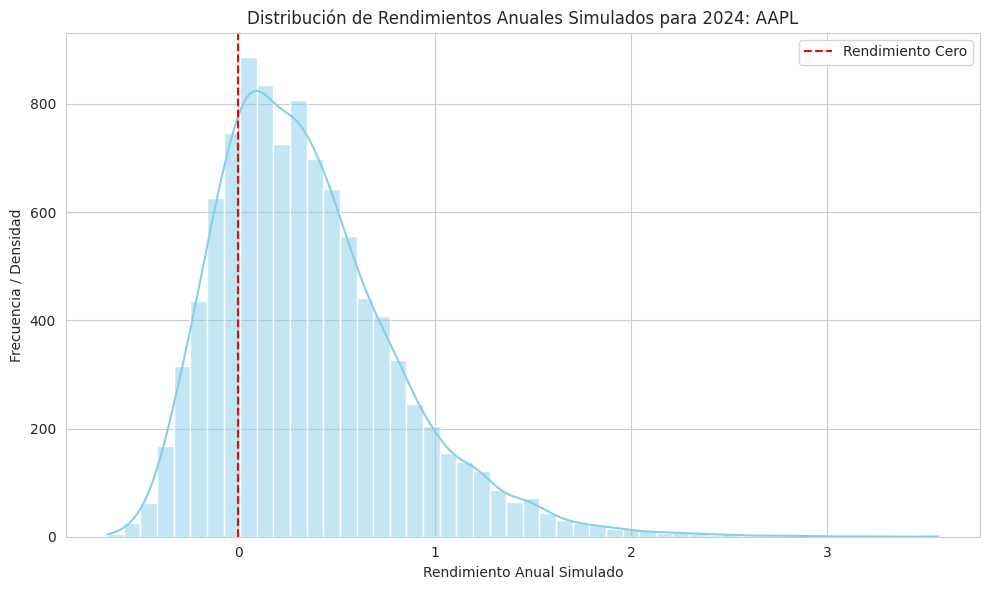

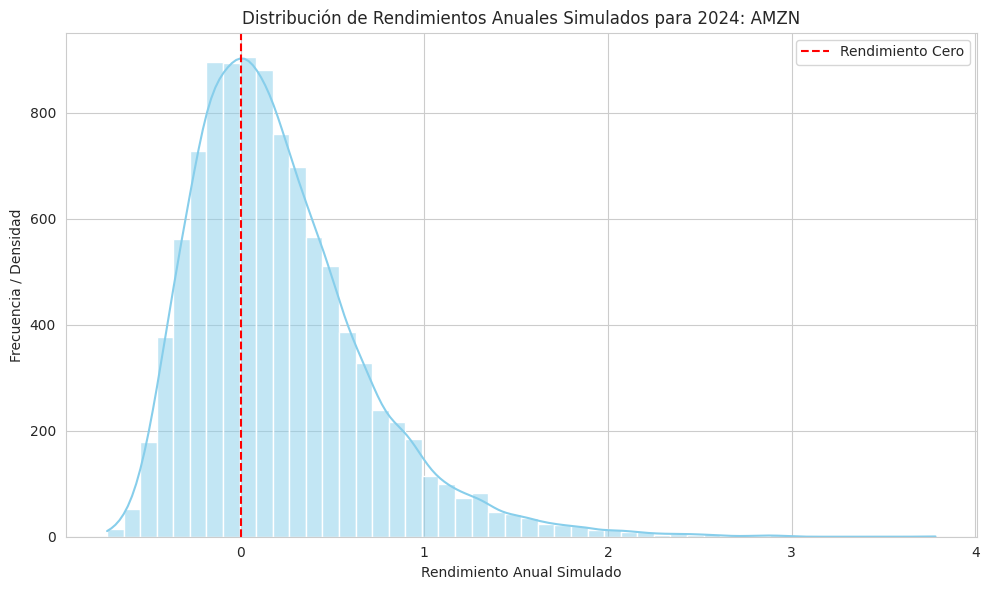

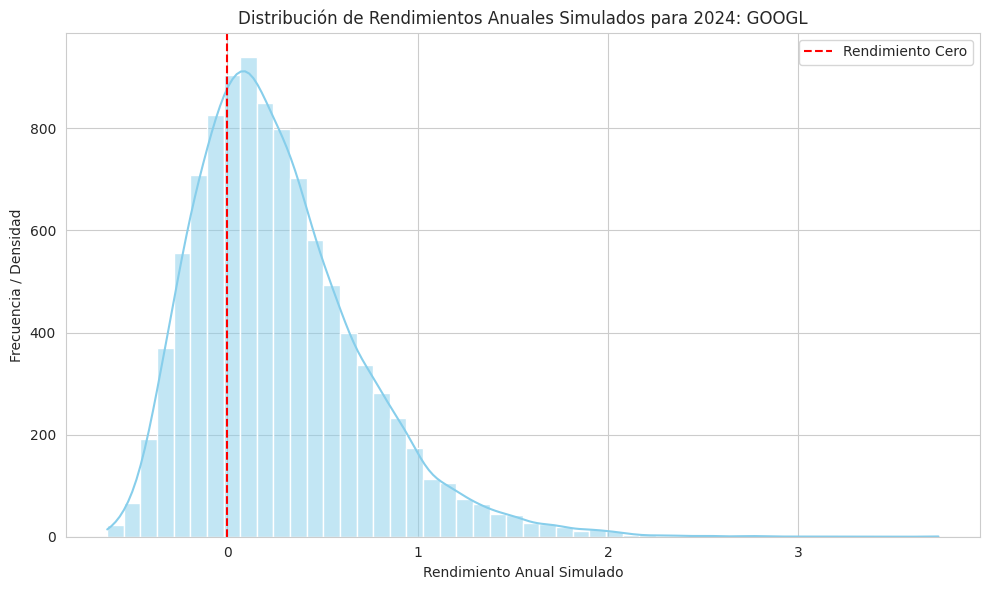

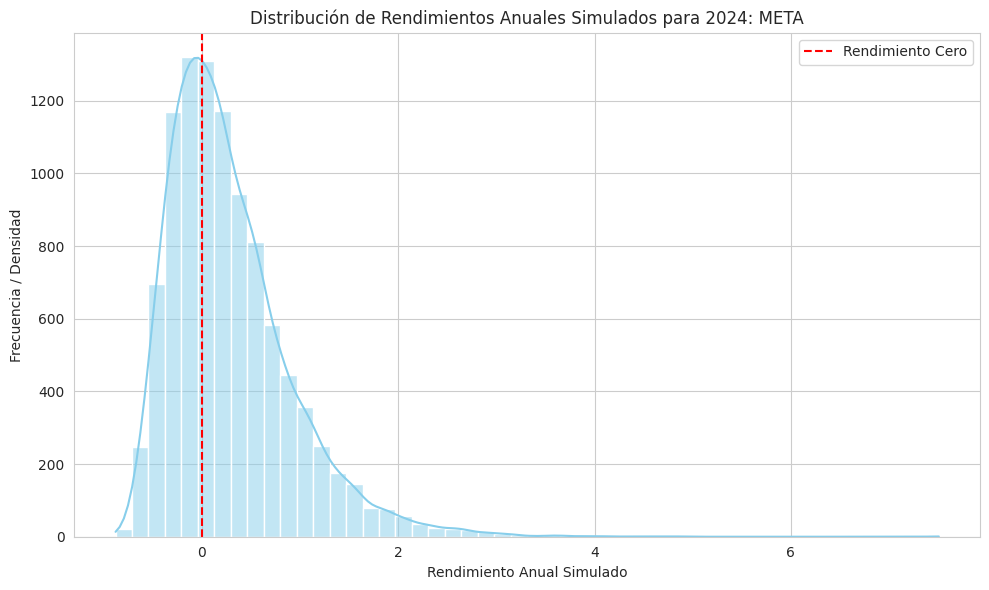

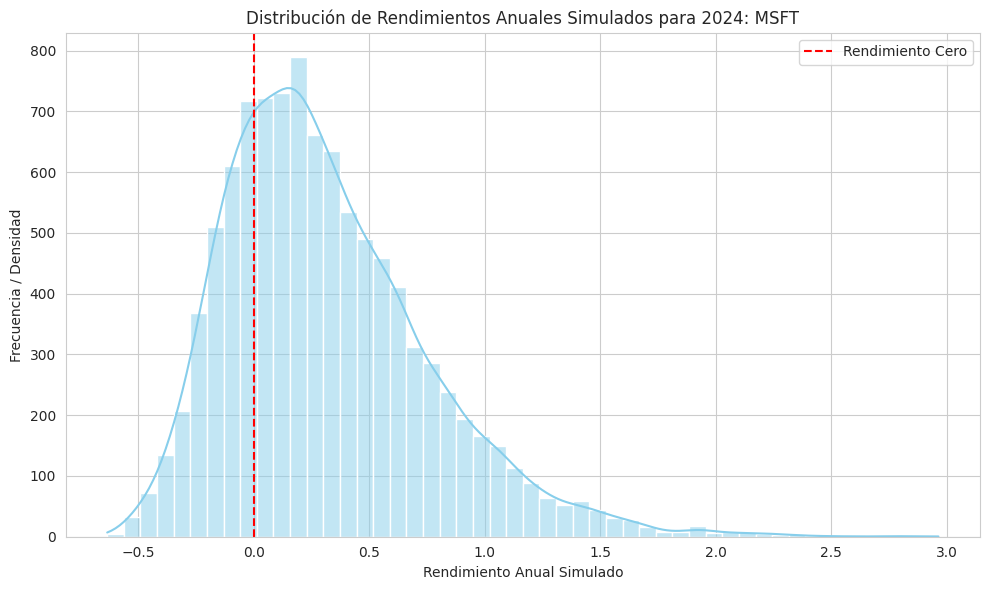

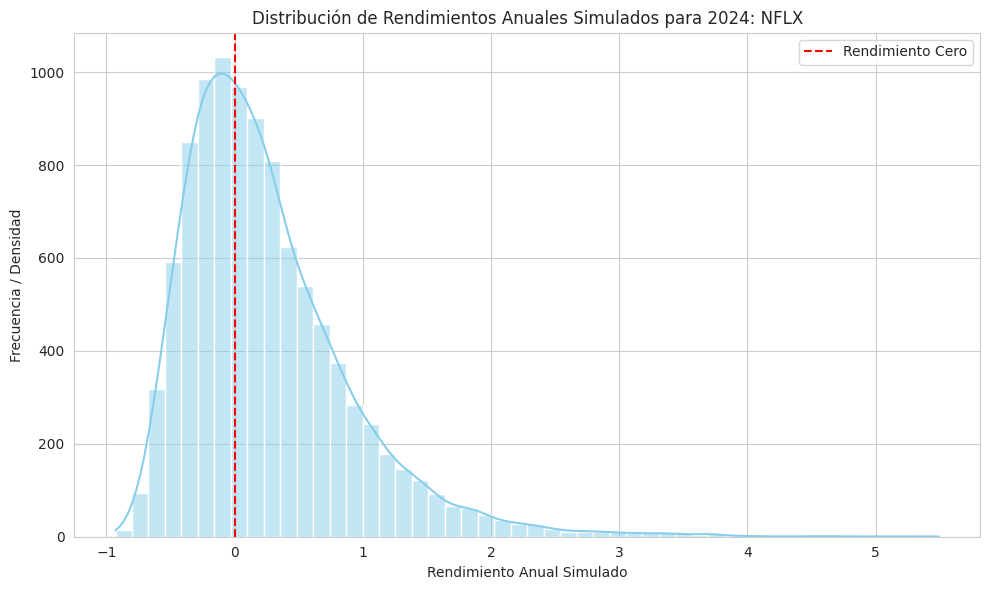

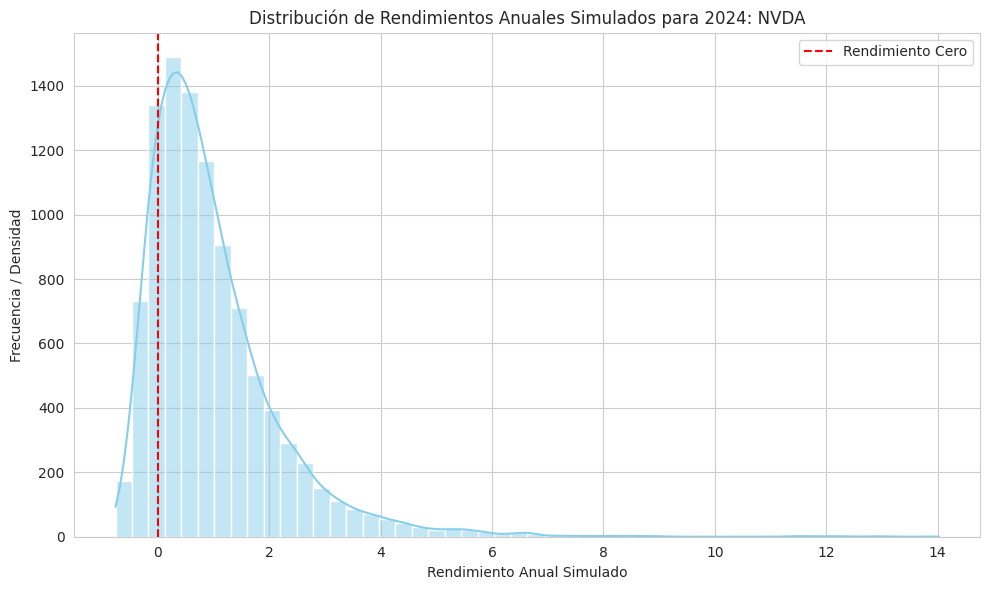

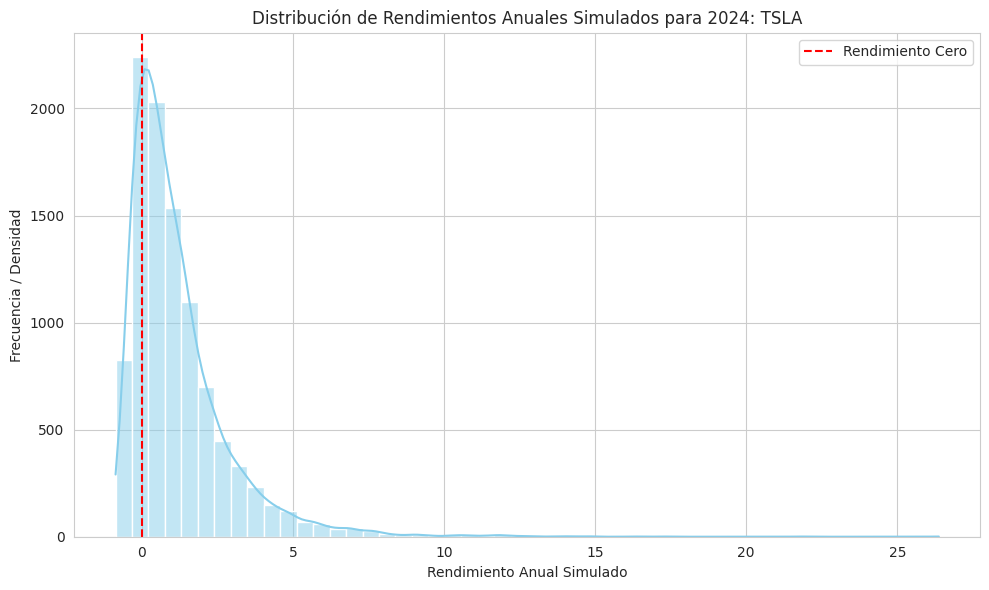

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

# --- Definir tickers, descargar datos y calcular rendimientos logarítmicos ---
# Se incluye este código para asegurar que 'log_returns' esté definido en esta celda
tech_tickers = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META', 'NVDA', 'TSLA', 'NFLX']
data = yf.download(tech_tickers, start='2020-01-01', end='2023-12-31', progress=False)
close_prices = data['Close']
log_returns = close_prices.apply(lambda x: pd.Series(np.log(x).diff())).dropna()

# --- Parámetros de la simulación ---
num_simulations = 10000  # Número de caminos simulados
num_trading_days_2024 = 252 # Aproximadamente 252 días de trading en un año

# Almacenar los resultados de las simulaciones de rendimientos anuales
simulated_annual_returns = pd.DataFrame(columns=log_returns.columns)

print(f"Realizando {num_simulations} simulaciones para {num_trading_days_2024} días de trading en 2024...")

for ticker in log_returns.columns:
    # Extraer los rendimientos históricos del activo
    historical_returns = log_returns[ticker].values

    # Generar rendimientos diarios aleatorios para cada simulación
    # Se muestrean con reemplazo de los rendimientos históricos
    daily_returns_simulated = np.random.choice(historical_returns,
                                                 size=(num_trading_days_2024, num_simulations),
                                                 replace=True)

    # Calcular el rendimiento logarítmico acumulado para cada simulación
    cumulative_log_returns_sim = np.sum(daily_returns_simulated, axis=0)

    # Convertir los rendimientos logarítmicos acumulados a rendimientos simples acumulados
    cumulative_simple_returns_sim = np.exp(cumulative_log_returns_sim) - 1

    # Guardar los rendimientos anuales simulados para este ticker
    simulated_annual_returns[ticker] = cumulative_simple_returns_sim

print("Simulación completada.")

# --- Calcular la probabilidad de crecimiento (rendimiento positivo) ---
probability_of_growth = (simulated_annual_returns > 0).mean()

print("\n--- Probabilidad de que los Rendimientos crezcan en 2024 (Simulación Monte Carlo) ---")
display(probability_of_growth.to_frame(name='Probabilidad de Crecimiento'))

# --- Visualización de las distribuciones de rendimientos anuales simulados ---
# Generar un histograma separado para cada ticker
for ticker in simulated_annual_returns.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(simulated_annual_returns[ticker], bins=50, kde=True, color='skyblue')
    plt.title(f'Distribución de Rendimientos Anuales Simulados para 2024: {ticker}')
    plt.xlabel('Rendimiento Anual Simulado')
    plt.ylabel('Frecuencia / Densidad')
    plt.axvline(0, color='red', linestyle='--', label='Rendimiento Cero')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Análisis Comparativo de Rendimientos: 2023 (Real) vs. 2024 (Simulado con Monte Carlo)

Ahora, realizaremos un análisis emparejado para comparar el rendimiento anual real de cada activo en 2023 con la distribución de rendimientos simulados para 2024, utilizando el modelo de Monte Carlo. Esto nos proporcionará una visión directa de cómo las proyecciones futuras se alinean o difieren del desempeño reciente.

--- Rendimientos Anuales Reales para 2023 ---


,Rendimiento Anual Real 2023
Ticker,
AAPL,54.80%
AMZN,77.04%
GOOGL,56.74%
META,183.76%
MSFT,58.35%
NFLX,65.07%
NVDA,246.10%
TSLA,129.86%



--- Comparación Visual: Rendimientos Reales 2023 vs. Simulados 2024 ---


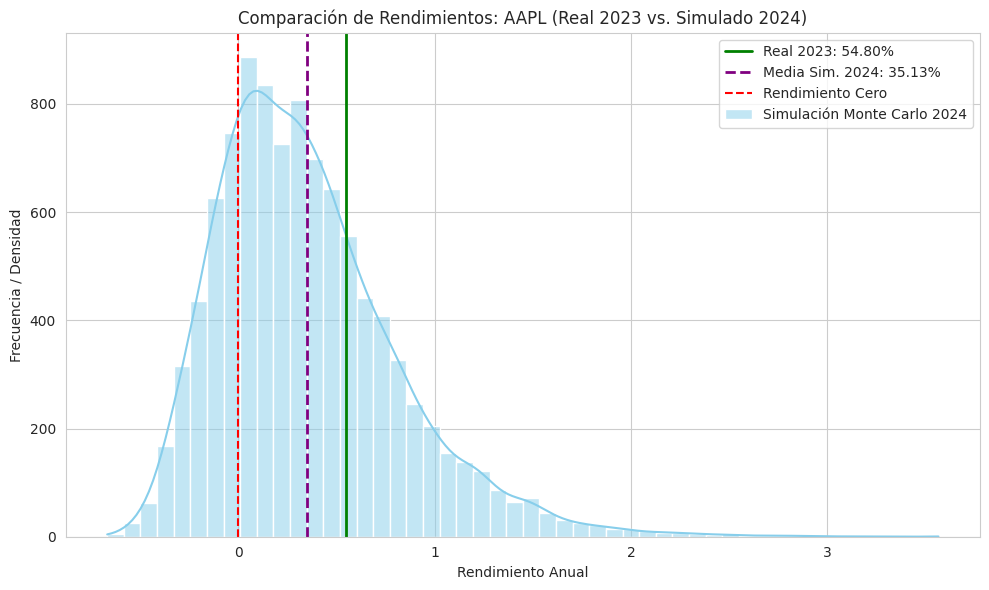

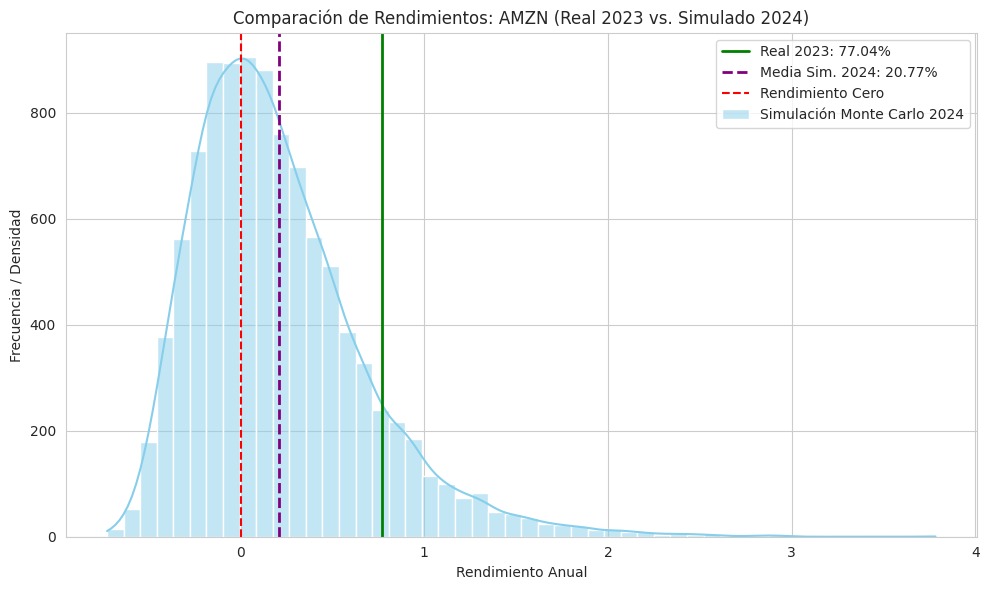

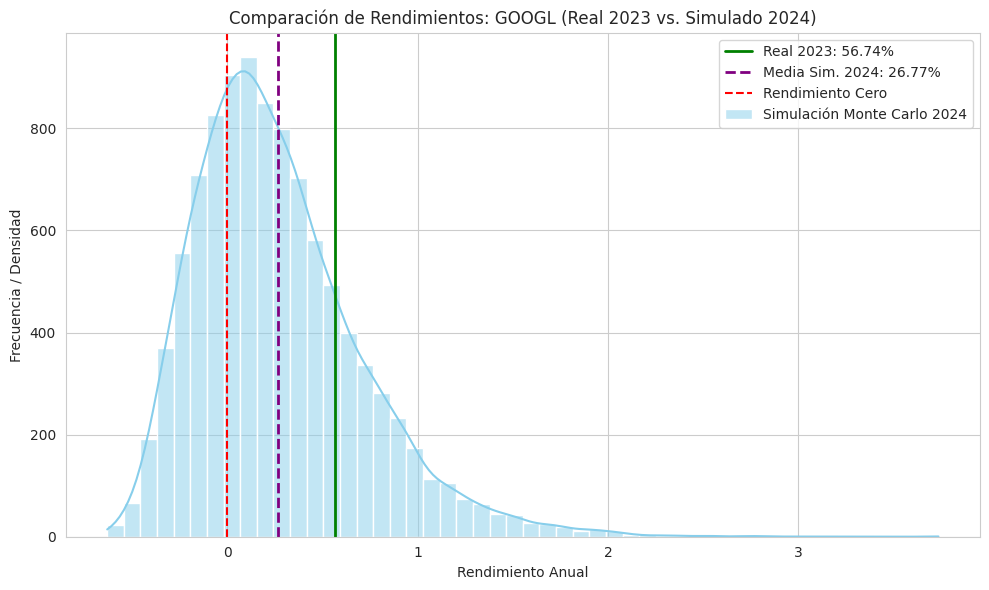

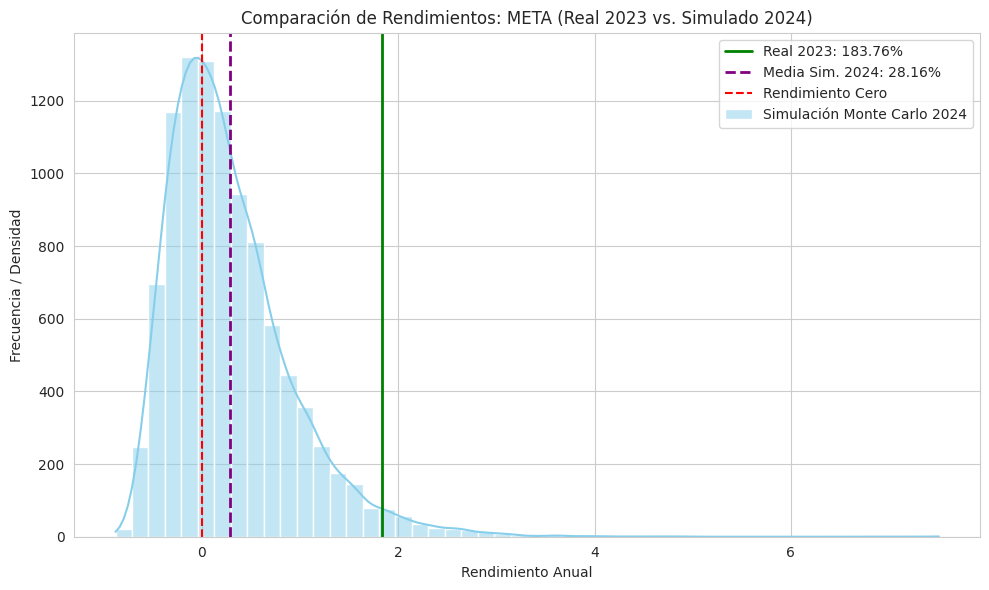

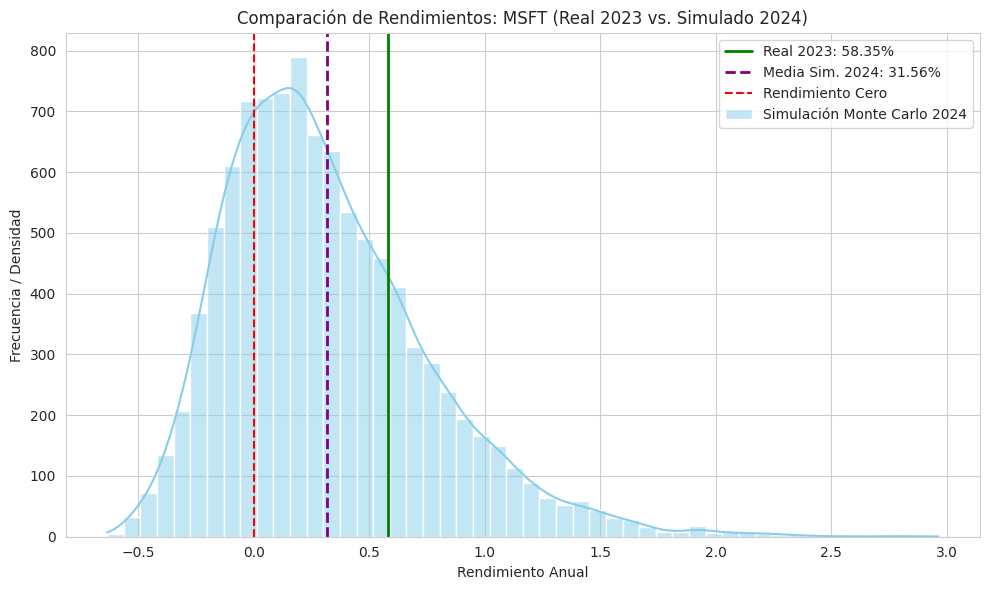

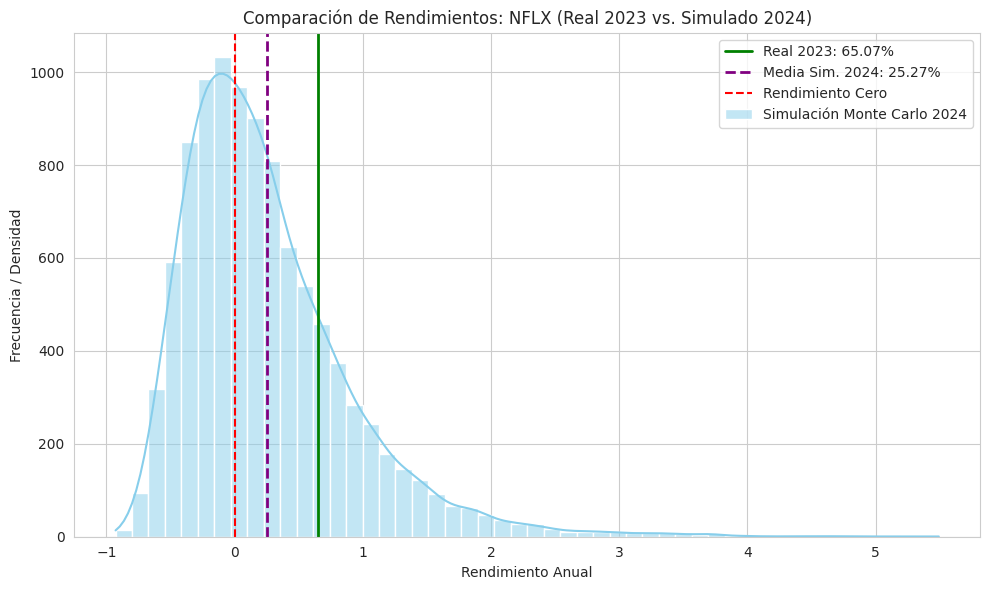

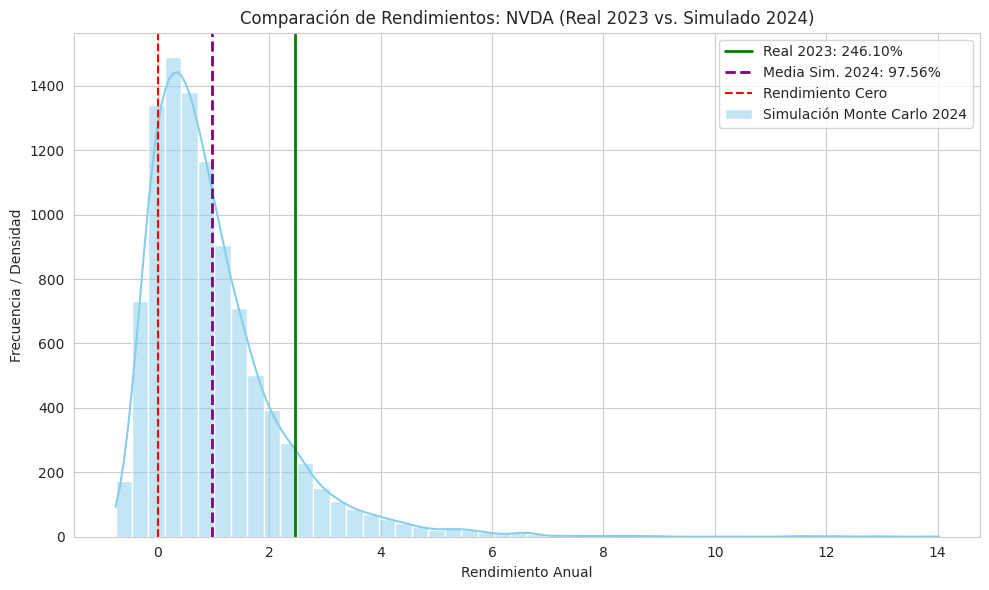

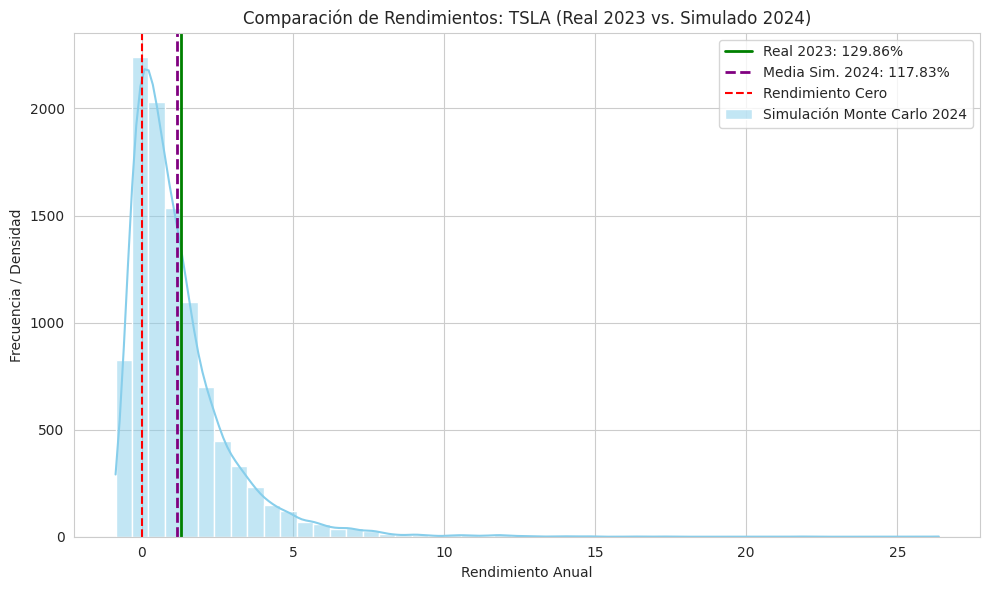


--- Resumen Comparativo de Rendimientos (2023 Real vs. 2024 Simulado) ---


,Rendimiento Real 2023,Media Simulada 2024,Diferencia (Sim. 2024 - Real 2023),Probabilidad de Crecimiento (Sim. 2024)
Ticker,,,,
AAPL,54.80%,35.13%,-19.67%,77.05%
AMZN,77.04%,20.77%,-56.27%,62.51%
GOOGL,56.74%,26.77%,-29.97%,70.53%
META,183.76%,28.16%,-155.60%,61.98%
MSFT,58.35%,31.56%,-26.79%,74.86%
NFLX,65.07%,25.27%,-39.80%,58.98%
NVDA,246.10%,97.56%,-148.54%,83.68%
TSLA,129.86%,117.83%,-12.03%,78.88%


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular Rendimientos Anuales Reales para 2023
# Filtrar close_prices para el año 2023
close_prices_2023 = close_prices.loc['2023']

# Obtener el primer y último precio de cierre para cada ticker en 2023
first_prices_2023 = close_prices_2023.iloc[0]
last_prices_2023 = close_prices_2023.iloc[-1]

# Calcular el rendimiento anual real para 2023
actual_annual_returns_2023 = (last_prices_2023 - first_prices_2023) / first_prices_2023

print("--- Rendimientos Anuales Reales para 2023 ---")
display(actual_annual_returns_2023.to_frame(name='Rendimiento Anual Real 2023').style.format('{:.2%}'))

# 2. Utilizar Rendimientos Anuales Simulados para 2024 (ya en simulated_annual_returns)

# 3. Visualizar la Comparación (2023 Real vs. 2024 Distribuciones Simuladas)
print("\n--- Comparación Visual: Rendimientos Reales 2023 vs. Simulados 2024 ---")
for ticker in simulated_annual_returns.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(simulated_annual_returns[ticker], bins=50, kde=True, color='skyblue', label='Simulación Monte Carlo 2024')

    # Trazar el rendimiento real de 2023
    actual_2023_return = actual_annual_returns_2023[ticker]
    plt.axvline(actual_2023_return, color='green', linestyle='-', linewidth=2, label=f'Real 2023: {actual_2023_return:.2%}')

    # Trazar la media de los rendimientos simulados de 2024
    mean_sim_2024_return = simulated_annual_returns[ticker].mean()
    plt.axvline(mean_sim_2024_return, color='purple', linestyle='--', linewidth=2, label=f'Media Sim. 2024: {mean_sim_2024_return:.2%}')

    plt.title(f'Comparación de Rendimientos: {ticker} (Real 2023 vs. Simulado 2024)')
    plt.xlabel('Rendimiento Anual')
    plt.ylabel('Frecuencia / Densidad')
    plt.axvline(0, color='red', linestyle='--', label='Rendimiento Cero')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 4. Cuantificar la Comparación (Tabla Resumen)
comparison_df = pd.DataFrame({
    'Rendimiento Real 2023': actual_annual_returns_2023,
    'Media Simulada 2024': simulated_annual_returns.mean(),
    'Diferencia (Sim. 2024 - Real 2023)': simulated_annual_returns.mean() - actual_annual_returns_2023
})
comparison_df['Probabilidad de Crecimiento (Sim. 2024)'] = (simulated_annual_returns > 0).mean()

print("\n--- Resumen Comparativo de Rendimientos (2023 Real vs. 2024 Simulado) ---")
display(comparison_df.style.format('{:.2%}'))

## 6. Agrupación de Activos por Correlación (Clustering)

Entender cómo los activos se agrupan en función de sus correlaciones es fundamental para estrategias de diversificación y gestión de carteras. Activos altamente correlacionados tienden a moverse en la misma dirección, mientras que los activos menos correlacionados ofrecen beneficios de diversificación. Utilizaremos el clustering jerárquico para identificar estos grupos.

### 6.1. Clustering Jerárquico

El clustering jerárquico construye una jerarquía de clusters (un árbol o dendrograma) sin requerir un número predefinido de grupos. Es especialmente útil para visualizar las relaciones y la distancia entre los activos.

**Metodología:**
1.  **Matriz de Distancia:** Convertimos la matriz de correlación en una matriz de distancia, ya que los algoritmos de clustering trabajan con medidas de disimilitud. Una métrica común es `1 - correlación`.
2.  **Algoritmo de Enlace (Linkage):** Calculamos los enlaces jerárquicos entre los puntos de datos (activos). El método 'ward' busca minimizar la varianza de los clusters que se están uniendo.
3.  **Dendrograma:** Visualizamos el dendrograma para observar la estructura jerárquica de los clusters y determinar un número adecuado de clusters si es necesario.
4.  **Formación de Clusters:** Cortamos el dendrograma a una altura específica o definimos un número de clusters para obtener las asignaciones finales de cada activo a un grupo.

/tmp/ipykernel_1107/3416217858.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tech_tickers, start='2020-01-01', end='2023-12-31', progress=False)


Matriz de Correlación de Rendimientos Logarítmicos:


Ticker,AAPL,AMZN,GOOGL,META,MSFT,NFLX,NVDA,TSLA
Ticker,,,,,,,,
AAPL,1.000000,0.626474,0.694518,0.600938,0.779637,0.465282,0.677045,0.519958
AMZN,0.626474,1.000000,0.666772,0.609647,0.680748,0.544022,0.616179,0.457061
GOOGL,0.694518,0.666772,1.000000,0.673781,0.773929,0.455939,0.658350,0.434345
META,0.600938,0.609647,0.673781,1.000000,0.622268,0.502925,0.563807,0.364770
MSFT,0.779637,0.680748,0.773929,0.622268,1.000000,0.477265,0.731390,0.481118
NFLX,0.465282,0.544022,0.455939,0.502925,0.477265,1.000000,0.480625,0.381850
NVDA,0.677045,0.616179,0.658350,0.563807,0.731390,0.480625,1.000000,0.532723
TSLA,0.519958,0.457061,0.434345,0.364770,0.481118,0.381850,0.532723,1.000000


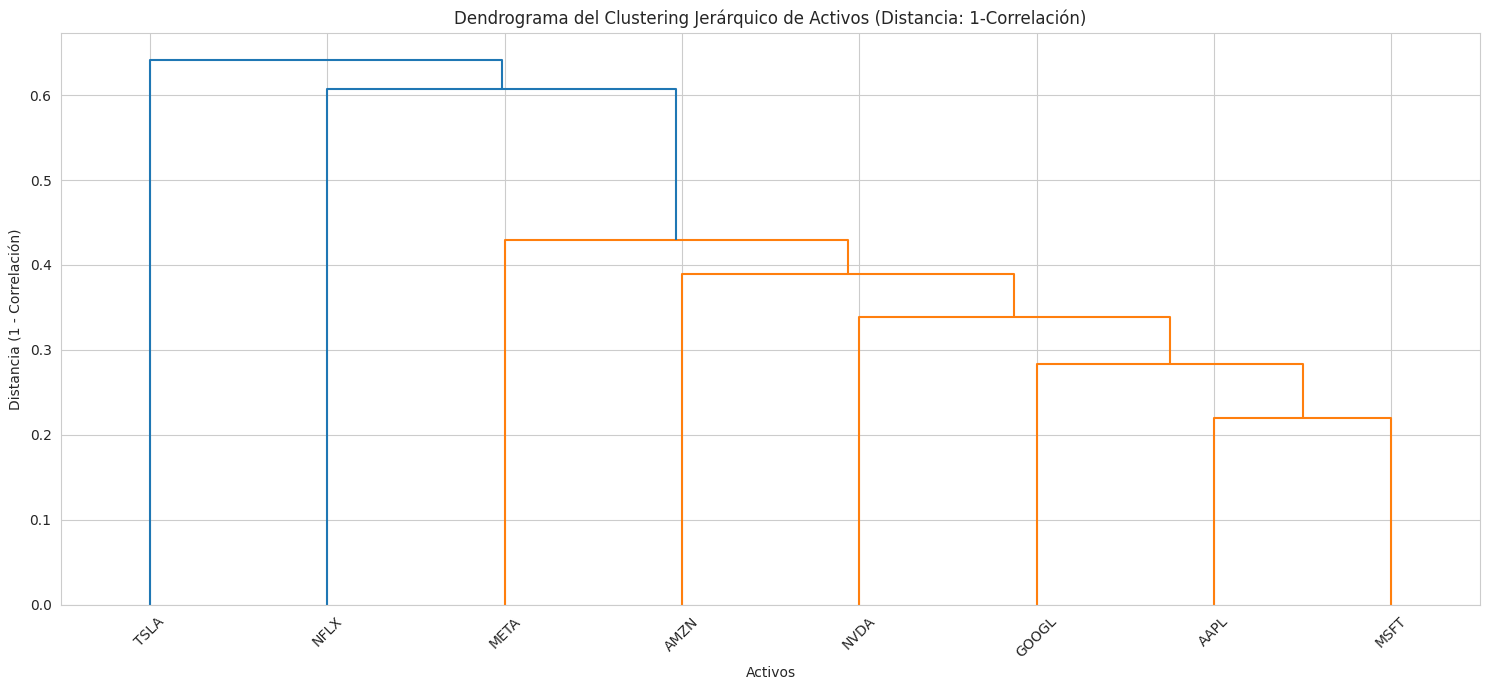


Clusters de activos para 3 grupos:


,Cluster
Asset,
AAPL,1
AMZN,1
GOOGL,1
META,1
MSFT,1
NVDA,1
NFLX,2
TSLA,3


In [27]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Asegurarse de que log_returns y correlation_matrix estén disponibles
# Este código se replica si la celda anterior fue borrada o el kernel reiniciado
import yfinance as yf
import numpy as np

# Definir los tickers de 8 activos tecnológicos
tech_tickers = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META', 'NVDA', 'TSLA', 'NFLX']

# Descargar datos históricos para los tickers
data = yf.download(tech_tickers, start='2020-01-01', end='2023-12-31', progress=False)

# Extraer solo los precios de cierre
close_prices = data['Close']

# Calcular los rendimientos logarítmicos
log_returns = close_prices.apply(lambda x: pd.Series(np.log(x).diff())).dropna()

# Calcular la matriz de correlación de los rendimientos logarítmicos
correlation_matrix = log_returns.corr()

print("Matriz de Correlación de Rendimientos Logarítmicos:")
display(correlation_matrix)

# 1. Convertir la matriz de correlación a una matriz de distancia
# Los algoritmos de clustering típicamente operan sobre distancias
distance_matrix = 1 - correlation_matrix

# Asegurarse de que la matriz de distancia sea simétrica y con diagonal cero
# Para scipy.cluster.hierarchy.linkage, necesitamos la forma condensada de la matriz de distancia
condensed_distance_matrix = squareform(distance_matrix)

# 2. Realizar el clustering jerárquico
# Usamos el método 'ward' para minimizar la varianza dentro de cada cluster
Z = linkage(condensed_distance_matrix, method='ward')

# 3. Visualizar el dendrograma
plt.figure(figsize=(15, 7))
plt.title('Dendrograma del Clustering Jerárquico de Activos (Distancia: 1-Correlación)')
plt.xlabel('Activos')
plt.ylabel('Distancia (1 - Correlación)')
dendrogram(
    Z,
    labels=correlation_matrix.index.tolist(), # Usar los nombres de los tickers como etiquetas
    leaf_rotation=45.,  # Rotar etiquetas para mejor legibilidad
    leaf_font_size=10., # Tamaño de fuente de las etiquetas
)
plt.tight_layout()
plt.show()

# 4. Formar clusters cortando el dendrograma
# Por ejemplo, para obtener 3 clusters (puedes ajustar este número según el dendrograma)
num_clusters = 3
clusters = fcluster(Z, num_clusters, criterion='maxclust')

# Asignar los clusters a los activos
asset_clusters = pd.DataFrame({'Asset': correlation_matrix.index, 'Cluster': clusters})
asset_clusters = asset_clusters.set_index('Asset')

print(f"\nClusters de activos para {num_clusters} grupos:")
display(asset_clusters.sort_values(by='Cluster'))

# Opcional: Para una mejor comprensión, podemos recalcular la correlación media dentro de cada cluster
# Esto es más complejo y quizás para un análisis posterior, pero se menciona como idea.

## 7. Análisis de la Dependencia Temporal de los Rendimientos (ACF y PACF)

Para entender si los rendimientos de los activos tienen alguna estructura de dependencia temporal (es decir, si los rendimientos de hoy están relacionados con los de ayer), utilizaremos la Función de Autocorrelación (ACF) y la Función de Autocorrelación Parcial (PACF). Estas herramientas son fundamentales en el análisis de series de tiempo para identificar componentes autorregresivos (AR) o de promedio móvil (MA), y para evaluar la estacionalidad y el 'ruido blanco' en los datos.

Calculando y graficando ACF y PACF para los rendimientos logarítmicos...


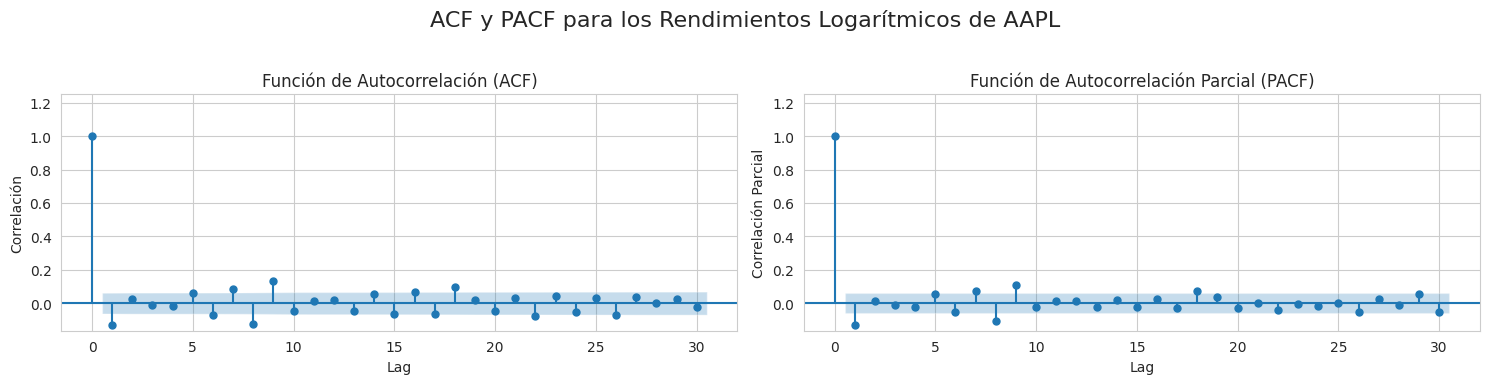

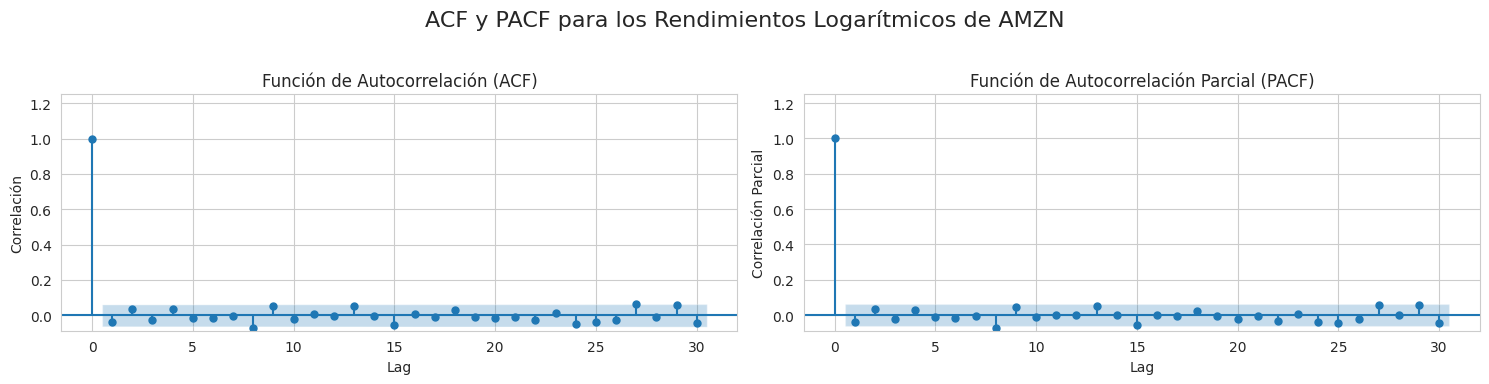

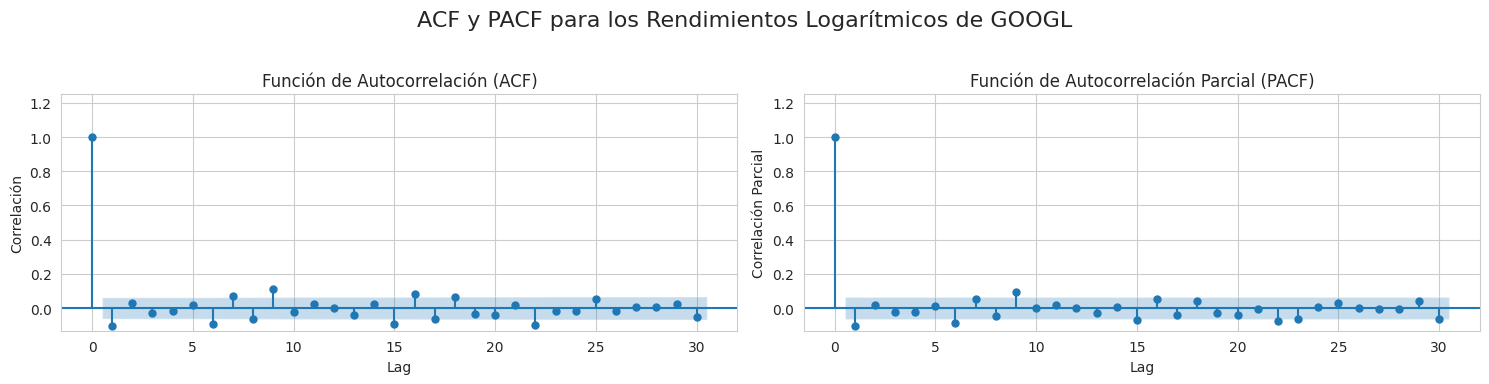

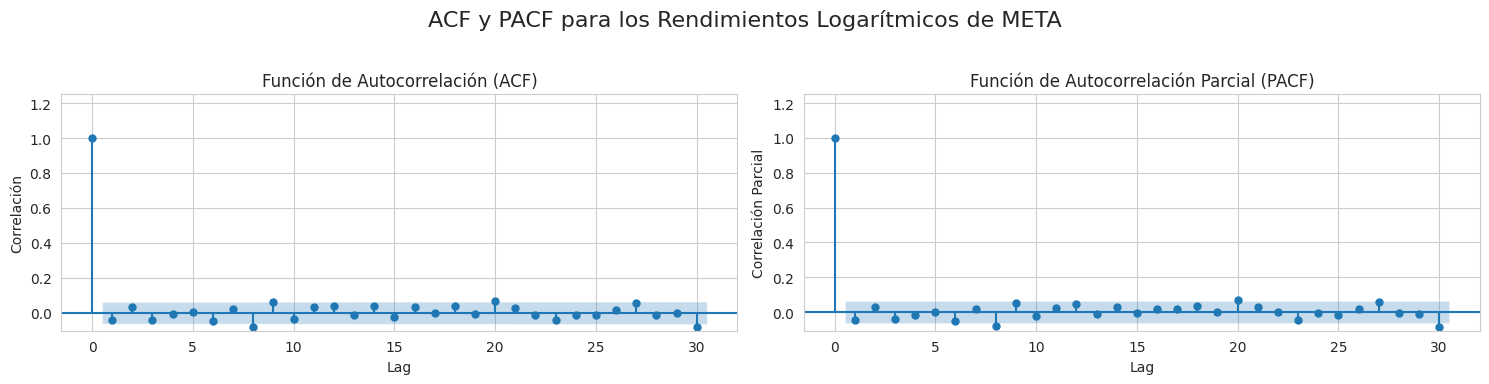

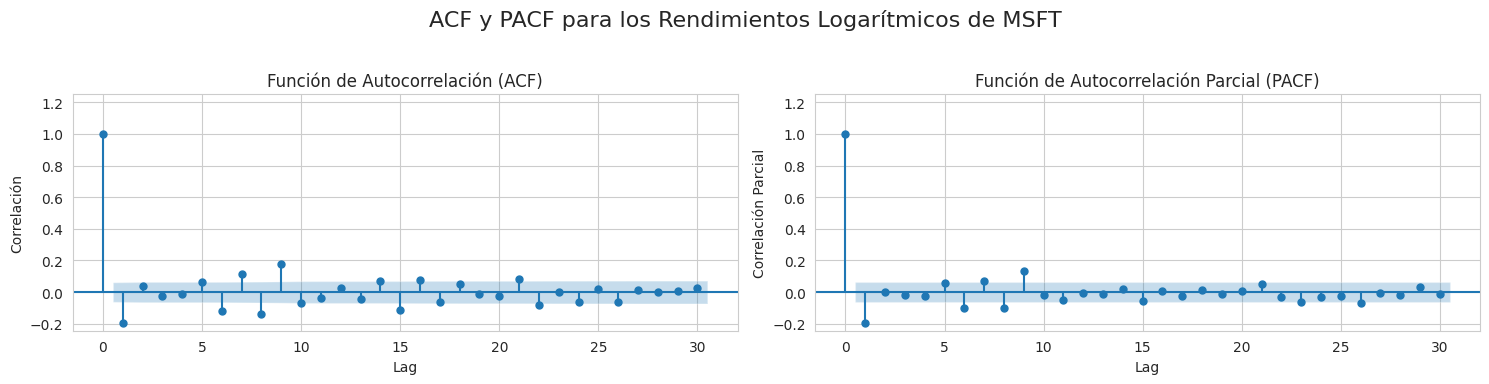

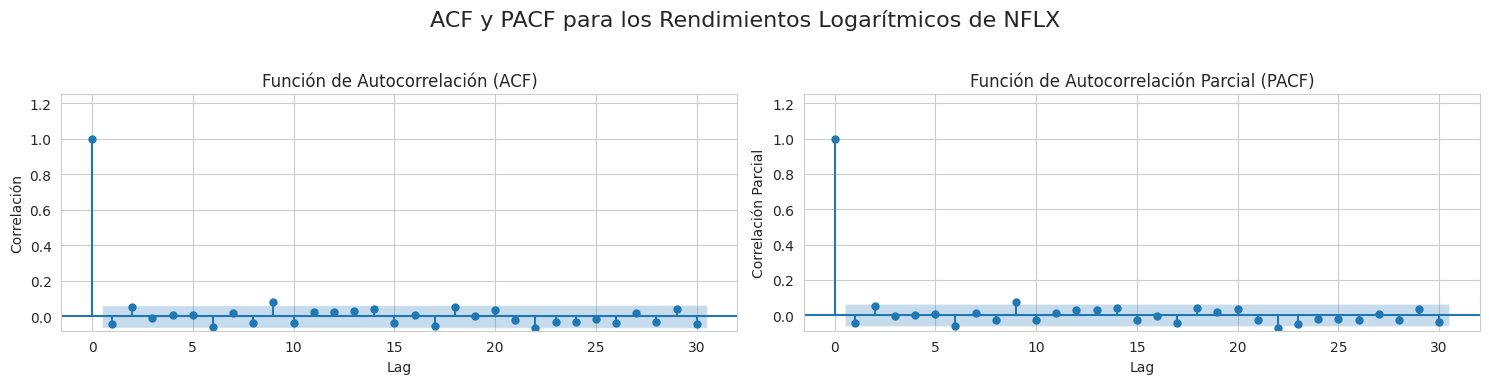

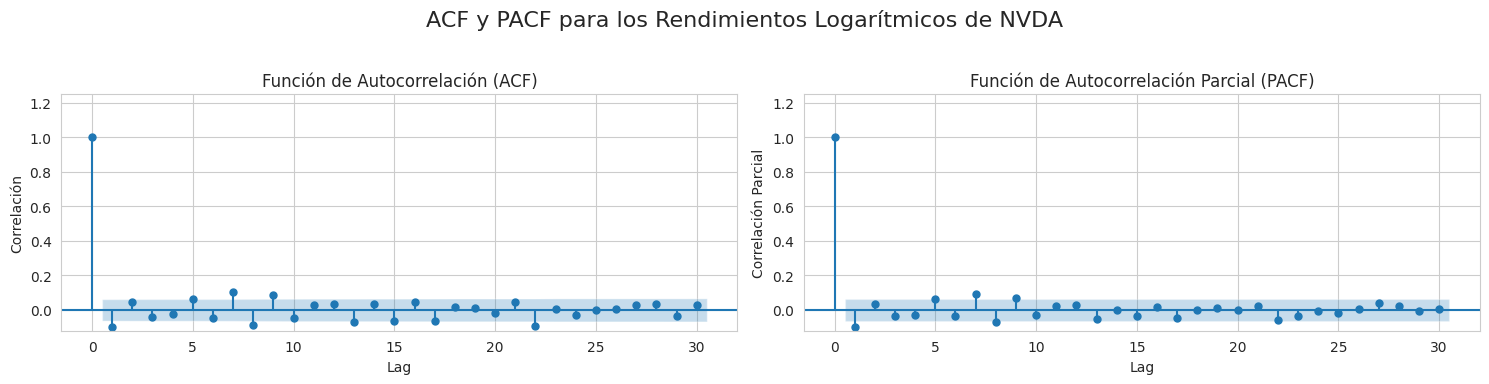

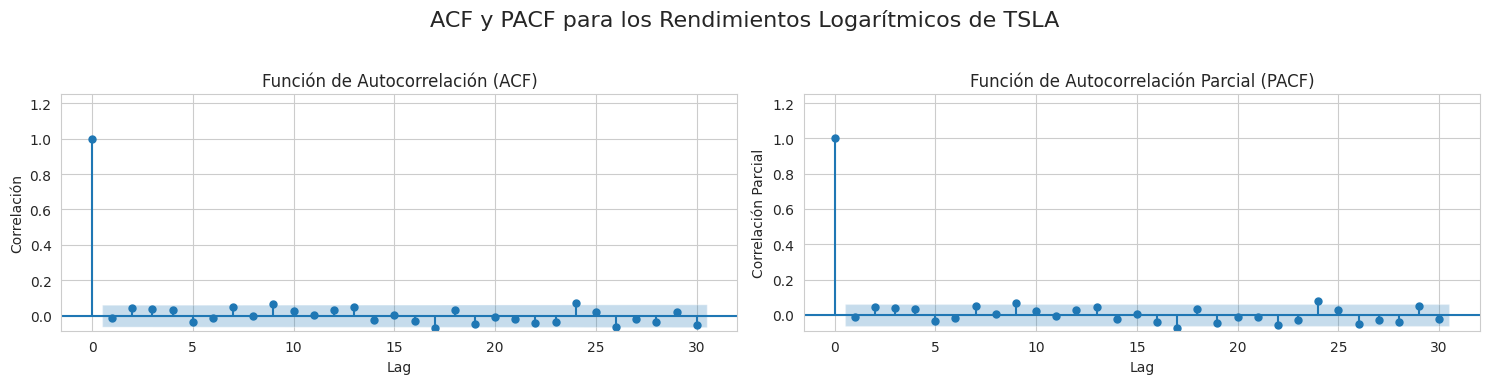

Análisis de ACF y PACF completado.


In [28]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns

sns.set_style('whitegrid')

print("Calculando y graficando ACF y PACF para los rendimientos logarítmicos...")

for ticker in log_returns.columns:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    fig.suptitle(f'ACF y PACF para los Rendimientos Logarítmicos de {ticker}', fontsize=16)

    # Plot ACF
    plot_acf(log_returns[ticker], lags=30, ax=axes[0], auto_ylims=True, title='Función de Autocorrelación (ACF)')
    axes[0].set_xlabel('Lag')
    axes[0].set_ylabel('Correlación')

    # Plot PACF
    plot_pacf(log_returns[ticker], lags=30, ax=axes[1], auto_ylims=True, title='Función de Autocorrelación Parcial (PACF)')
    axes[1].set_xlabel('Lag')
    axes[1].set_ylabel('Correlación Parcial')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar layout para título
    plt.show()

print("Análisis de ACF y PACF completado.")

### 7.2. Interpretación de los Gráficos ACF y PACF para Rendimientos Logarítmicos

Los gráficos de la Función de Autocorrelación (ACF) y la Función de Autocorrelación Parcial (PACF) son herramientas cruciales en el análisis de series de tiempo para entender la dependencia temporal de los datos. En el contexto de los rendimientos logarítmicos de activos financieros, estos gráficos nos permiten evaluar si los rendimientos pasados tienen alguna capacidad de predecir los rendimientos futuros.

#### Función de Autocorrelación (ACF)

*   **Concepto**: La ACF mide la correlación lineal entre un rendimiento en un momento dado y sus rendimientos anteriores (rezagados). Por ejemplo, el 'Lag 1' en el gráfico ACF nos dice si el rendimiento de hoy está correlacionado con el rendimiento de ayer, el 'Lag 2' si está correlacionado con el rendimiento de anteayer, y así sucesivamente.
*   **Interpretación de las Bandas Azules**: En los gráficos, las áreas sombreadas en azul representan las bandas de confianza. Si las barras de correlación caen dentro de estas bandas, se considera que la autocorrelación en ese rezago no es estadísticamente significativa, es decir, es tan pequeña que podría deberse al azar. Si una barra excede estas bandas, indica una correlación significativa.
*   **Para Rendimientos Financieros**: Para los rendimientos logarítmicos de activos, es una característica común (y un indicador de mercados eficientes) que la mayoría de las correlaciones en el gráfico ACF no sean significativas. Esto sugiere que los rendimientos son cercanos a un "ruido blanco", lo que significa que no hay una dependencia lineal predecible entre los rendimientos pasados y futuros.

#### Función de Autocorrelación Parcial (PACF)

*   **Concepto**: La PACF mide la correlación directa entre un rendimiento en un momento dado y sus rendimientos rezagados, *eliminando la influencia de los rezagos intermedios*. Por ejemplo, la PACF en el 'Lag 2' mide la correlación entre el rendimiento de hoy y el de hace dos días, pero solo la parte de esa correlación que no puede explicarse por el rendimiento de ayer.
*   **Interpretación de las Bandas Azules**: Al igual que en la ACF, las barras que se extienden más allá de las bandas de confianza azul indican una correlación parcial estadísticamente significativa.
*   **Para Rendimientos Financieros**: Similar a la ACF, para los rendimientos logarítmicos, se espera que la mayoría de los rezagos en el gráfico PACF no sean significativos. Esto refuerza la idea de que los rendimientos individuales son impredecibles a partir de sus propios valores pasados.

#### Hallazgos y Conclusión para los Activos Analizados

Al observar los gráficos ACF y PACF generados para cada uno de los activos tecnológicos (AAPL, MSFT, AMZN, GOOGL, META, NVDA, TSLA, NFLX), podemos notar consistentemente que:

*   **Ausencia de Correlación Significativa**: La gran mayoría de las barras de autocorrelación (tanto en ACF como en PACF) se encuentran dentro de las bandas de confianza azules, especialmente después del Lag 0 (que siempre es 1 ya que un valor está perfectamente correlacionado consigo mismo).
*   **Característica de Ruido Blanco**: Esta ausencia de correlación significativa en los rendimientos a lo largo del tiempo es la característica distintiva de un proceso de **ruido blanco**. En finanzas, un proceso de ruido blanco implica que los rendimientos pasados de un activo no proporcionan información linealmente útil para predecir sus rendimientos futuros.
*   **Implicación de Mercados Eficientes**: Este resultado es consistente con la teoría de mercados eficientes (aunque en una forma débil), donde toda la información públicamente disponible se refleja rápidamente en los precios, haciendo que los movimientos de precios sean impredecibles y aleatorios.

En resumen, los gráficos ACF y PACF confirman que los rendimientos logarítmicos de estos activos tecnológicos se comportan en gran medida como un proceso de ruido blanco, lo que significa que no hay una dependencia lineal fuerte entre los rendimientos de hoy y los de días pasados.

### 7.1. Principios Fundamentales e Interpretación de ACF y PACF

#### Función de Autocorrelación (ACF)

*   **Principio**: La ACF mide la correlación entre una serie de tiempo y sus versiones rezagadas (lagged versions) de sí misma. Por ejemplo, en el lag 1, mide la correlación entre el rendimiento de hoy y el rendimiento de ayer. En el lag k, mide la correlación entre el rendimiento de hoy y el rendimiento de hace k períodos.
*   **Interpretación**: En los gráficos de ACF:
    *   **Bandas de Confianza**: Las áreas sombreadas en azul representan las bandas de confianza. Si una barra de correlación cae dentro de estas bandas, la autocorrelación en ese lag no es estadísticamente significativa (es decir, es cercana a cero). Si la barra excede las bandas, la autocorrelación es significativa.
    *   **Series de Tiempo Financieras (Rendimientos)**: Para los rendimientos logarítmicos diarios de activos financieros, se espera típicamente que la mayoría de los lags en el gráfico ACF no sean significativos, lo que sugiere que los rendimientos son aproximadamente 'ruido blanco' (no predecibles a partir de sus propios valores pasados). Pequeñas autocorrelaciones significativas en los primeros lags podrían indicar una ligera ineficiencia o la presencia de componentes de promedio móvil (MA).
    *   **Decaimiento Lento**: Si la ACF decae lentamente, esto es un indicador de no estacionariedad (ej. precios, no rendimientos) o de una fuerte dependencia a largo plazo.

#### Función de Autocorrelación Parcial (PACF)

*   **Principio**: La PACF mide la correlación entre una serie de tiempo y sus versiones rezagadas, pero **eliminando la influencia de los rezagos intermedios**. Por ejemplo, la PACF en el lag 3 mide la correlación entre el rendimiento de hoy y el rendimiento de hace 3 días, *después de haber eliminado la correlación que ya existía a través de los rendimientos de hace 1 y 2 días*.
*   **Interpretación**: En los gráficos de PACF:
    *   **Bandas de Confianza**: Al igual que en la ACF, las barras que exceden las bandas de confianza son estadísticamente significativas.
    *   **Series de Tiempo Financieras (Rendimientos)**: Para rendimientos, al igual que la ACF, se espera que la mayoría de los lags no sean significativos, reforzando la idea de ruido blanco. Significativas autocorrelaciones parciales en los primeros lags (especialmente el lag 1) podrían indicar la presencia de componentes autorregresivos (AR) en el modelo.
    *   **Corte Abrupto**: Un corte abrupto en la PACF (es decir, unas pocas barras significativas seguidas de un rápido decaimiento a la insignificancia) es una señal de que el proceso subyacente podría ser un modelo autorregresivo (AR).

#### Implicaciones para los Rendimientos de Activos Tecnológicos

Observando los gráficos generados para cada activo, generalmente se confirma la hipótesis de que los rendimientos logarítmicos de los activos financieros se asemejan a un **proceso de ruido blanco**, es decir, son impredecibles a partir de sus valores pasados directos. Esto se manifiesta como:

*   **ACF**: La mayoría de las barras caen dentro de las bandas de confianza o son muy pequeñas después del lag 0.
*   **PACF**: Similarmente, la PACF muestra muy poca o ninguna correlación significativa en la mayoría de los lags.

Esto es una característica deseable en mercados eficientes, donde toda la información relevante se incorpora rápidamente en los precios, haciendo que los rendimientos futuros sean difíciles de predecir basándose únicamente en el historial de precios. Cualquier correlación significativa detectada, por pequeña que sea, podría ser un punto de partida para construir modelos de pronóstico más sofisticados, como los modelos ARMA (AutoRegressive Moving Average) o ARIMA (AutoRegressive Integrated Moving Average), que intentan capturar estas dependencias temporales.

### 6.2. Análisis del Clustering Jerárquico

El **dendrograma** es la representación visual clave del clustering jerárquico. En el eje X, tenemos los activos, y en el eje Y, la distancia (en este caso, `1 - correlación`). La altura de cada unión en el dendrograma representa la distancia a la que dos clusters o activos se fusionaron. Cuanto menor sea la altura, más similares son los elementos.

**Interpretación del Dendrograma:**
*   **Grupos Cercanos:** Los activos que se unen a alturas bajas en el dendrograma son los más correlacionados positivamente. Estos forman grupos naturales de activos que tienden a moverse juntos.
*   **Distancia para Diversificación:** Para una buena diversificación, un inversor buscaría activos que estén 'lejos' en el dendrograma o que pertenezcan a diferentes clusters, ya que sus rendimientos no están altamente correlacionados.
*   **Número de Clusters:** Podemos 'cortar' el dendrograma a una altura específica para definir un número de clusters. Por ejemplo, si se corta a una altura que interseque N líneas verticales, se obtienen N clusters. En el ejemplo del código, se definió arbitrariamente `num_clusters = 3` para demostrar la asignación.

**Resultados de la Agrupación (Ejemplo de 3 Clusters):**
La tabla de `Clusters de activos` muestra a qué grupo se asigna cada activo. Podemos observar:
*   Activos dentro del mismo cluster tienen una correlación relativamente alta entre sí.
*   Activos en diferentes clusters tienen una correlación más baja, lo que indica un comportamiento de mercado más independiente. Esto es crucial para la diversificación. Por ejemplo, si tenemos un cluster con varios activos altamente correlacionados, añadir más de esos activos a la cartera no aumentará significativamente la diversificación. En cambio, añadir un activo de un cluster diferente podría mejorar la diversificación.

Este análisis proporciona una base visual y cuantitativa para la construcción de carteras, permitiendo a los gestores de fondos identificar activos con patrones de comportamiento de mercado similares y diferentes, optimizando así el equilibrio entre riesgo y rendimiento mediante una diversificación más inteligente.